## Hi-ChIP analysis plots

In [1]:
import os,sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import patches
from matplotlib.patches import FancyArrowPatch


In [2]:
text_size = 8
scaling_factor = 3
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 4*scaling_factor, 'axes.linewidth': 0.3*scaling_factor,
                     'xtick.major.size': 1.5*scaling_factor, 'xtick.major.width': 0.3*scaling_factor, 'ytick.major.size': 1.5*scaling_factor, 'ytick.major.width': 0.3*scaling_factor})
# grid letters
grid_letter_positions = [-0.1, 0.05]
grid_letter_fontsize = 8
grid_letter_fontfamily = 'sans-serif'
grid_letter_fontweight = 'bold'
point_size = 1

In [3]:
import matplotlib
def remove_x_axis(ax):
    ax.xaxis.set_major_locator(matplotlib.ticker.NullLocator())
    ax.set_xlabel('')
    
def remove_y_axis(ax):
    ax.yaxis.set_major_locator(matplotlib.ticker.NullLocator())
    ax.set_ylabel('')

### Read results

In [ ]:
outdir = '/pool2/tmp/yuliyi/ATACformer/data/hichip/result_GSE234521/'
figdir = '/pool2/tmp/yuliyi/ATACformer/data/hichip/plot_GSE234521/'

In [ ]:
genes_oi_coords = {
    'CD69':'chr12:9905082-9913497',
    'CD3D':'chr11:118334537-118342705',
    "IL7R":"chr5:35852695-35879603",
    "IRF4":"chr6:391739-411443"
}

In [6]:
import pyranges as pr

def _pyranges_from_strings(pos_list):
    """
    Function to create pyranges for a `pd.Series` of strings
    (borrowed from SEAcells https://github.com/dpeerlab/SEACells)
    """
    # Chromosome and positions
    chr = pos_list.str.split(':').str.get(0)
    start = pd.Series(pos_list.str.split(':').str.get(1)
                      ).str.split('-').str.get(0)
    end = pd.Series(pos_list.str.split(':').str.get(1)
                    ).str.split('-').str.get(1)

    # Create ranges
    gr = pr.PyRanges(chromosomes=chr, starts=start, ends=end)
    return gr

In [7]:
def plot_distal_links(ax):
    # ---------- Parameters ----------
    track_y = -0.6
    track_h = 0.24
    track_x0, track_x1 = 0.0, 10.0

    prom_x, prom_w, prom_h = 0.0, 2.2, 0.70   # Left black rectangle (promoter)
    enh_x, enh_size = 8.9, 0.60               # Right gray square (enhancer)

    # ---------- Black gene track (thick horizontal bar) ----------
    track = patches.Rectangle((track_x0, track_y - track_h/2),
                            track_x1 - track_x0, track_h,
                            facecolor="black", edgecolor="none", zorder=3)
    ax.add_patch(track)

    # ---------- Left thickened rectangle (promoter) ----------
    promoter = patches.Rectangle((prom_x, track_y - prom_h/2),
                            prom_w, prom_h,
                            facecolor="black", edgecolor="none", zorder=4)
    ax.add_patch(promoter)

    # ---------- Top-left "elbow vertical line" ----------
    elbow_x = prom_x + 0.05
    vert_y0 = track_y + prom_h/2 - 0.02
    y_top = track_y + prom_h/2 + 0.40
    ax.plot([elbow_x, elbow_x],
            [vert_y0, y_top],
            color="black", linewidth=1.0, zorder=6)

    # ---------- Top horizontal large arrow (enlarged) ----------
    # Control arrow size (mutation_scale) and line width via FancyArrowPatch
    top_arrow = FancyArrowPatch((elbow_x - 0.1, y_top), (elbow_x - 0.1 + 2, y_top),
                            arrowstyle='->',
                            mutation_scale=8,    # Controls arrowhead size (larger value = bigger head)
                            linewidth=1.0,
                            color='black',
                            zorder=7)
    ax.add_patch(top_arrow)

    # ---------- Small directional arrows along the track (also enlarged) ----------
    track_arrow = FancyArrowPatch((prom_x + 1.3, track_y), (prom_x + 2.5, track_y),
                            arrowstyle='->',
                            mutation_scale=6,
                            linewidth=1.0,
                            color='black',
                            zorder=5)
    ax.add_patch(track_arrow)

    # ---------- Right gray square (centered on the track) ----------
    enhancer = patches.Rectangle((enh_x, track_y - enh_size/2),
                            enh_size, enh_size,
                            facecolor="0.6", edgecolor="none", zorder=4)
    ax.add_patch(enhancer)

    # ---------- Red distal link (quadratic Bezier, placed below the black bar) ----------
    x0 = prom_x + 0.35                 # Start point near the right edge of the left rectangle
    x1 = enh_x + enh_size * 0.5        # End point at the middle-bottom of the gray square
    y0 = track_y - track_h/2
    y1 = track_y - track_h/2
    xc, yc = (x0 + x1) / 2, -2.0      # Control point: adjust yc to change the arc depth

    t = np.linspace(0, 1, 300)
    x = (1-t)**2 * x0 + 2*(1-t)*t * xc + t**2 * x1
    y = (1-t)**2 * y0 + 2*(1-t)*t * yc + t**2 * y1
    ax.plot(x, y, linewidth=1.0, color="red", zorder=2)

    # ---------- Title text ----------
    ax.text(2, 0.95, "Distal links", fontsize=12, style="italic")

    # ---------- Layout & Appearance ----------
    ax.set_xlim(-0.6, 10.6)
    ax.set_ylim(-2.0, 1.6)
    ax.axis("off")

In [ ]:
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec

def min_max_scale(x):
    return((x - min(x)) / (max(x) - min(x)))

def plot_virtual4C_gene_locus_for_first(epiGen_df, highlight_regions, ymax=100, method='epiGen'):
    '''
    Visualization of locus and enhancer
    '''
    plt.rcParams['font.size'] = 12
    plt.rcParams['figure.figsize'] = 10,4.5
    fig = plt.figure()
    gs = GridSpec(5, 3, height_ratios=(1, 1, 1, 10, 7), width_ratios=(2, 6, 2))

    ax1 = fig.add_subplot(gs[0:3, 0])
    ax2 = fig.add_subplot(gs[2, 1])
    ax3 = fig.add_subplot(gs[0:3, 2])
    ax4 = fig.add_subplot(gs[3, :])
    ax5 = fig.add_subplot(gs[4, :])

    axs = [ax1, ax2, ax3, ax4, ax5]
    
    gene_name = epiGen_df['gene_name'].tolist()[0]
    coords = f"{epiGen_df['chromosome'].tolist()[0]}:{epiGen_df['position'].min()}-{epiGen_df['position'].max()}"
    
    plot_distal_links(axs[0])

    # plot gene coords
    gene_gr = _pyranges_from_strings(pd.Series(epiGen_df['gene_coords'][0])).as_df()
    axs[1].plot([gene_gr['Start'][0], gene_gr['End'][0]],[1,1], color='black', linewidth=10) ## vertical
    axs[1].set_xlim(epiGen_df.position.min(),epiGen_df.position.max())
    axs[1].text(gene_gr['Start'][0]-50000, 1, gene_name, fontsize=12, ha='right', va='center', color='black')
#     print(gene_gr['Start'][0])
    
    remove_x_axis(axs[1])
    remove_y_axis(axs[1])
    axs[1].spines['top'].set_visible(False)
    axs[1].spines['bottom'].set_visible(False)
    axs[1].spines['left'].set_visible(False)
    axs[1].spines['right'].set_visible(False)

    axs[2].axis("off")
    
    # Plot HiChip signal
    signal_gene_df = epiGen_df[epiGen_df.method == 'HiChIP'].reset_index()
    signal_df = signal_gene_df[signal_gene_df['cell type'] == 'negative']
    axs[3].step(signal_df.position, signal_df.signal, label='HCAMSC (Neg. HiChIP)', color='#1f78b4')
    signal_df = signal_gene_df[signal_gene_df['cell type'] == 'positive']
    axs[3].step(signal_df.position, signal_df.signal, label='Naive T (Pos. HiChIP)', color='#33a02c')
    axs[3].yaxis.set_major_locator(MaxNLocator(nbins=4))
    axs[3].set_xlim(epiGen_df.position.min(),epiGen_df.position.max())

    # plot viewpoint coordinates
    axs[3].set_ylabel("EIS")
    axs[3].set_ylim(0,ymax)
    axs[3].legend(loc='upper left',frameon=False)
    remove_x_axis(axs[3])
    
    # Plot epiGen prediction
    signal_gene_df = epiGen_df[epiGen_df.method == method].reset_index()
    signal_gene_df['signal'] = min_max_scale(signal_gene_df.signal)
    axs[4].step(signal_gene_df.position, signal_gene_df.signal, color='#990000', label='Naive T')
    axs[4].set_ylabel(f"{method} $\Delta$\n(min-max scaled)")
    axs[4].yaxis.set_major_locator(MaxNLocator(nbins=2))
    axs[4].xaxis.set_major_locator(MaxNLocator(nbins=4))
    axs[4].ticklabel_format(style='plain')
    axs[4].set_xlim(epiGen_df.position.min(),epiGen_df.position.max())
    # axs[4].legend(loc='upper left',frameon=False)
    plt.ylim(0,1.01)
    plt.xlabel(f'Genomic coordinate ({coords})')
    plt.subplots_adjust(wspace=0.2, hspace=0.03)  # Reduce the width and height spacing

    for start, end in highlight_regions:
        axs[3].axvspan(start, end, color='gray', alpha=0.4)
        axs[4].axvspan(start, end, color='gray', alpha=0.4)


def plot_virtual4C_gene_locus(dgd_df, highlight_regions, ymax=100, method='epiGen'):
    '''
    Visualization of locus and enhancer
    '''
    plt.rcParams['font.size'] = 12
    plt.rcParams['figure.figsize'] = 10,4.5
    fig,axs = plt.subplots(nrows=3, ncols=1, height_ratios=(1,10, 7))
    
    gene_name = dgd_df['gene_name'].tolist()[0]
    coords = f"{dgd_df['chromosome'].tolist()[0]}:{dgd_df['position'].min()}-{dgd_df['position'].max()}"
        
    # plot gene coords
    gene_gr = _pyranges_from_strings(pd.Series(dgd_df['gene_coords'][0])).as_df()
    axs[0].plot([gene_gr['Start'][0], gene_gr['End'][0]],[1,1], color='black', linewidth=10); ## vertical
    axs[0].set_xlim(dgd_df.position.min(),dgd_df.position.max())
    axs[0].text(gene_gr['Start'][0]-50000, 1, gene_name, fontsize=12, ha='right', va='center', color='black')
#     print(gene_gr['Start'][0])
    
    remove_x_axis(axs[0])
    remove_y_axis(axs[0])
    axs[0].spines['top'].set_visible(False)
    axs[0].spines['bottom'].set_visible(False)
    axs[0].spines['left'].set_visible(False)
    axs[0].spines['right'].set_visible(False)
    
    # Plot HiChip signal
    signal_gene_df = dgd_df[dgd_df.method == 'HiChIP'].reset_index()
    signal_df = signal_gene_df[signal_gene_df['cell type'] == 'negative']
    axs[1].step(signal_df.position, signal_df.signal, label='HCAMSC (Neg. HiChIP)', color='#1f78b4')
    signal_df = signal_gene_df[signal_gene_df['cell type'] == 'positive']
    axs[1].step(signal_df.position, signal_df.signal, label='Naive T (Pos. HiChIP)', color='#33a02c')
    axs[1].yaxis.set_major_locator(MaxNLocator(nbins=4))
    axs[1].set_xlim(dgd_df.position.min(),dgd_df.position.max())

    # plot viewpoint coordinates
    axs[1].set_ylabel("EIS")
    axs[1].set_ylim(0,ymax)
    axs[1].legend(loc='upper left',frameon=False)
    remove_x_axis(axs[1])
    
    # Plot DGD prediction
    signal_gene_df = dgd_df[dgd_df.method == method].reset_index()
    signal_gene_df['signal'] = min_max_scale(signal_gene_df.signal)
    axs[2].step(signal_gene_df.position, signal_gene_df.signal, color='#990000', label='Naive T')
    axs[2].set_ylabel(f"{method} $\Delta$\n(min-max scaled)")
    axs[2].yaxis.set_major_locator(MaxNLocator(nbins=2))
    axs[2].xaxis.set_major_locator(MaxNLocator(nbins=4))
    axs[2].ticklabel_format(style='plain')
    axs[2].set_xlim(dgd_df.position.min(),dgd_df.position.max())
    plt.ylim(0,1.01)
    plt.xlabel(f'Genomic coordinate ({coords})')
    plt.subplots_adjust(wspace=0.2, hspace=0.03)  # Reduce the width and height spacing

    for start, end in highlight_regions:
        axs[1].axvspan(start, end, color='gray', alpha=0.4)
        axs[2].axvspan(start, end, color='gray', alpha=0.4)
    

### Plot EIS

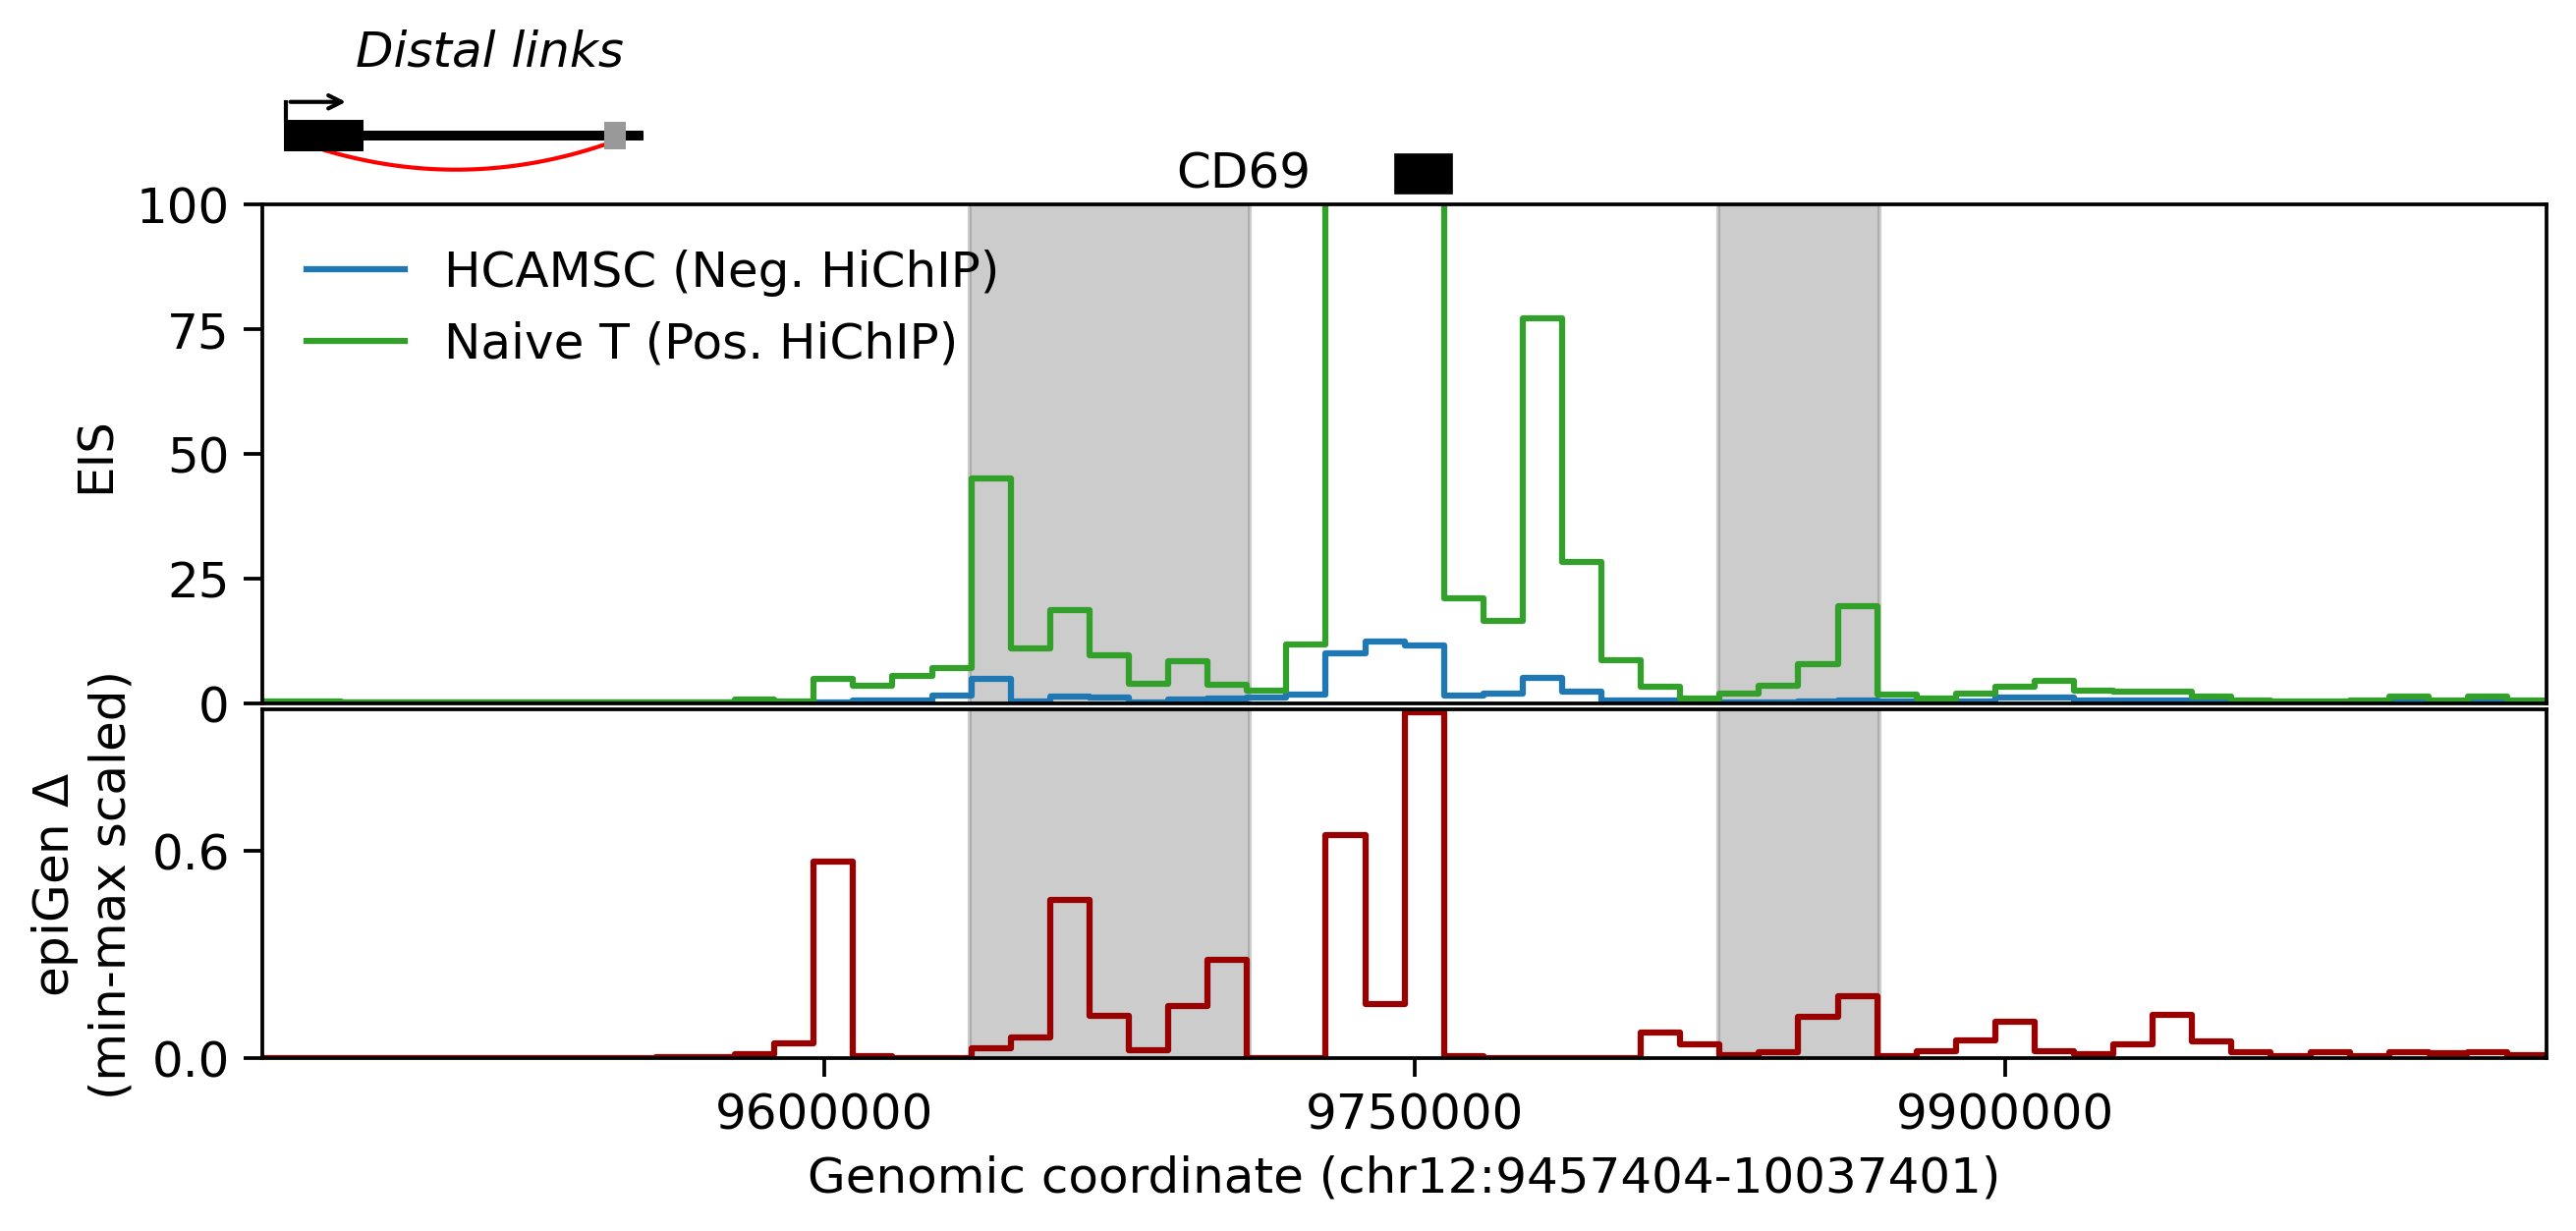

In [9]:
gene = 'CD69'
eis_df = pd.read_csv(f'/pool2/tmp/yuliyi/ATACformer/data/hichip/preprocess/EIS_signal_{gene}_promoter.hg38.csv')
corr_df = pd.read_csv(outdir + f'{gene}_hg38_baseline_correlation.csv')
dgd_df = pd.read_csv(outdir + f'{gene}_hg38_hichip_epiGen_aligned_locations.csv')
dgd_df['position'] = (dgd_df.position * 10e5).astype(int)
dgd_df['gene_name'] = gene
dgd_df['gene_coords'] = eis_df['gene_coords'][0]
dgd_df['chromosome'] = eis_df['chromosome'][0]
dgd_df['viewpoint'] = eis_df['viewpoint'][0]

highlight_regions = [
    (9637000, 9708000),
    (9827000, 9868000)
]
plot_virtual4C_gene_locus_for_first(dgd_df.reset_index(), highlight_regions, ymax=100)
plt.savefig(figdir + f'{gene}_tracks.pdf')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


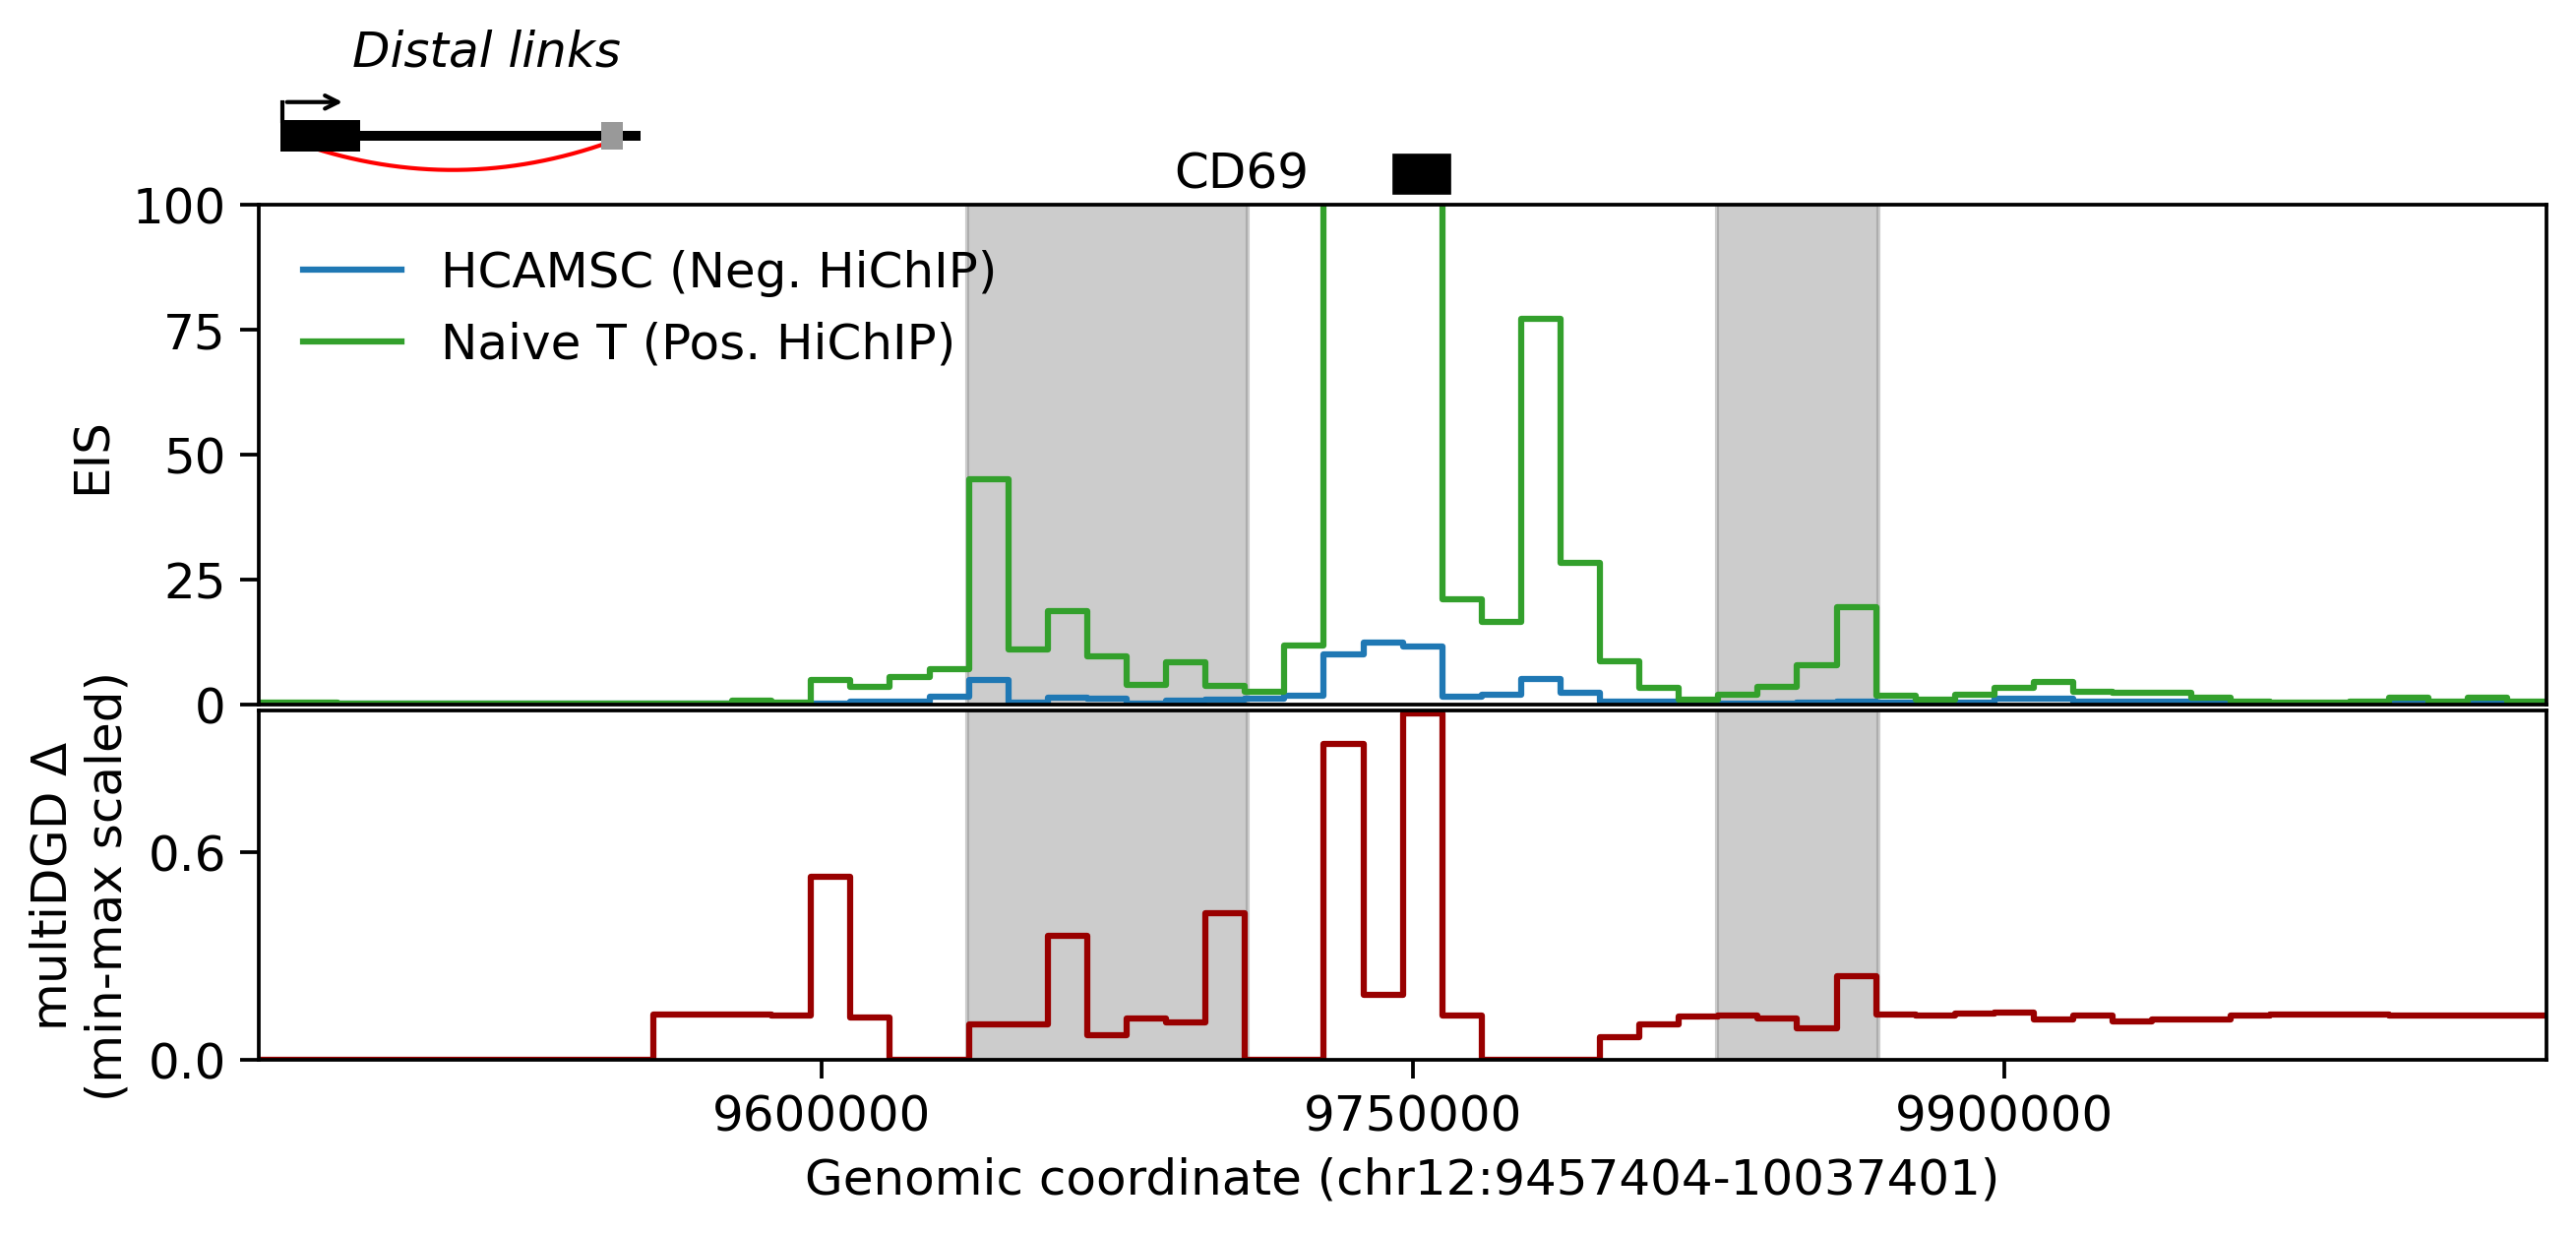

In [ ]:
gene = 'CD69'
eis_df = pd.read_csv(f'/pool2/tmp/yuliyi/ATACformer/data/hichip/preprocess/EIS_signal_{gene}_promoter.hg38.csv')
corr_df = pd.read_csv(outdir + f'{gene}_hg38_baseline_correlation.csv')
dgd_df = pd.read_csv(outdir + f'{gene}_hg38_hichip_multiDGD_aligned_locations.csv')
dgd_df['position'] = (dgd_df.position * 10e5).astype(int)
dgd_df['gene_name'] = gene
dgd_df['gene_coords'] = eis_df['gene_coords'][0]
dgd_df['chromosome'] = eis_df['chromosome'][0]
dgd_df['viewpoint'] = eis_df['viewpoint'][0]
# 添加灰色阴影区域（关键）
highlight_regions = [
    (9637000, 9708000),
    (9827000, 9868000)
]
plot_virtual4C_gene_locus_for_first(dgd_df.reset_index(), highlight_regions, ymax=100, method='multiDGD')
plt.savefig(figdir + f'{gene}_tracks_multiDGD.pdf')

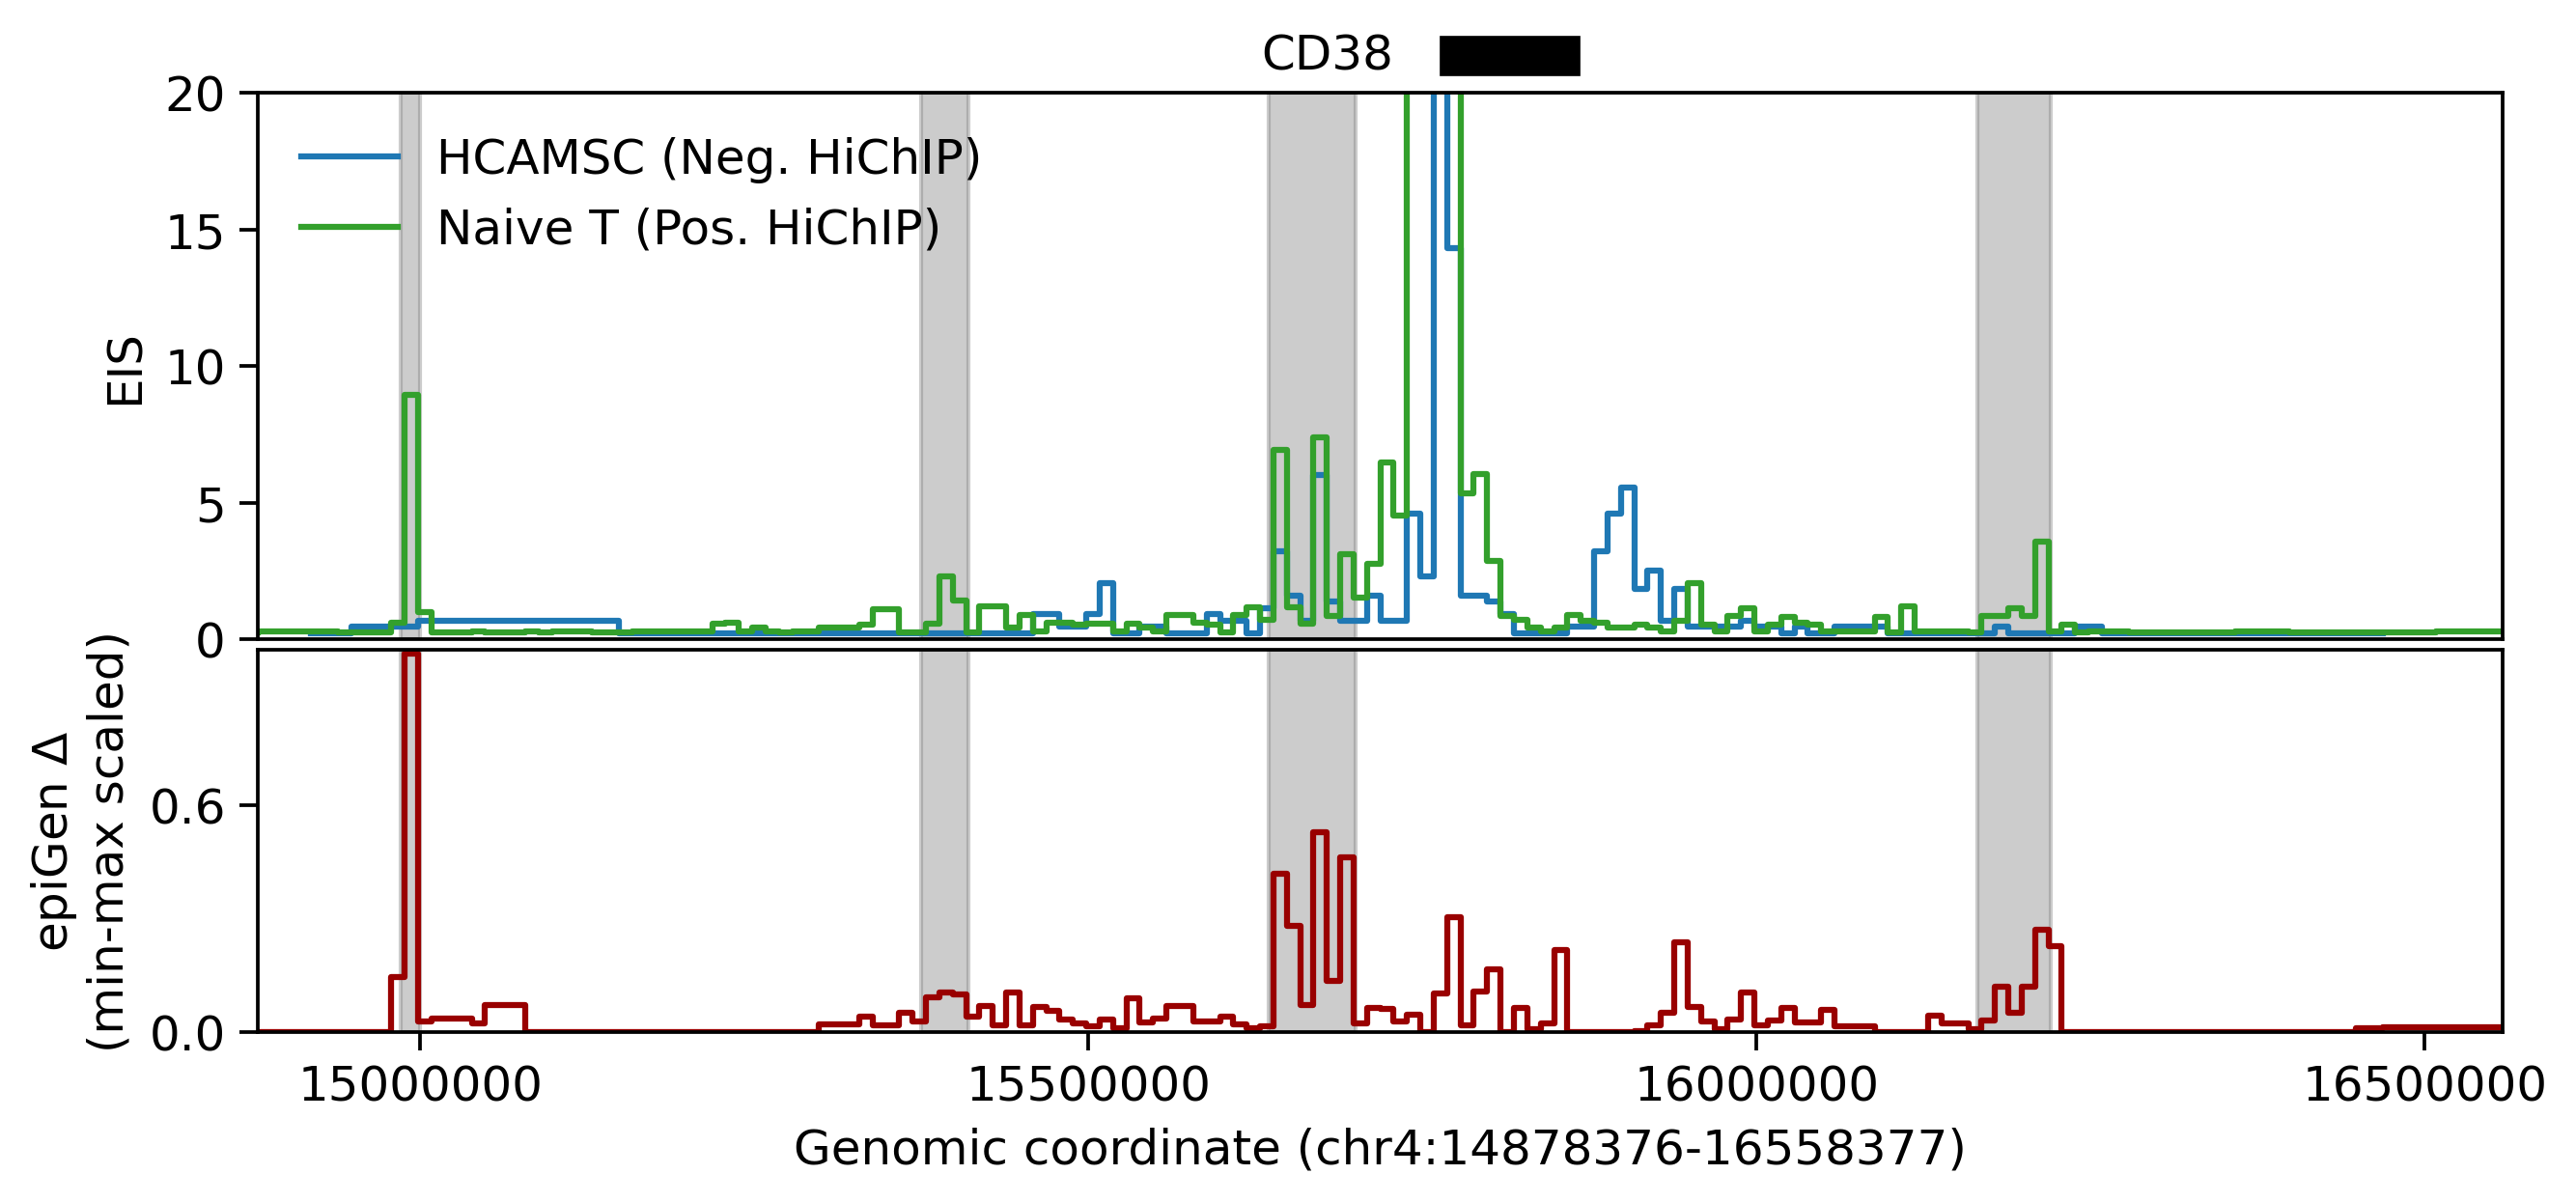

In [ ]:
gene = 'CD38'
outdir = '/pool2/tmp/yuliyi/ATACformer/data/hichip/result_GSE234521_finetune/'
eis_df = pd.read_csv(f'/pool2/tmp/yuliyi/ATACformer/data/hichip/preprocess/EIS_signal_{gene}_promoter.hg38.csv')
corr_df = pd.read_csv(f'/pool2/tmp/yuliyi/ATACformer/data/hichip/result_GSE234521/{gene}_hg38_baseline_correlation.csv')
dgd_df = pd.read_csv(outdir + f'{gene}_hg38_hichip_epiGen_aligned_locations_t.csv')
dgd_df['position'] = (dgd_df.position * 10e5).astype(int)
dgd_df['gene_name'] = gene
dgd_df['gene_coords'] = eis_df['gene_coords'][0]
dgd_df['chromosome'] = eis_df['chromosome'][0]
dgd_df['viewpoint'] = eis_df['viewpoint'][0]

highlight_regions = [
    (14985000, 15000000),
    (15375000, 15410000),
    (15635000, 15700000),
    (16165000, 16220000),
]
plot_virtual4C_gene_locus(dgd_df.reset_index(), highlight_regions, ymax=20)
plt.savefig(figdir + f'{gene}_tracks.pdf')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


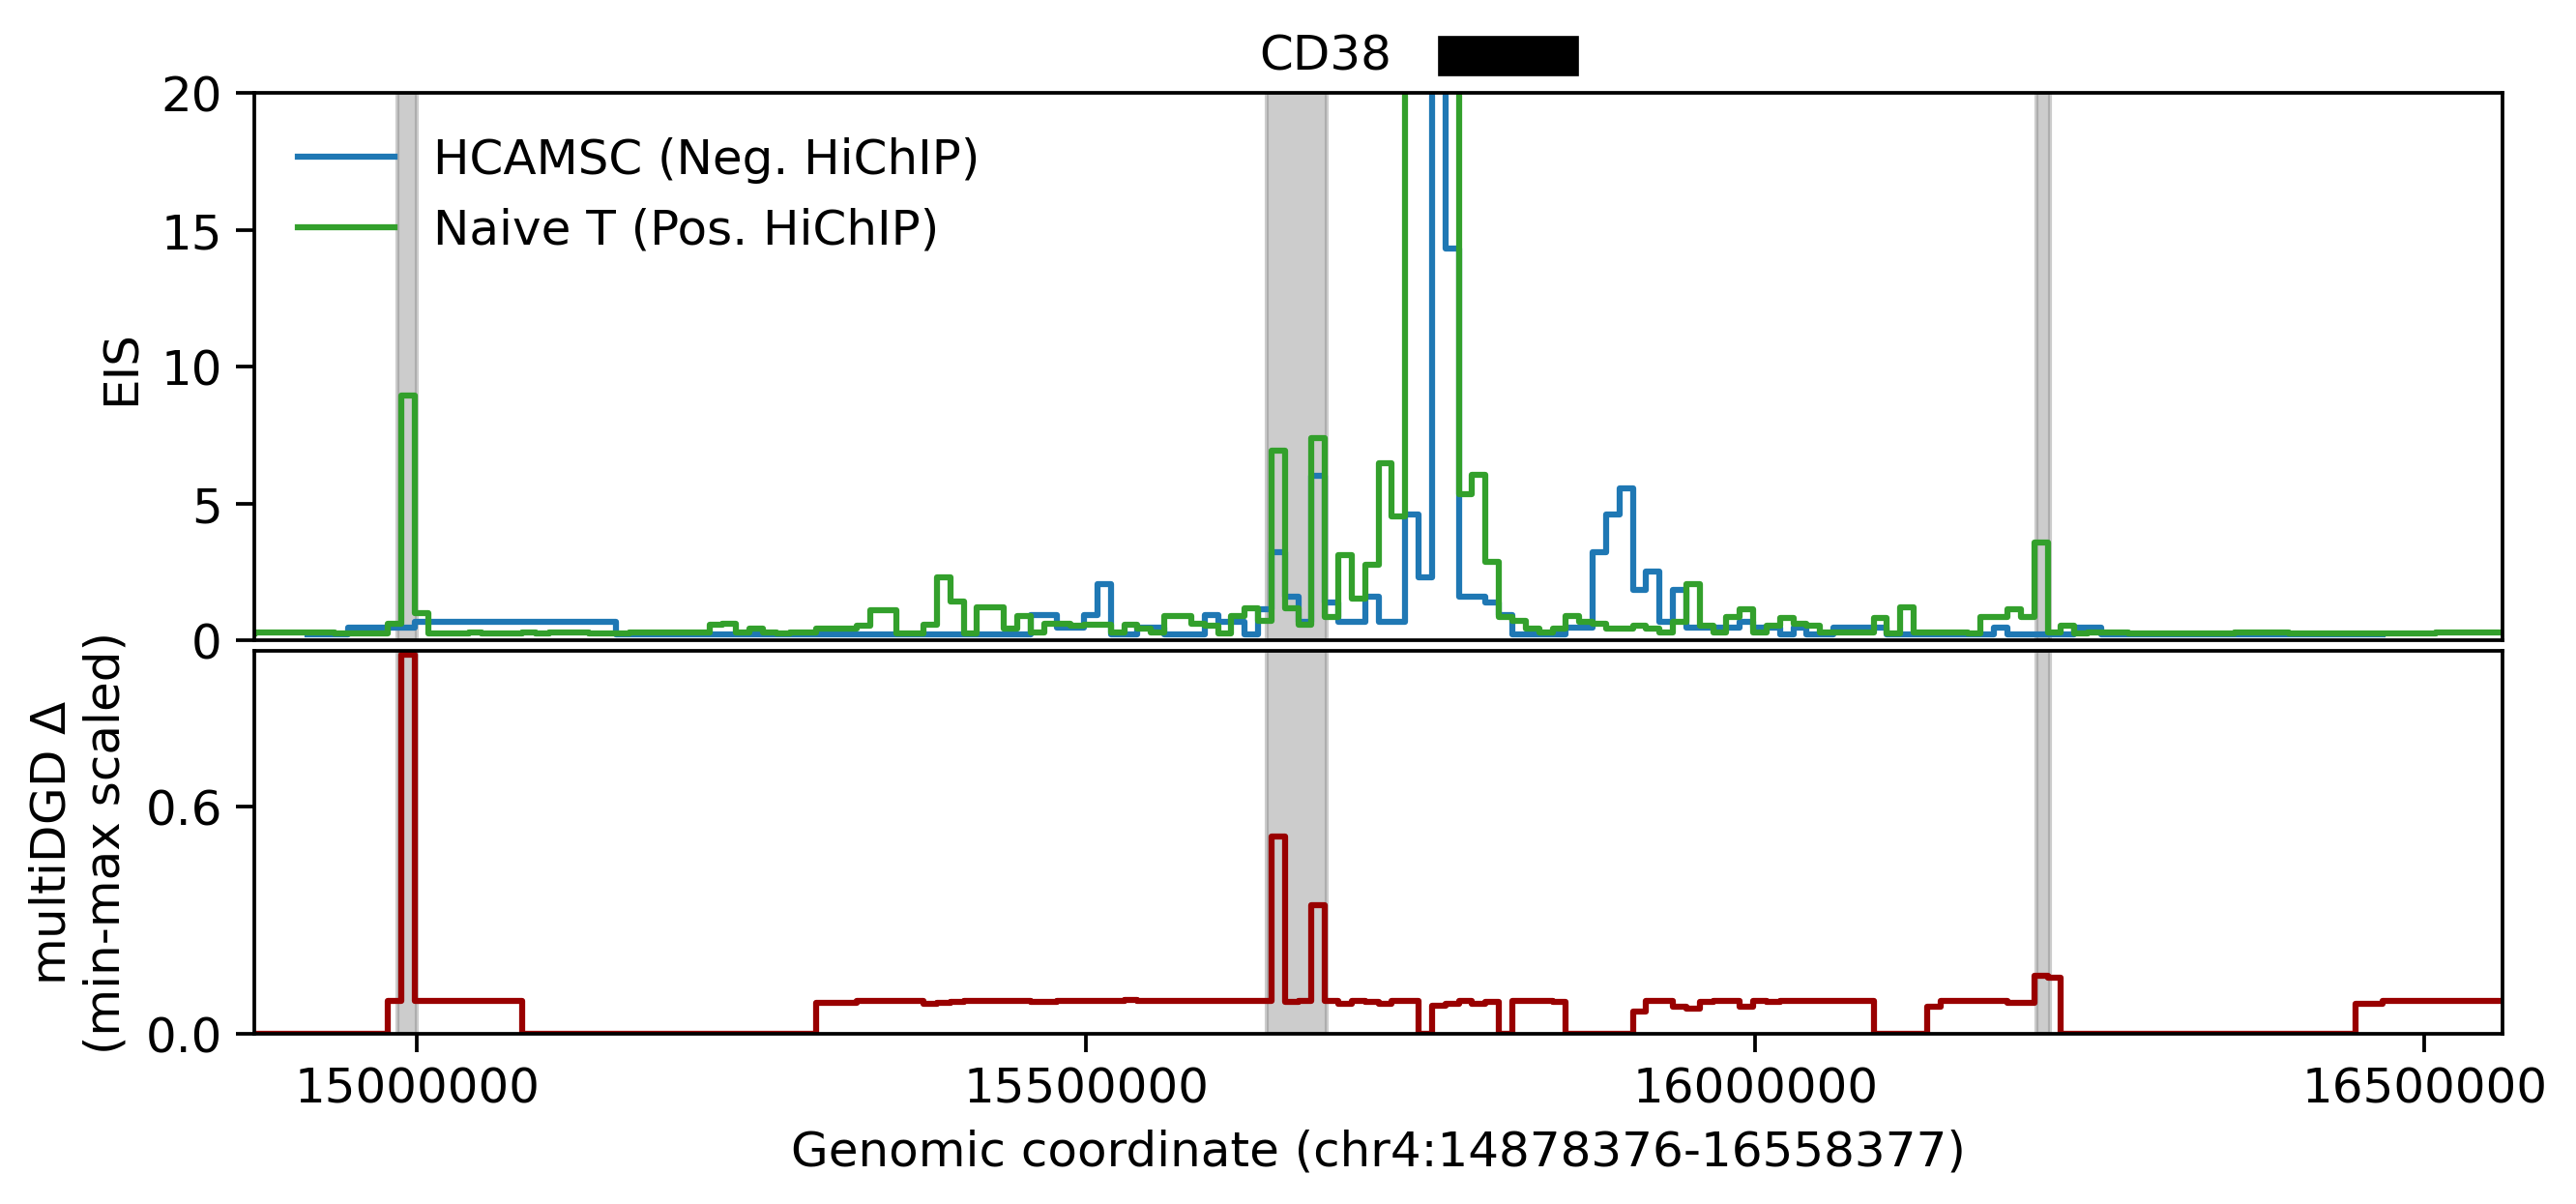

In [ ]:
gene = 'CD38'
eis_df = pd.read_csv(f'/pool2/tmp/yuliyi/ATACformer/data/hichip/preprocess/EIS_signal_{gene}_promoter.hg38.csv')
corr_df = pd.read_csv(outdir + f'{gene}_hg38_baseline_correlation.csv')
dgd_df = pd.read_csv(outdir + f'{gene}_hg38_hichip_multiDGD_aligned_locations.csv')
dgd_df['position'] = (dgd_df.position * 10e5).astype(int)
dgd_df['gene_name'] = gene
dgd_df['gene_coords'] = eis_df['gene_coords'][0]
dgd_df['chromosome'] = eis_df['chromosome'][0]
dgd_df['viewpoint'] = eis_df['viewpoint'][0]

highlight_regions = [
    (14985000, 15000000),
    (15635000, 15680000),
    (16210000, 16220000),
]
plot_virtual4C_gene_locus(dgd_df.reset_index(), highlight_regions, ymax=20, method='multiDGD')
plt.savefig(figdir + f'{gene}_tracks_multiDGD.pdf')

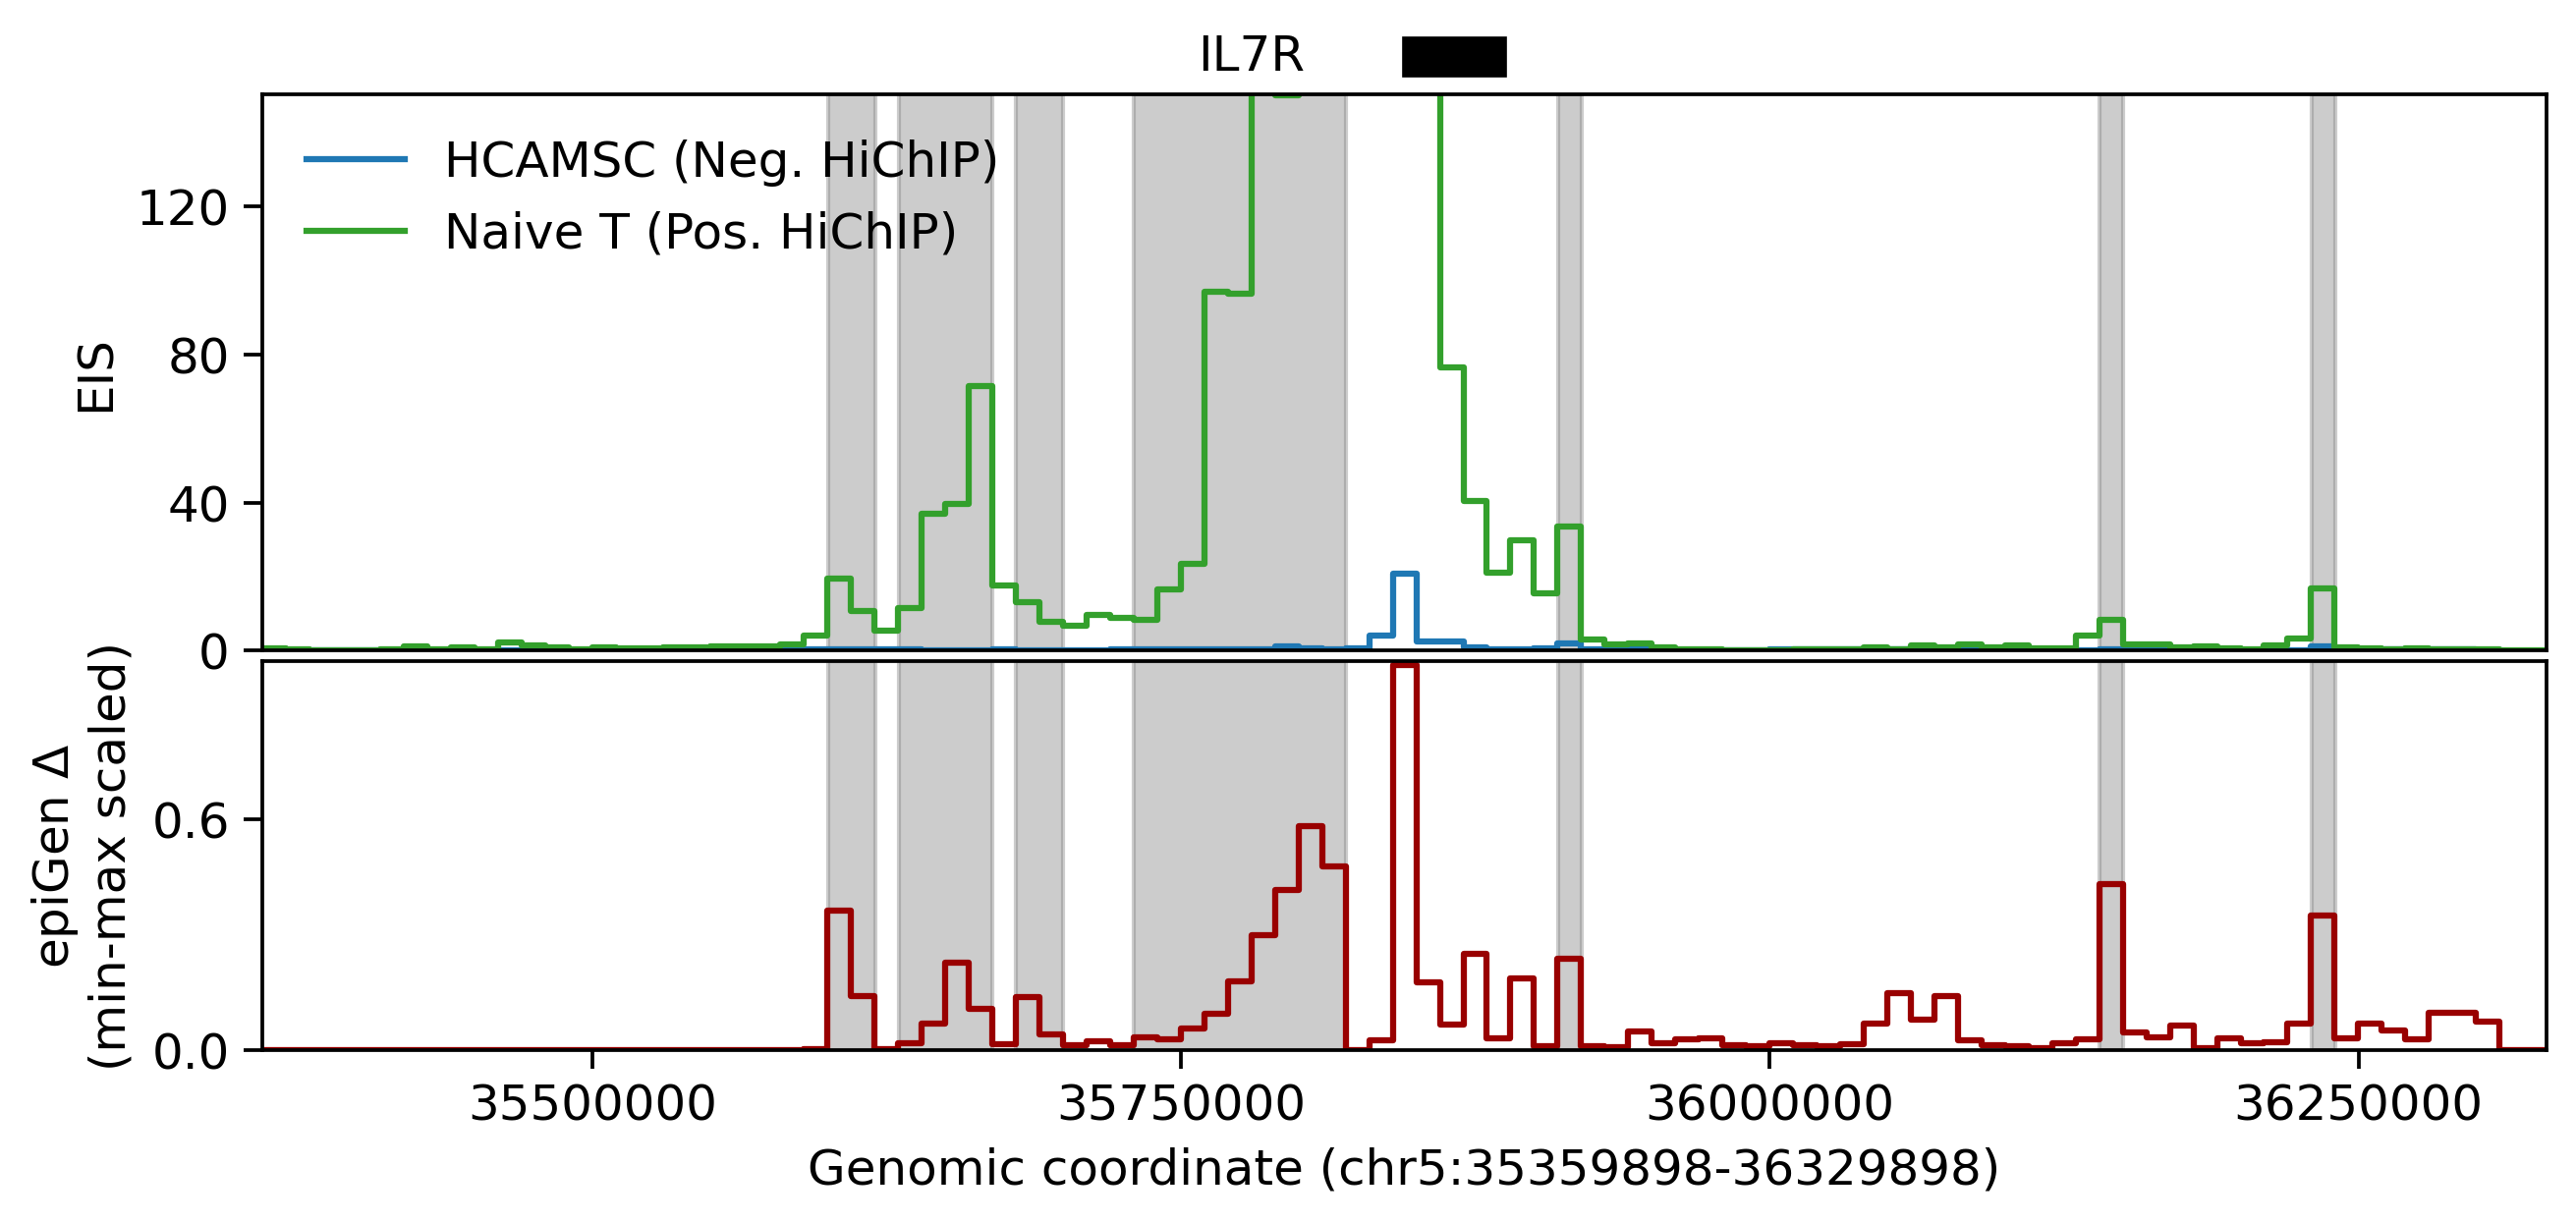

In [ ]:
gene = 'IL7R'
eis_df = pd.read_csv(f'/pool2/tmp/yuliyi/ATACformer/data/hichip/preprocess/EIS_signal_{gene}_promoter.hg38.csv')
corr_df = pd.read_csv(outdir + f'{gene}_hg38_baseline_correlation.csv')
dgd_df = pd.read_csv(outdir + f'{gene}_hg38_hichip_epiGen_aligned_locations.csv')
dgd_df['position'] = (dgd_df.position * 10e5).astype(int)
dgd_df['gene_name'] = gene
dgd_df['gene_coords'] = eis_df['gene_coords'][0]
dgd_df['chromosome'] = eis_df['chromosome'][0]
dgd_df['viewpoint'] = eis_df['viewpoint'][0]
highlight_regions = [
    (35600000, 35620000),
    (35630000, 35670000),
    (35680000, 35700000),
    (35730000, 35820000),
    (35910000, 35920000),
    (36140000, 36150000),
    (36230000, 36240000),
]
plot_virtual4C_gene_locus(dgd_df.reset_index(), highlight_regions, ymax=150)
plt.savefig(figdir + f'{gene}_tracks.pdf')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


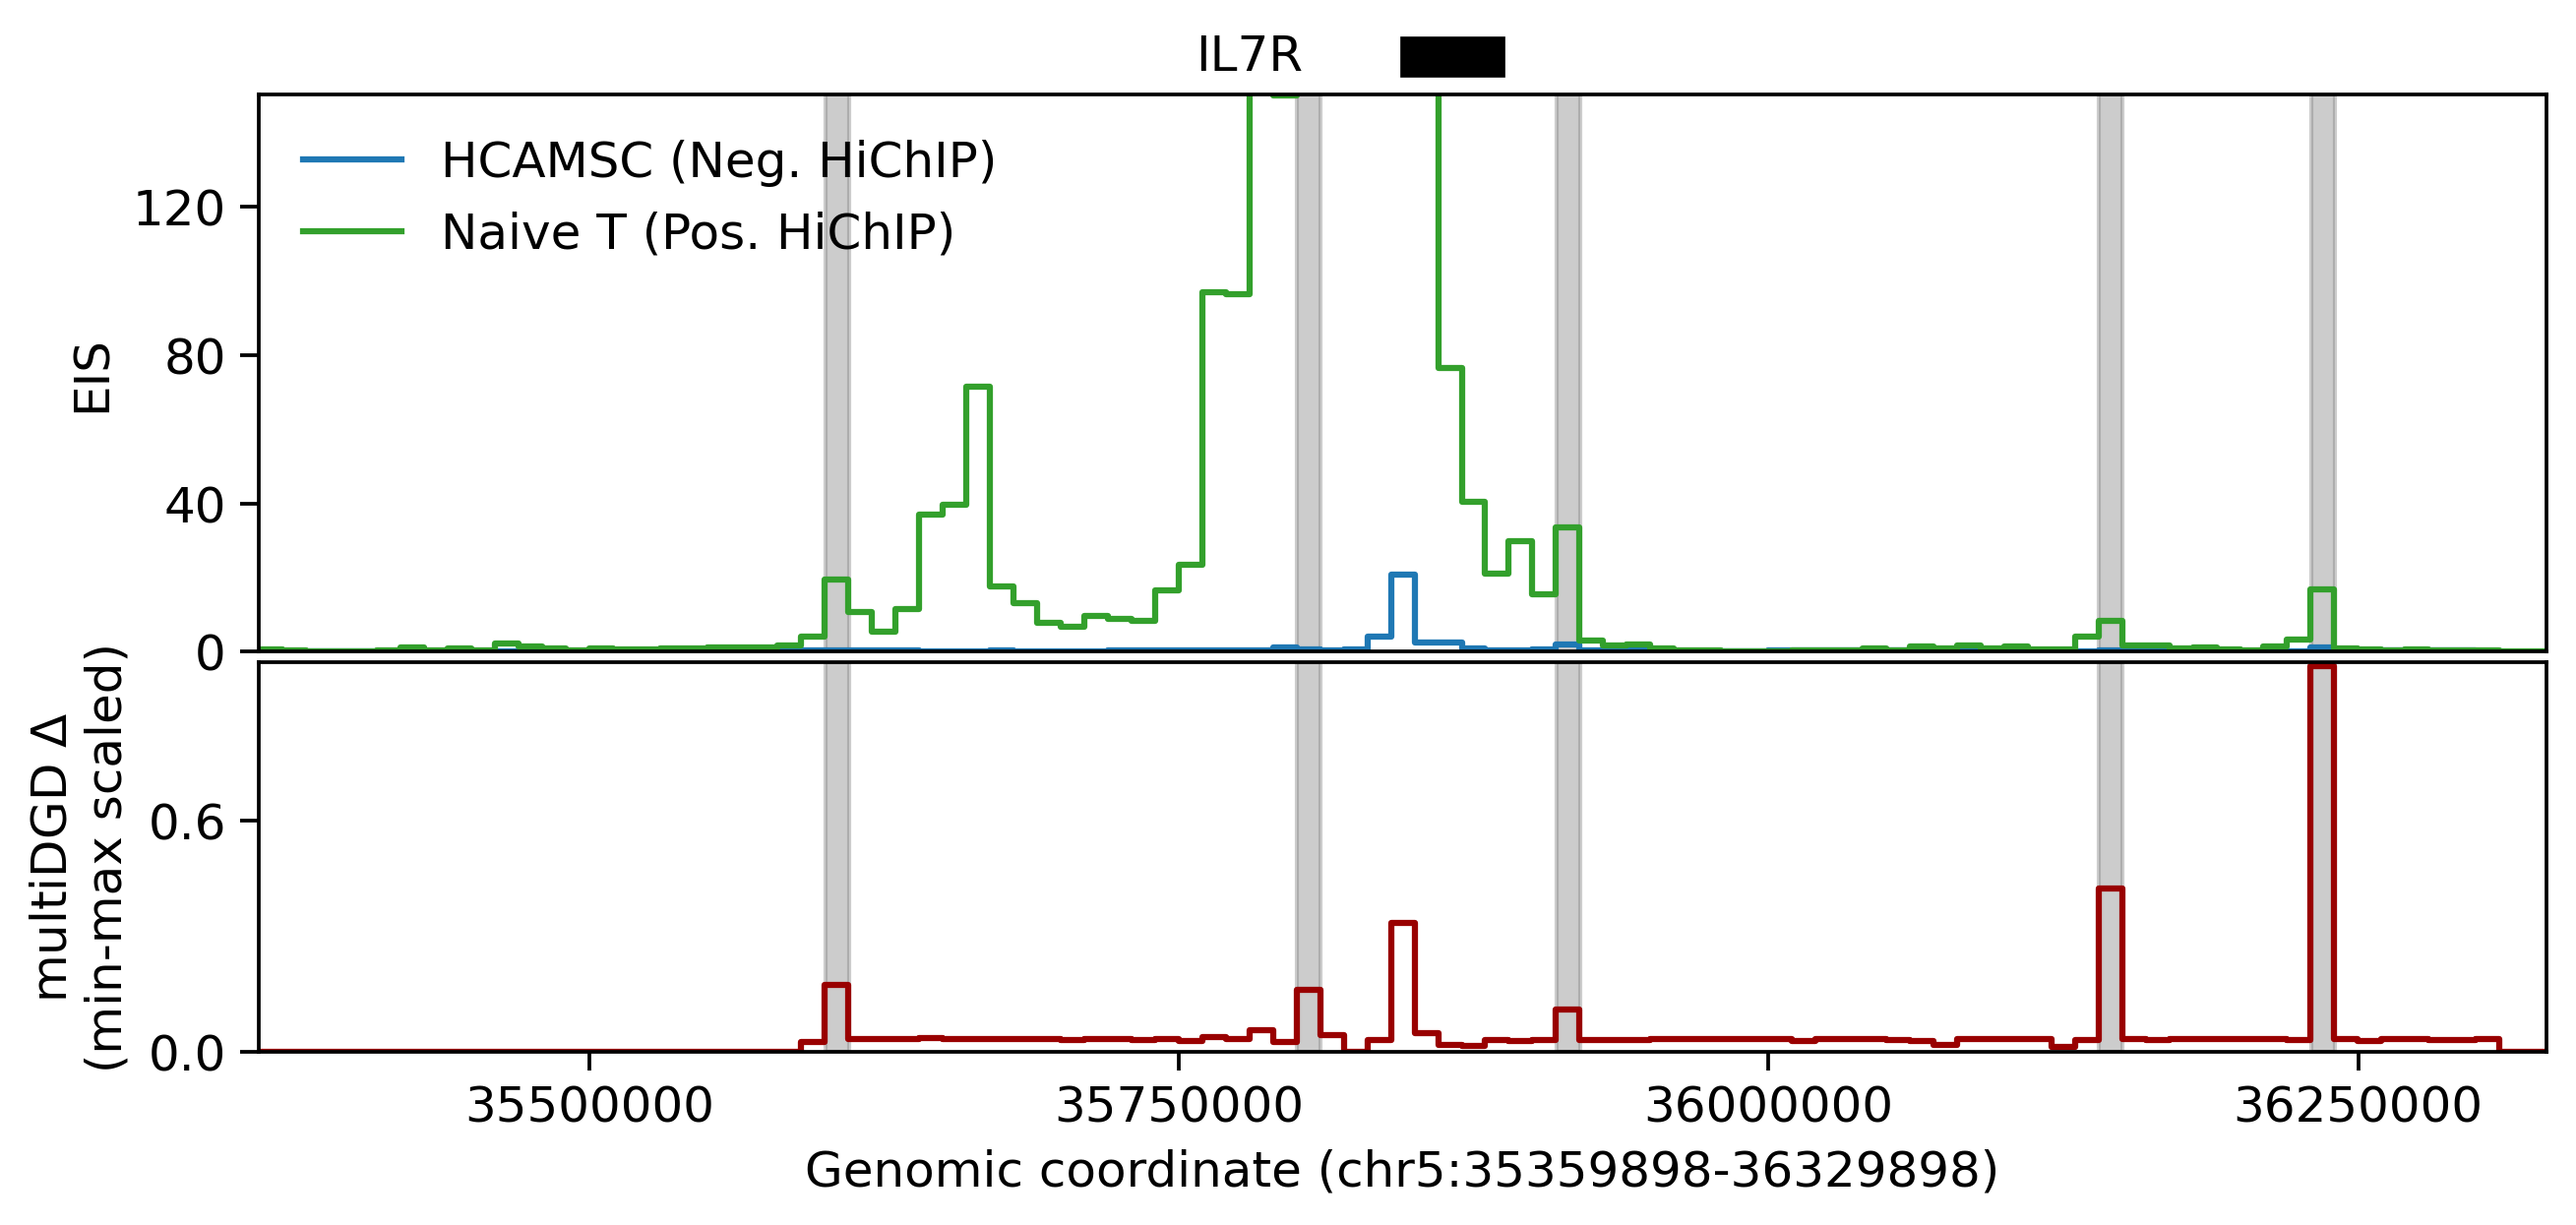

In [ ]:
gene = 'IL7R'
eis_df = pd.read_csv(f'/pool2/tmp/yuliyi/ATACformer/data/hichip/preprocess/EIS_signal_{gene}_promoter.hg38.csv')
corr_df = pd.read_csv(outdir + f'{gene}_hg38_baseline_correlation.csv')
dgd_df = pd.read_csv(outdir + f'{gene}_hg38_hichip_multiDGD_aligned_locations.csv')
dgd_df['position'] = (dgd_df.position * 10e5).astype(int)
dgd_df['gene_name'] = gene
dgd_df['gene_coords'] = eis_df['gene_coords'][0]
dgd_df['chromosome'] = eis_df['chromosome'][0]
dgd_df['viewpoint'] = eis_df['viewpoint'][0]
highlight_regions = [
    (35600000, 35610000),
    (35800000, 35810000),
    (35910000, 35920000),
    (36140000, 36150000),
    (36230000, 36240000),
]
plot_virtual4C_gene_locus(dgd_df.reset_index(), highlight_regions, ymax=150, method='multiDGD')
plt.savefig(figdir + f'{gene}_tracks_multiDGD.pdf')

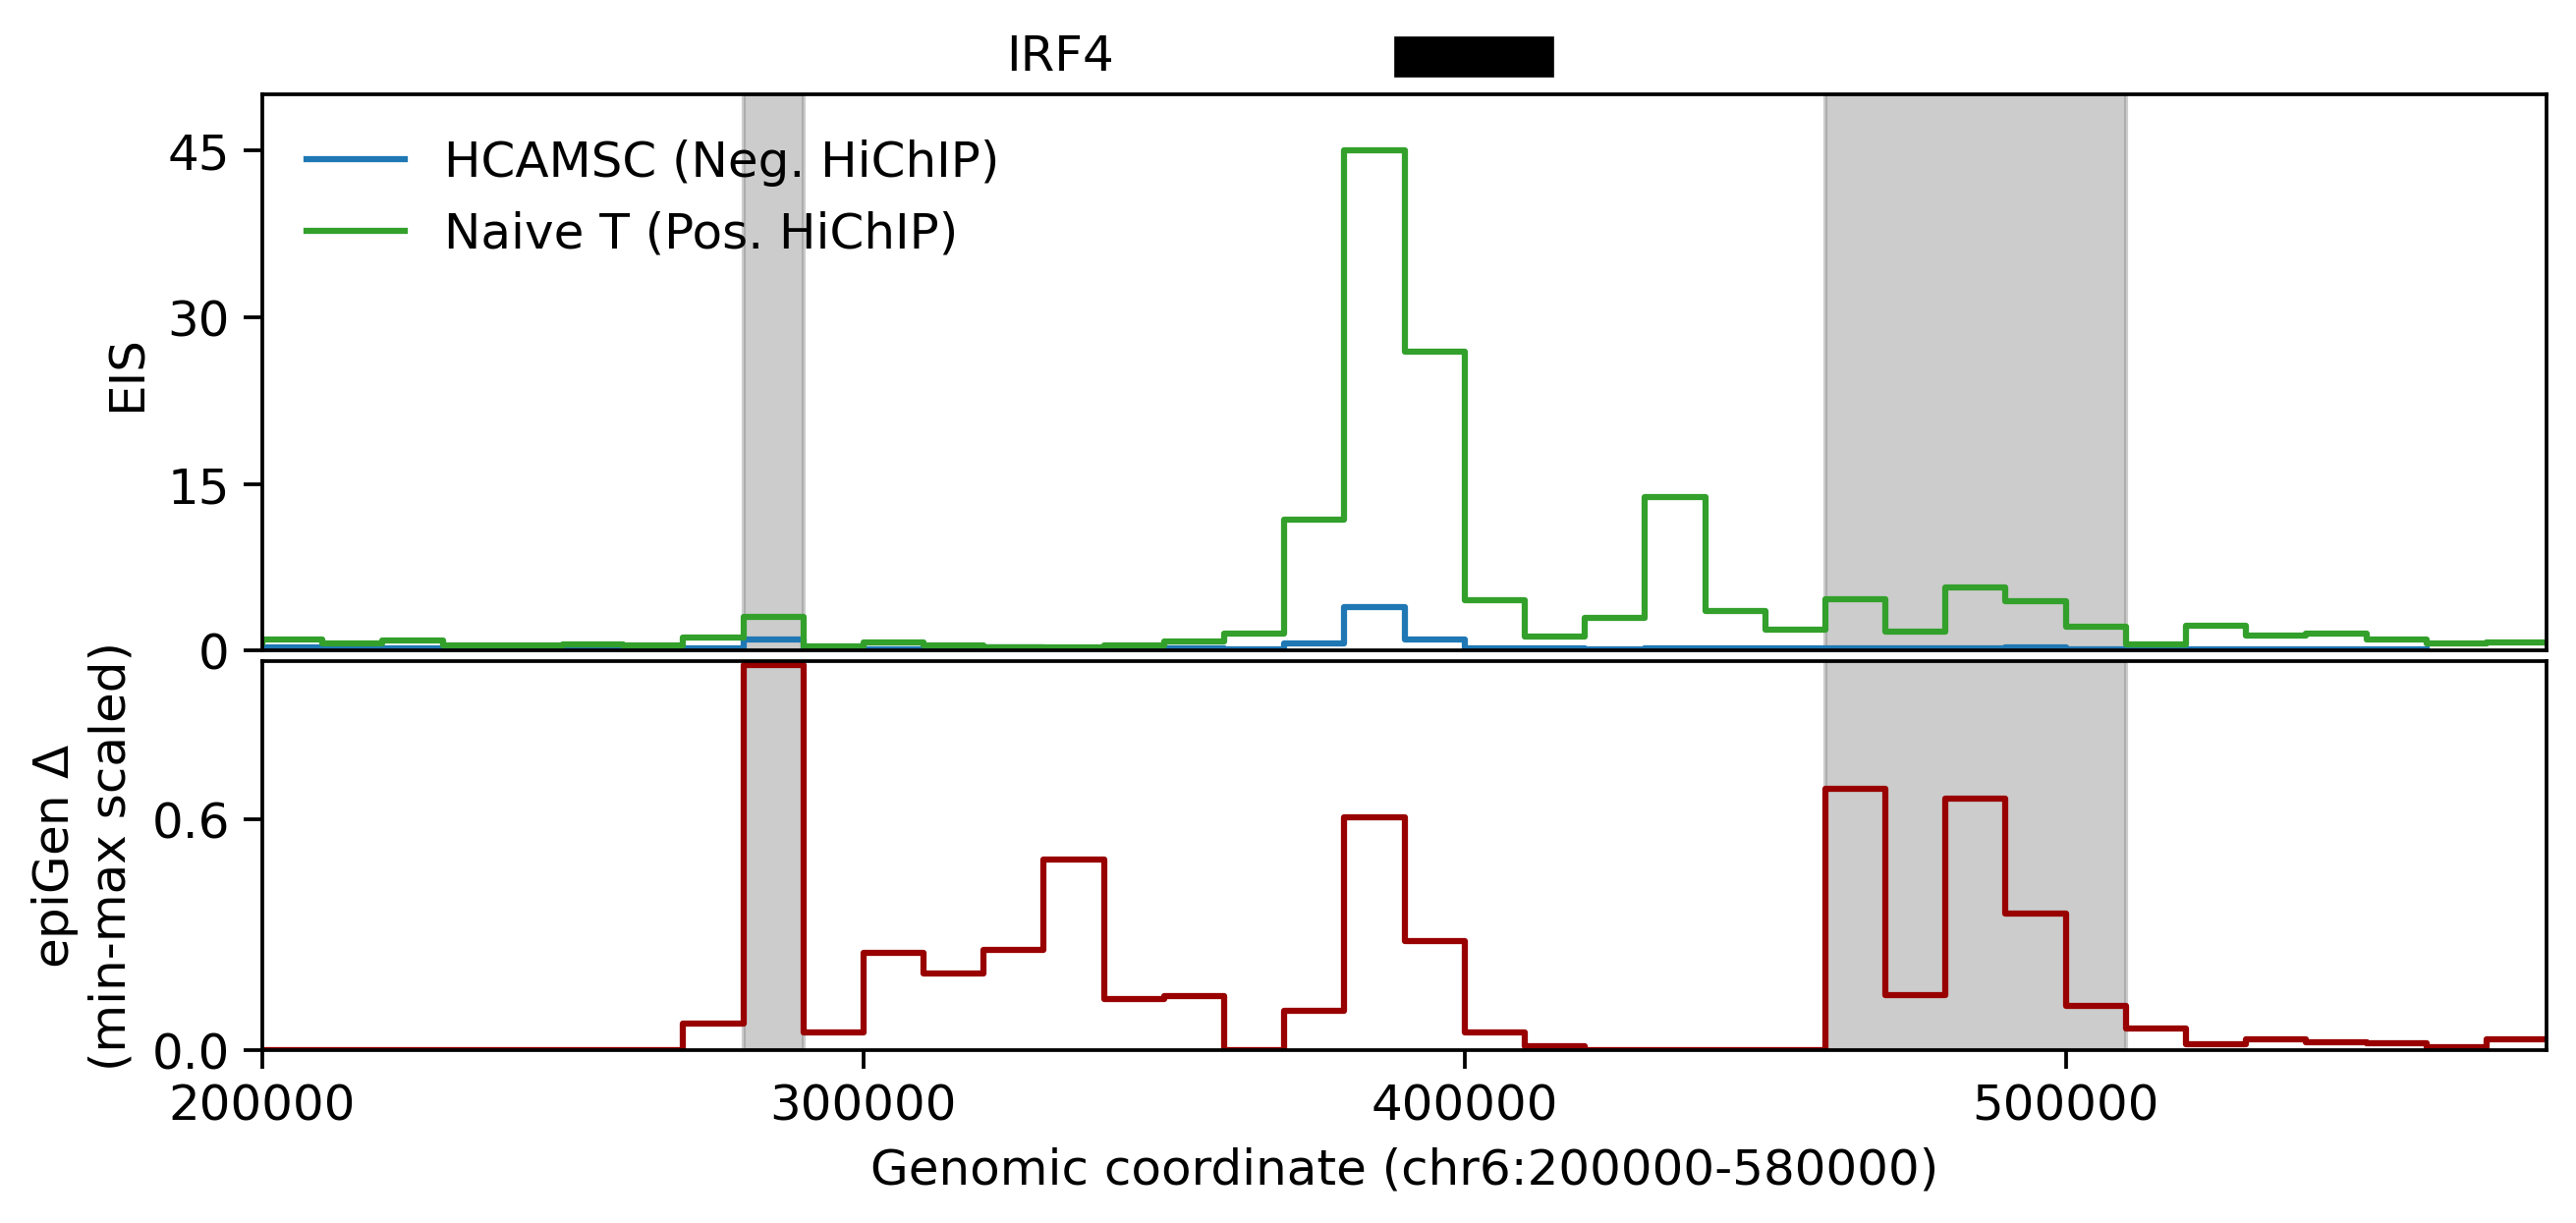

In [ ]:
gene = 'IRF4'
eis_df = pd.read_csv(f'/pool2/tmp/yuliyi/ATACformer/data/hichip/preprocess/EIS_signal_{gene}_promoter.hg38.csv')
corr_df = pd.read_csv(outdir + f'{gene}_hg38_baseline_correlation.csv')
dgd_df = pd.read_csv(outdir + f'{gene}_hg38_hichip_epiGen_aligned_locations.csv')
dgd_df['position'] = (dgd_df.position * 10e5).astype(int)
dgd_df['gene_name'] = gene
dgd_df['gene_coords'] = eis_df['gene_coords'][0]
dgd_df['chromosome'] = eis_df['chromosome'][0]
dgd_df['viewpoint'] = eis_df['viewpoint'][0]
highlight_regions = [
    (280000, 290000),
    (460000, 510000),
]
plot_virtual4C_gene_locus(dgd_df.reset_index(), highlight_regions, ymax=50)
plt.savefig(figdir + f'{gene}_tracks.pdf')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


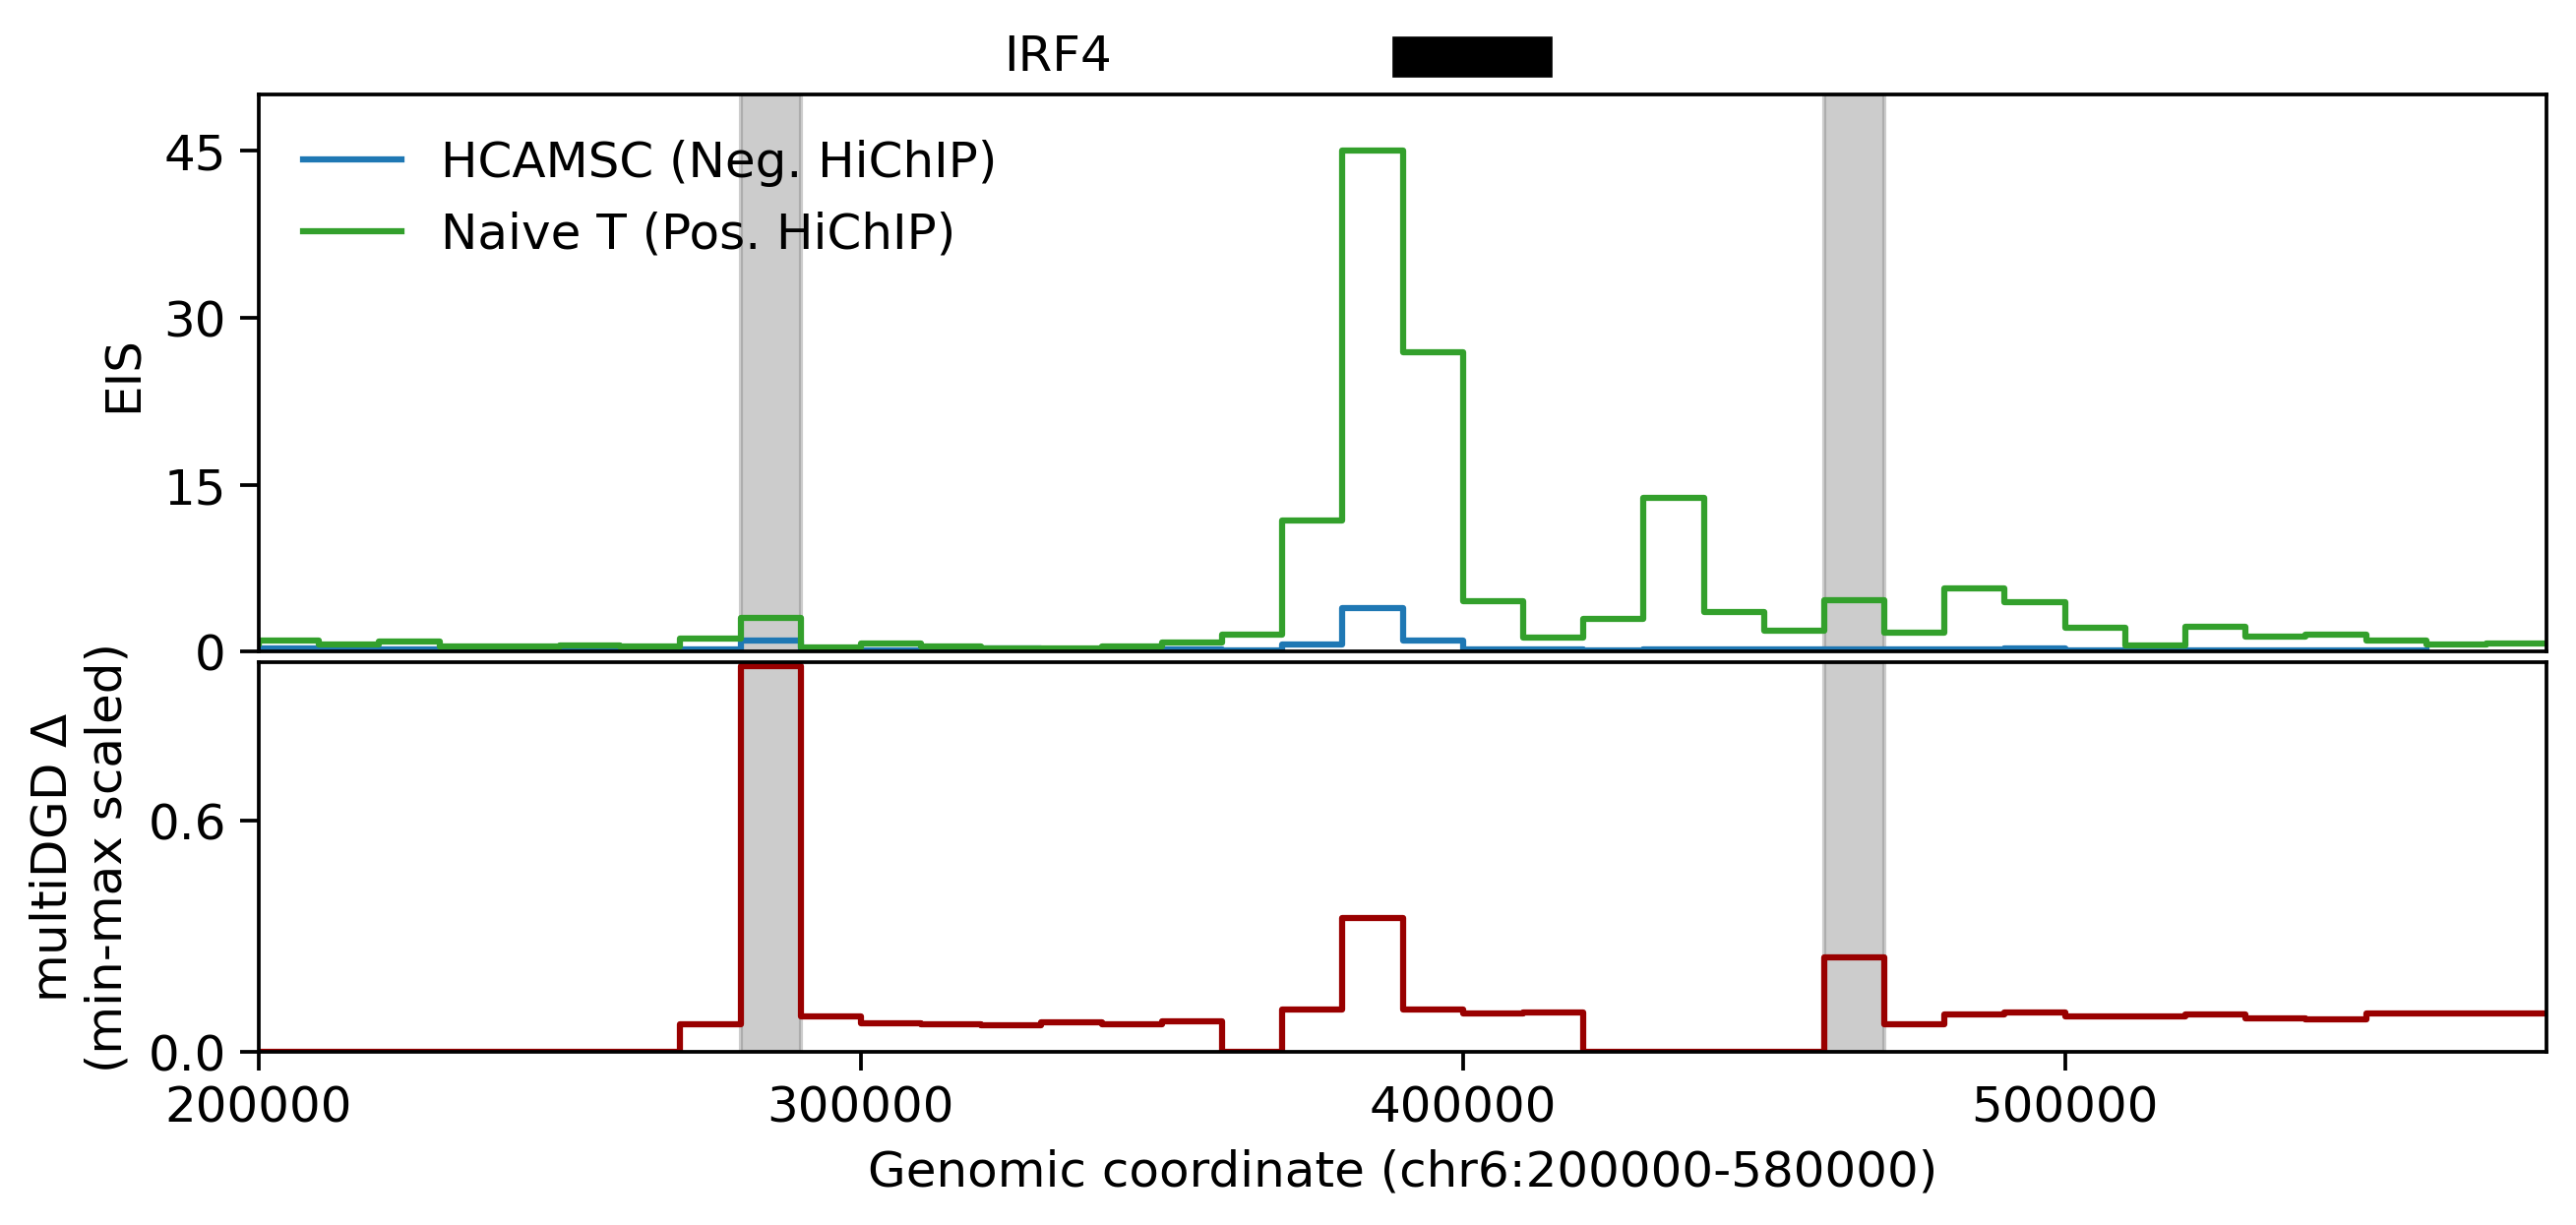

In [ ]:
gene = 'IRF4'
eis_df = pd.read_csv(f'/pool2/tmp/yuliyi/ATACformer/data/hichip/preprocess/EIS_signal_{gene}_promoter.hg38.csv')
corr_df = pd.read_csv(outdir + f'{gene}_hg38_baseline_correlation.csv')
dgd_df = pd.read_csv(outdir + f'{gene}_hg38_hichip_multiDGD_aligned_locations.csv')
dgd_df['position'] = (dgd_df.position * 10e5).astype(int)
dgd_df['gene_name'] = gene
dgd_df['gene_coords'] = eis_df['gene_coords'][0]
dgd_df['chromosome'] = eis_df['chromosome'][0]
dgd_df['viewpoint'] = eis_df['viewpoint'][0]
highlight_regions = [
    (270000, 290000),
    (460000, 470000),
]
plot_virtual4C_gene_locus(dgd_df.reset_index(), highlight_regions, ymax=50, method='multiDGD')
plt.savefig(figdir + f'{gene}_tracks_multiDGD.pdf')

### Plot ROC curves

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

def plot_roc(dgd_df, plot_auroc=False):
    legend_x_dist, legend_y_dist = -0.02, 0.0
    plt.rcParams['font.size'] = 12
    plt.rcParams['figure.figsize'] = 5.5,5.5
    matched_ct = dgd_df[dgd_df['cell type'] == 'T']

    hichip_pos = dgd_df[dgd_df['cell type'] == 'positive'].copy()
    hichip_pos['is_linked_pos'] = hichip_pos.signal > hichip_pos.signal.quantile(0.75)

    hichip_neg = dgd_df[dgd_df['cell type'] == 'negative'].copy()
    hichip_neg['is_linked_neg'] = hichip_neg.signal > hichip_neg.signal.quantile(0.75)

    matched_ct = pd.merge(matched_ct, hichip_neg[['position', 'is_linked_neg']])
    matched_ct = pd.merge(matched_ct, hichip_pos[['position', 'is_linked_pos']])

    # perturbation signal on positive
    precision, recall, _ =  precision_recall_curve(matched_ct.is_linked_pos, matched_ct.signal)
    auprc = auc(recall, precision)
    plt.plot(recall, precision, color='#3FC097',label=f'Naive T signal - Pos. HiChIP\nAUPRC = {np.round(auprc, 3)}')
    
    # perturbation signal on negative
    precision, recall, _ =  precision_recall_curve(matched_ct.is_linked_neg, matched_ct.signal)
    auprc = auc(recall, precision)
    plt.plot(recall, precision, color='#7091DD', label=f'Naive T signal - Neg. HiChIP\nAUPRC = {np.round(auprc, 3)}')

    plt.ylabel('Precision'); plt.xlabel("Recall")
    plt.legend(bbox_to_anchor=(1.+legend_x_dist, 1.+legend_y_dist), 
                   loc='upper left', frameon=False,
                   handletextpad=0.1)
    plt.axline((min(recall), min(precision)), slope=1, color="grey", linestyle=':')

In [6]:
auroc_df = pd.DataFrame()
qt = 0.75
for gene in ['CD69', 'CD38', 'IL7R', 'IRF4']:
    corr_df = pd.read_csv(outdir + f'{gene}_hg38_baseline_correlation.csv')
    epiGen_df = pd.read_csv(outdir + f'{gene}_hg38_hichip_epiGen_aligned_locations.csv')
    dgd_df = pd.read_csv(outdir + f'{gene}_hg38_hichip_multiDGD_aligned_locations.csv')
    dgd_df = pd.concat([epiGen_df, dgd_df, corr_df])
    dgd_df['gene_name'] = gene
    
    # epiGen results
    df = dgd_df[dgd_df.method.isin(['epiGen', 'HiChIP'])].copy()
    matched_ct = df[df['cell type'] == 'T']
    hichip_pos = df[df['cell type'] == 'positive'].copy()
    hichip_pos['is_linked_pos'] = hichip_pos.signal > hichip_pos.signal.quantile(qt)
    print('hichip pos enhancer percentage: ', np.sum(hichip_pos['is_linked_pos']) / len(hichip_pos['is_linked_pos']))

    hichip_neg = df[df['cell type'] == 'negative'].copy()
    hichip_neg['is_linked_neg'] = hichip_neg.signal > hichip_neg.signal.quantile(qt)
    print('hichip neg enhancer percentage: ', np.sum(hichip_neg['is_linked_neg']) / len(hichip_neg['is_linked_neg']))

    matched_ct = pd.merge(matched_ct, hichip_neg[['position', 'is_linked_neg']])
    matched_ct = pd.merge(matched_ct, hichip_pos[['position', 'is_linked_pos']])

    fpr, tpr, _ =  roc_curve(matched_ct.is_linked_pos, matched_ct.signal)
    precision, recall, _ =  precision_recall_curve(matched_ct.is_linked_pos, matched_ct.signal)
    auroc = auc(fpr, tpr)
    auprc = auc(recall, precision)
    auroc_df = pd.concat([auroc_df, pd.DataFrame(['Naive T', 'Pos HiChIP', auroc, auprc, 'epiGen', gene]).T])
    fpr, tpr, _ =  roc_curve(matched_ct.is_linked_neg, matched_ct.signal)
    precision, recall, _ =  precision_recall_curve(matched_ct.is_linked_neg, matched_ct.signal)
    auroc = auc(fpr, tpr)
    auprc = auc(recall, precision)
    auroc_df = pd.concat([auroc_df, pd.DataFrame(['Naive T', 'Neg HiChIP', auroc, auprc, 'epiGen', gene]).T])

    # multiDGD results
    df = dgd_df[dgd_df.method.isin(['multiDGD', 'HiChIP'])].copy()
    matched_ct = df[df['cell type'] == 'T']
    hichip_pos = df[df['cell type'] == 'positive'].copy()
    hichip_pos['is_linked_pos'] = hichip_pos.signal > hichip_pos.signal.quantile(qt)
    print('hichip pos enhancer percentage: ', np.sum(hichip_pos['is_linked_pos']) / len(hichip_pos['is_linked_pos']))

    hichip_neg = df[df['cell type'] == 'negative'].copy()
    hichip_neg['is_linked_neg'] = hichip_neg.signal > hichip_neg.signal.quantile(qt)
    print('hichip neg enhancer percentage: ', np.sum(hichip_neg['is_linked_neg']) / len(hichip_neg['is_linked_neg']))

    matched_ct = pd.merge(matched_ct, hichip_neg[['position', 'is_linked_neg']])
    matched_ct = pd.merge(matched_ct, hichip_pos[['position', 'is_linked_pos']])

    fpr, tpr, _ =  roc_curve(matched_ct.is_linked_pos, matched_ct.signal)
    precision, recall, _ =  precision_recall_curve(matched_ct.is_linked_pos, matched_ct.signal)
    auroc = auc(fpr, tpr)
    auprc = auc(recall, precision)
    auroc_df = pd.concat([auroc_df, pd.DataFrame(['Naive T', 'Pos HiChIP', auroc, auprc, 'multiDGD', gene]).T])
    fpr, tpr, _ =  roc_curve(matched_ct.is_linked_neg, matched_ct.signal)
    precision, recall, _ =  precision_recall_curve(matched_ct.is_linked_neg, matched_ct.signal)
    auroc = auc(fpr, tpr)
    auprc = auc(recall, precision)
    auroc_df = pd.concat([auroc_df, pd.DataFrame(['Naive T', 'Neg HiChIP', auroc, auprc, 'multiDGD', gene]).T])

    # Spearman results
    df = dgd_df[dgd_df.method.isin(['Spearman', 'HiChIP'])].copy()
    matched_ct = df[df['cell type'] == 'T']
    hichip_pos = df[df['cell type'] == 'positive'].copy()
    hichip_pos['is_linked_pos'] = hichip_pos.signal > hichip_pos.signal.quantile(qt)

    hichip_neg = df[df['cell type'] == 'negative'].copy()
    hichip_neg['is_linked_neg'] = hichip_neg.signal > hichip_neg.signal.quantile(qt)

    matched_ct = pd.merge(matched_ct, hichip_neg[['position', 'is_linked_neg']])
    matched_ct = pd.merge(matched_ct, hichip_pos[['position', 'is_linked_pos']])

    fpr, tpr, _ =  roc_curve(matched_ct.is_linked_pos, matched_ct.signal)
    precision, recall, _ =  precision_recall_curve(matched_ct.is_linked_pos, matched_ct.signal)
    auroc = auc(fpr, tpr)
    auprc = auc(recall, precision)
    auroc_df = pd.concat([auroc_df, pd.DataFrame(['Naive T', 'Pos HiChIP', auroc, auprc, 'Spearman', gene]).T])
    fpr, tpr, _ =  roc_curve(matched_ct.is_linked_neg, matched_ct.signal)
    precision, recall, _ =  precision_recall_curve(matched_ct.is_linked_neg, matched_ct.signal)
    auroc = auc(fpr, tpr)
    auprc = auc(recall, precision)
    auroc_df = pd.concat([auroc_df, pd.DataFrame(['Naive T', 'Neg HiChIP', auroc, auprc, 'Spearman', gene]).T])


hichip pos enhancer percentage:  0.24
hichip neg enhancer percentage:  0.2391304347826087
hichip pos enhancer percentage:  0.24
hichip neg enhancer percentage:  0.2391304347826087
hichip pos enhancer percentage:  0.24778761061946902
hichip neg enhancer percentage:  0.23076923076923078
hichip pos enhancer percentage:  0.24778761061946902
hichip neg enhancer percentage:  0.23076923076923078
hichip pos enhancer percentage:  0.25263157894736843
hichip neg enhancer percentage:  0.25
hichip pos enhancer percentage:  0.25263157894736843
hichip neg enhancer percentage:  0.25
hichip pos enhancer percentage:  0.2564102564102564
hichip neg enhancer percentage:  0.2
hichip pos enhancer percentage:  0.2564102564102564
hichip neg enhancer percentage:  0.2


In [7]:
auroc_df.columns = ['cell_type', 'HiChIP_track', 'AUROC', 'AUPRC', 'method', 'gene']
auroc_df['class'] = auroc_df.cell_type + ' - '+ auroc_df.HiChIP_track

In [8]:
auroc_df[(auroc_df['method'] == 'epiGen')]

,cell_type,HiChIP_track,AUROC,AUPRC,method,gene,class
0,Naive T,Pos HiChIP,0.600962,0.537808,epiGen,CD69,Naive T - Pos HiChIP
0,Naive T,Neg HiChIP,0.44385,0.388927,epiGen,CD69,Naive T - Neg HiChIP
0,Naive T,Pos HiChIP,0.726087,0.593819,epiGen,CD38,Naive T - Pos HiChIP
0,Naive T,Neg HiChIP,0.554398,0.356874,epiGen,CD38,Naive T - Neg HiChIP
0,Naive T,Pos HiChIP,0.826049,0.831378,epiGen,IL7R,Naive T - Pos HiChIP
0,Naive T,Neg HiChIP,0.72338,0.596116,epiGen,IL7R,Naive T - Neg HiChIP
0,Naive T,Pos HiChIP,0.8525,0.825025,epiGen,IRF4,Naive T - Pos HiChIP
0,Naive T,Neg HiChIP,0.847222,0.537812,epiGen,IRF4,Naive T - Neg HiChIP


In [9]:
auroc_df[(auroc_df['method'] == 'Spearman')]

,cell_type,HiChIP_track,AUROC,AUPRC,method,gene,class
0,Naive T,Pos HiChIP,0.574519,0.402206,Spearman,CD69,Naive T - Pos HiChIP
0,Naive T,Neg HiChIP,0.457219,0.325416,Spearman,CD69,Naive T - Neg HiChIP
0,Naive T,Pos HiChIP,0.74837,0.596458,Spearman,CD38,Naive T - Pos HiChIP
0,Naive T,Neg HiChIP,0.58912,0.343137,Spearman,CD38,Naive T - Neg HiChIP
0,Naive T,Pos HiChIP,0.692308,0.600893,Spearman,IL7R,Naive T - Pos HiChIP
0,Naive T,Neg HiChIP,0.652778,0.376748,Spearman,IL7R,Naive T - Neg HiChIP
0,Naive T,Pos HiChIP,0.695,0.510556,Spearman,IRF4,Naive T - Pos HiChIP
0,Naive T,Neg HiChIP,0.809028,0.455324,Spearman,IRF4,Naive T - Neg HiChIP


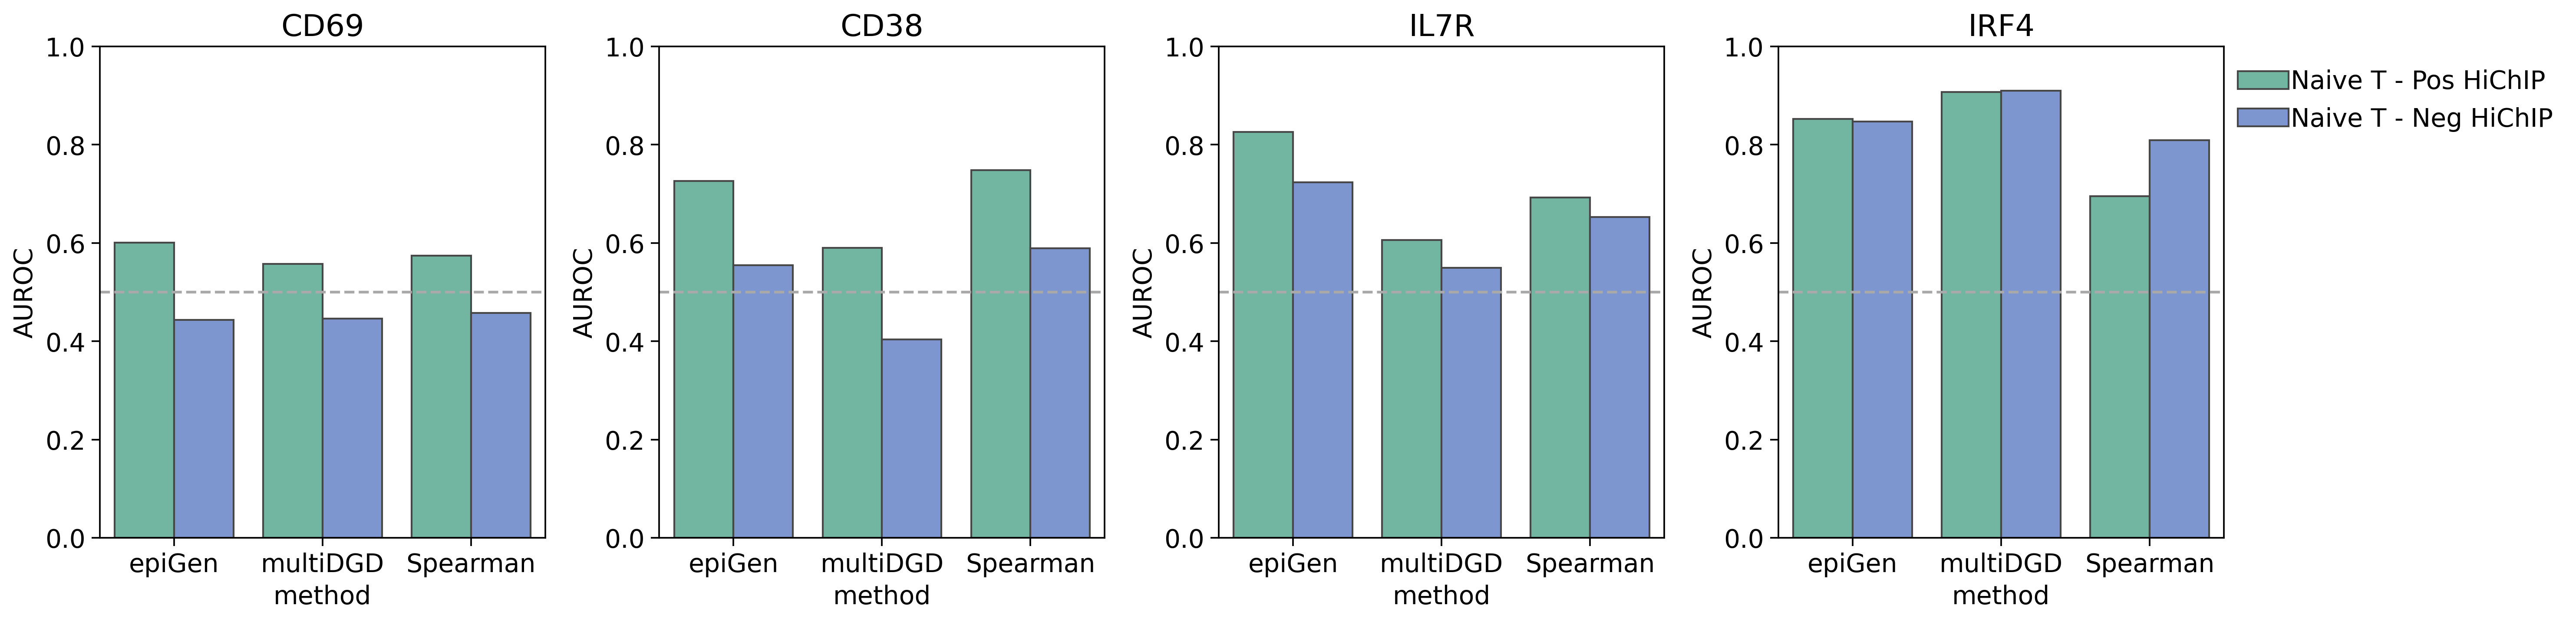

In [10]:
plt.rcParams['figure.figsize'] = [20,5]
plt.rcParams['font.size'] = 14
for i,gene in enumerate(['CD69', 'CD38', 'IL7R', 'IRF4']):
    plt.subplot(1,4,i+1)
    legend_x_dist, legend_y_dist = -0.02, 0.0
    # '#33a02c', '#1f78b4'
    palette_auroc = {
        'Naive T - Pos HiChIP':'#66C2A5', 
        'Naive T - Neg HiChIP':"#7091DD",
    }
    sns.barplot(data=auroc_df[auroc_df.gene == gene], x='method', y='AUROC', hue='class', palette=palette_auroc, edgecolor='#474747')
    if i == 3:
        plt.legend(bbox_to_anchor=(1.+legend_x_dist, 1.+legend_y_dist), 
                           loc='upper left', frameon=False,
                           handletextpad=0.1)
    else:
        plt.legend([], frameon=False)
    plt.title(gene)
    plt.axhline(0.5,  color='darkgrey', linestyle='--')
    plt.ylim(0,1)
plt.tight_layout()
plt.savefig(figdir + 'AUROC_barplot_all.pdf')
# plt.savefig(figdir + 'AUROC_barplot_all.svg')
# plt.savefig(figdir + 'AUROC_barplot_all.eps')
# plt.savefig(figdir + 'AUROC_barplot_all.tiff')

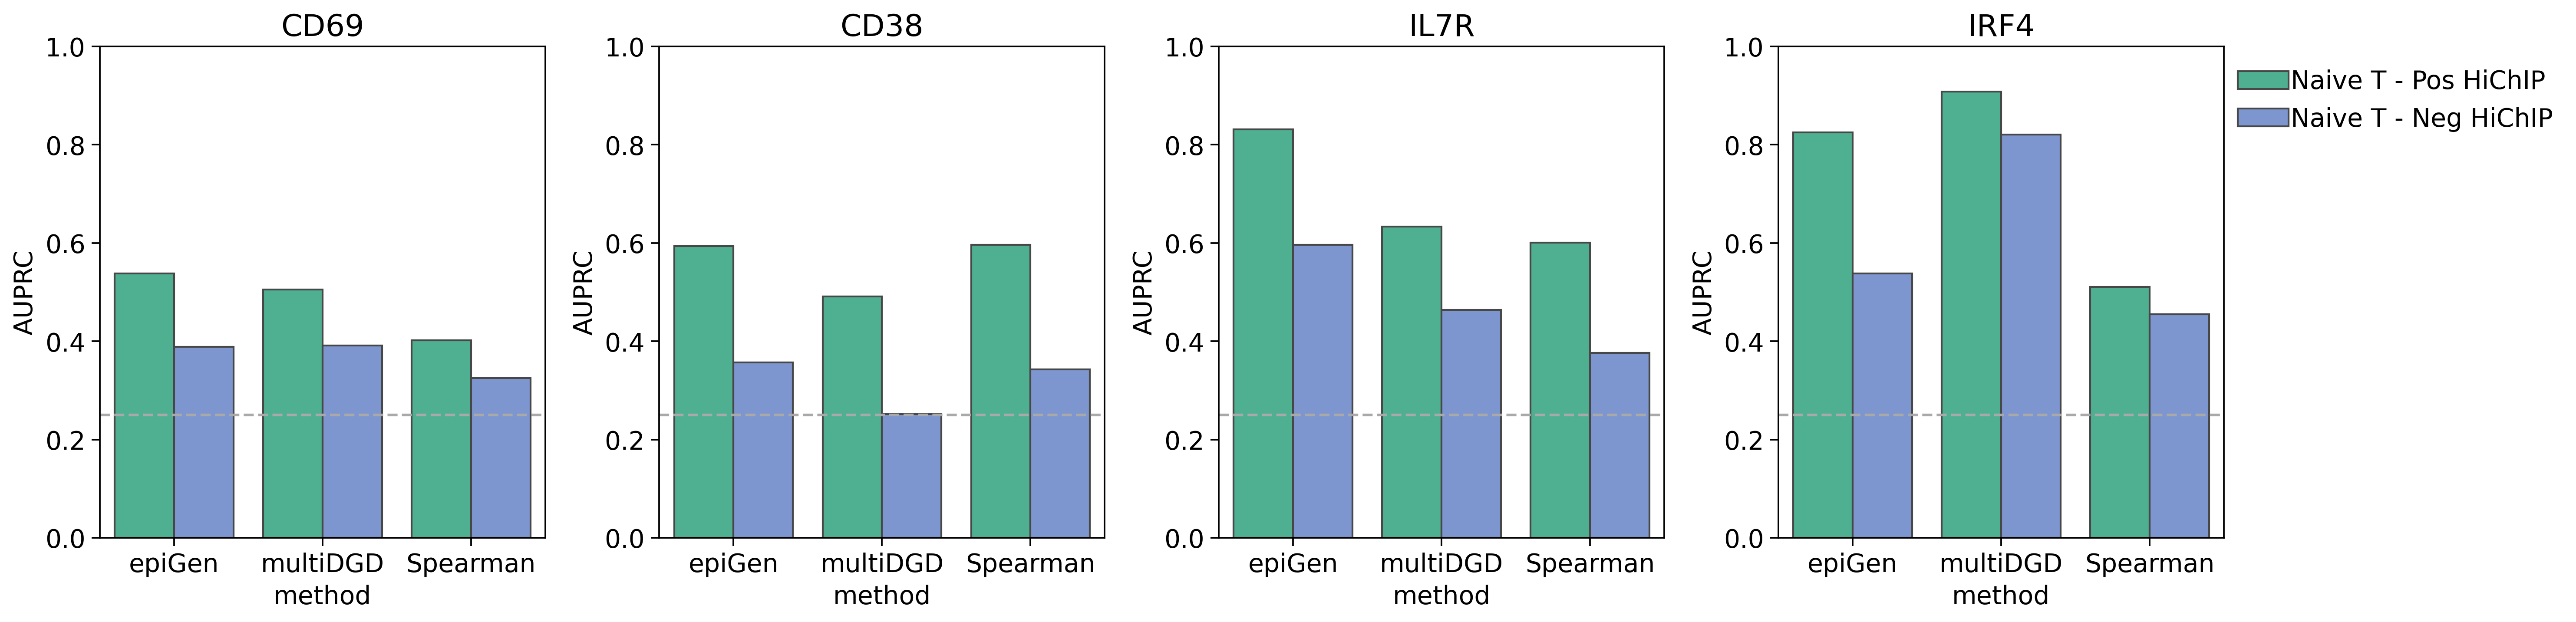

In [11]:
plt.rcParams['figure.figsize'] = [20,5]
plt.rcParams['font.size'] = 14
for i,gene in enumerate(['CD69', 'CD38', 'IL7R', 'IRF4']):
    plt.subplot(1,4,i+1)
    legend_x_dist, legend_y_dist = -0.02, 0.0

    palette_auroc = {
        'Naive T - Pos HiChIP':"#3FC097", 
        'Naive T - Neg HiChIP':"#7091DD",
    }
    sns.barplot(data=auroc_df[auroc_df.gene == gene], x='method', y='AUPRC', hue='class', palette=palette_auroc, edgecolor='#474747')
    if i == 3:
        plt.legend(bbox_to_anchor=(1.+legend_x_dist, 1.+legend_y_dist), 
                           loc='upper left', frameon=False,
                           handletextpad=0.1)
    else:
        plt.legend([], frameon=False)
    plt.title(gene)
    plt.axhline(0.25,  color='darkgrey', linestyle='--')
    plt.ylim(0,1)
plt.tight_layout()
plt.savefig(figdir + 'AUPRC_barplot_all.pdf')
# plt.savefig(figdir + 'AUPRC_barplot_all.svg')
# plt.savefig(figdir + 'AUPRC_barplot_all.eps')
# plt.savefig(figdir + 'AUPRC_barplot_all.tiff')

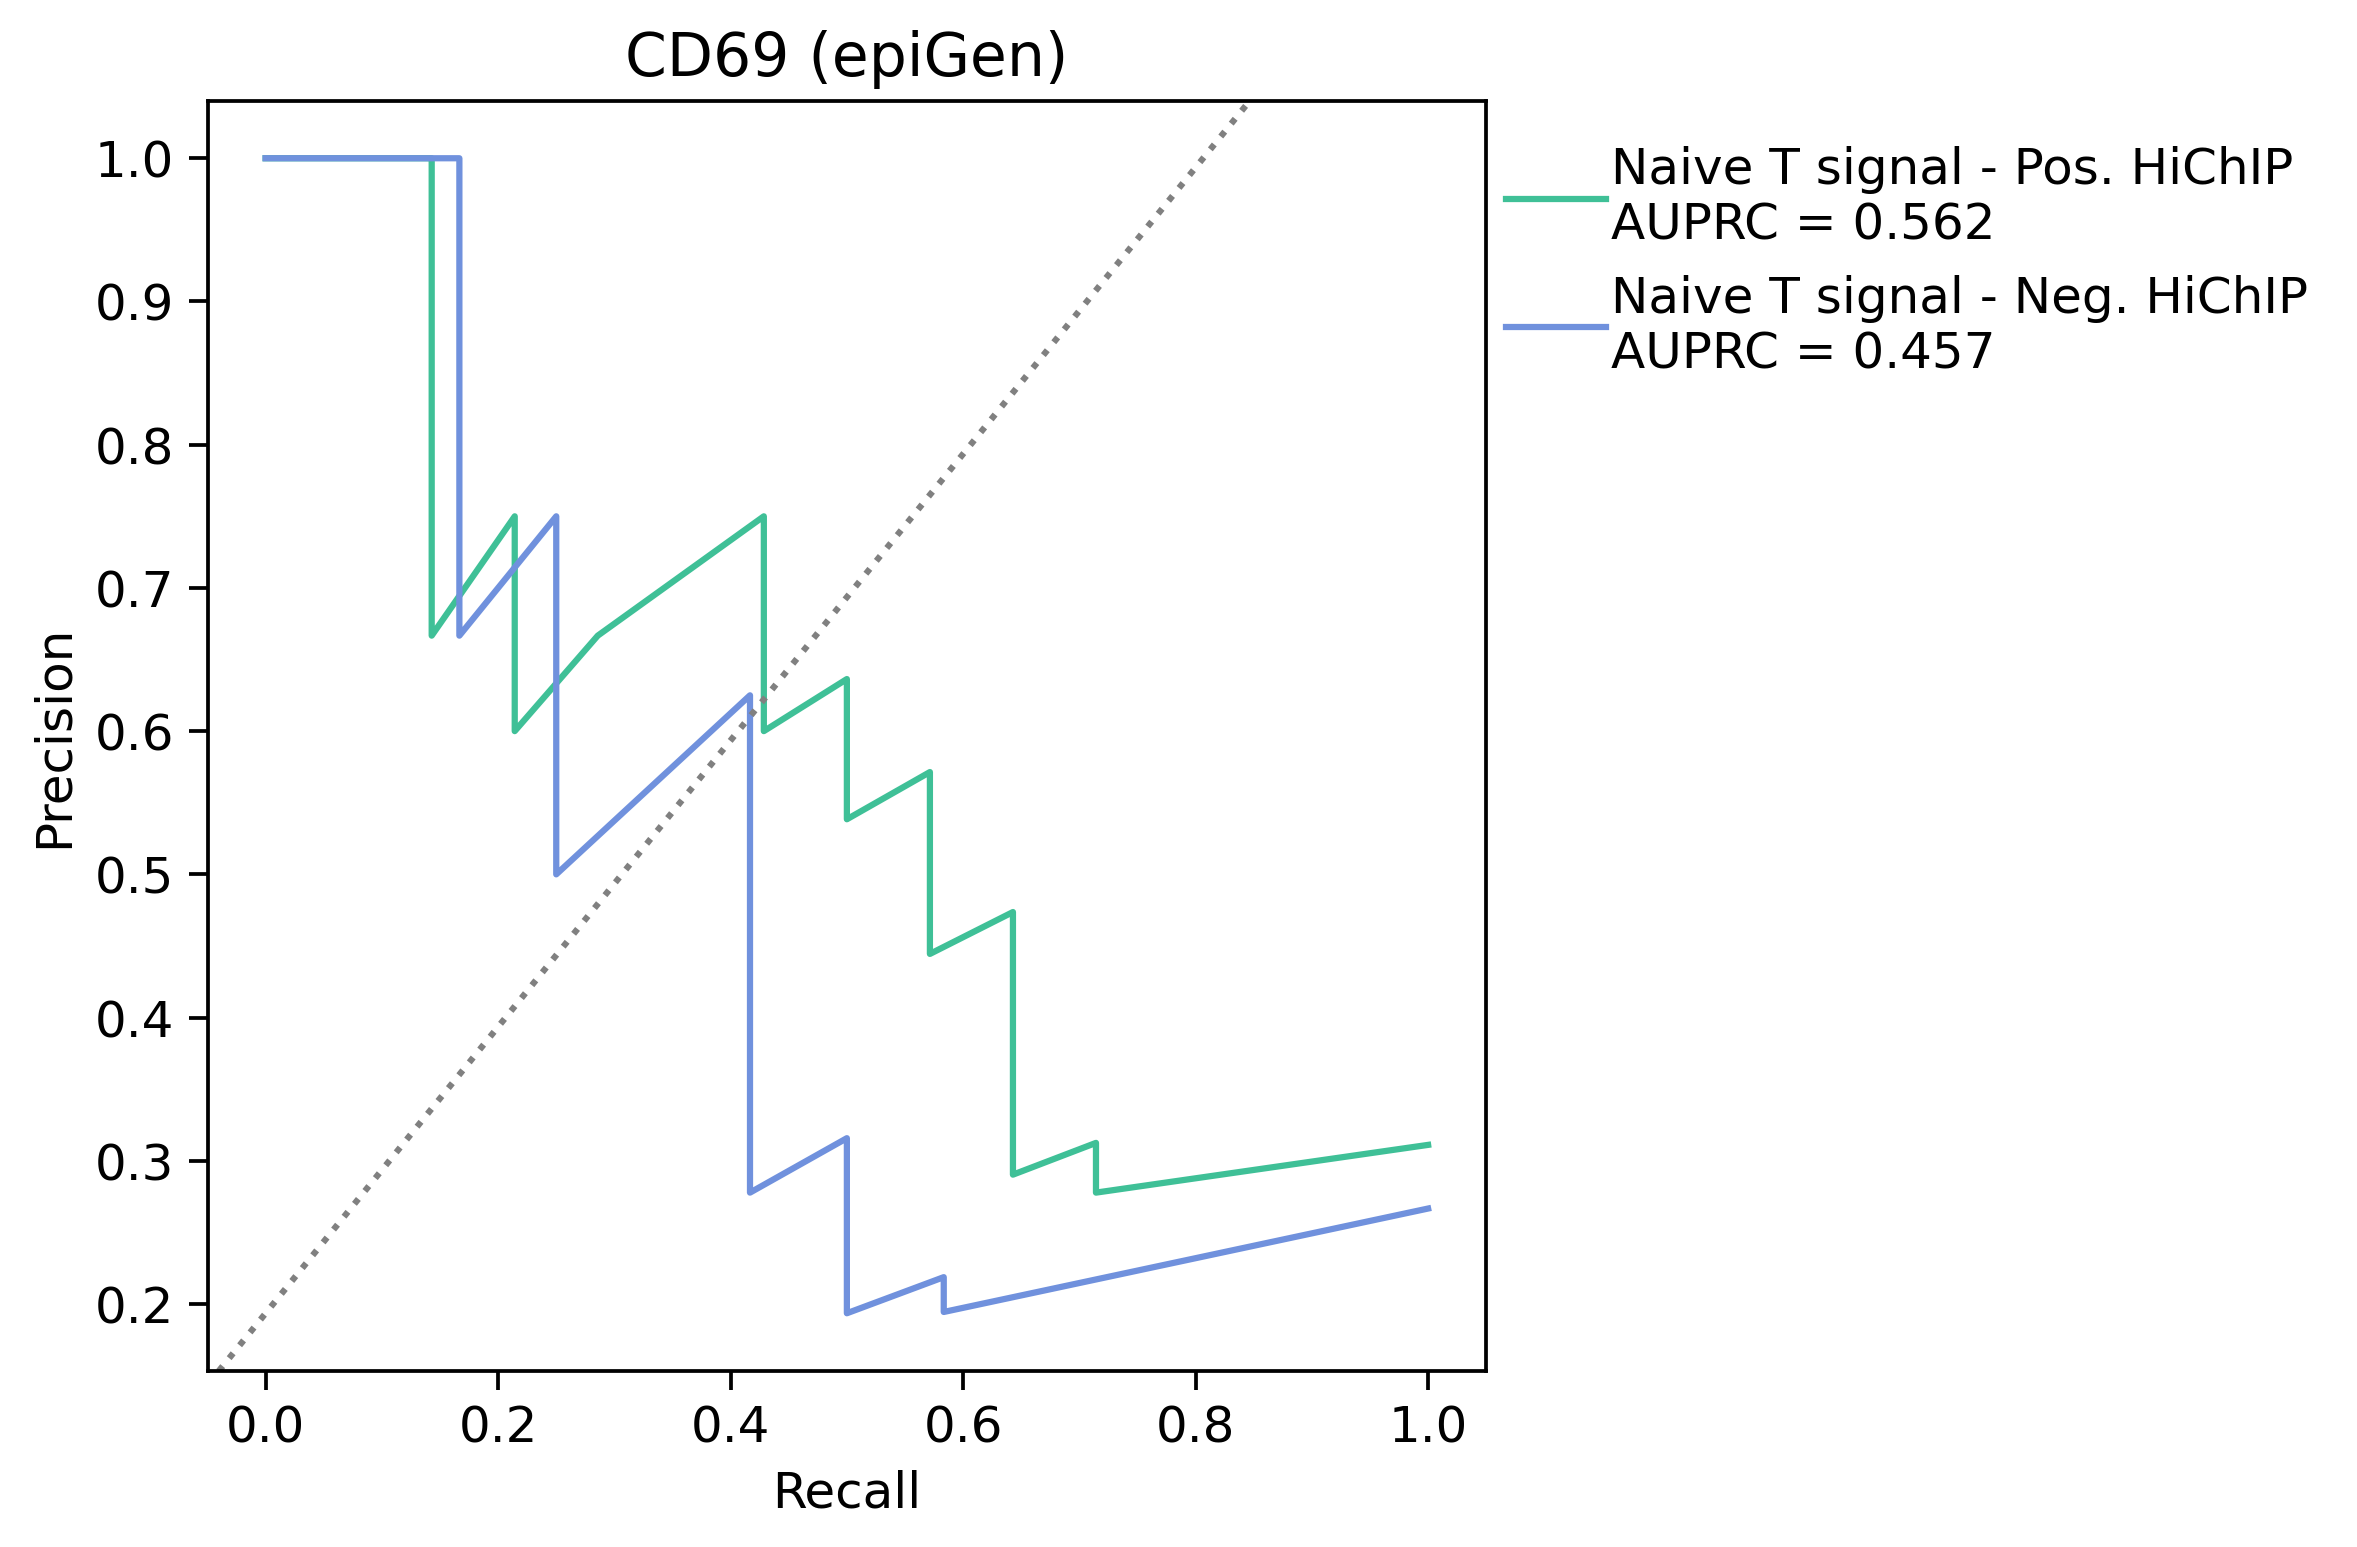

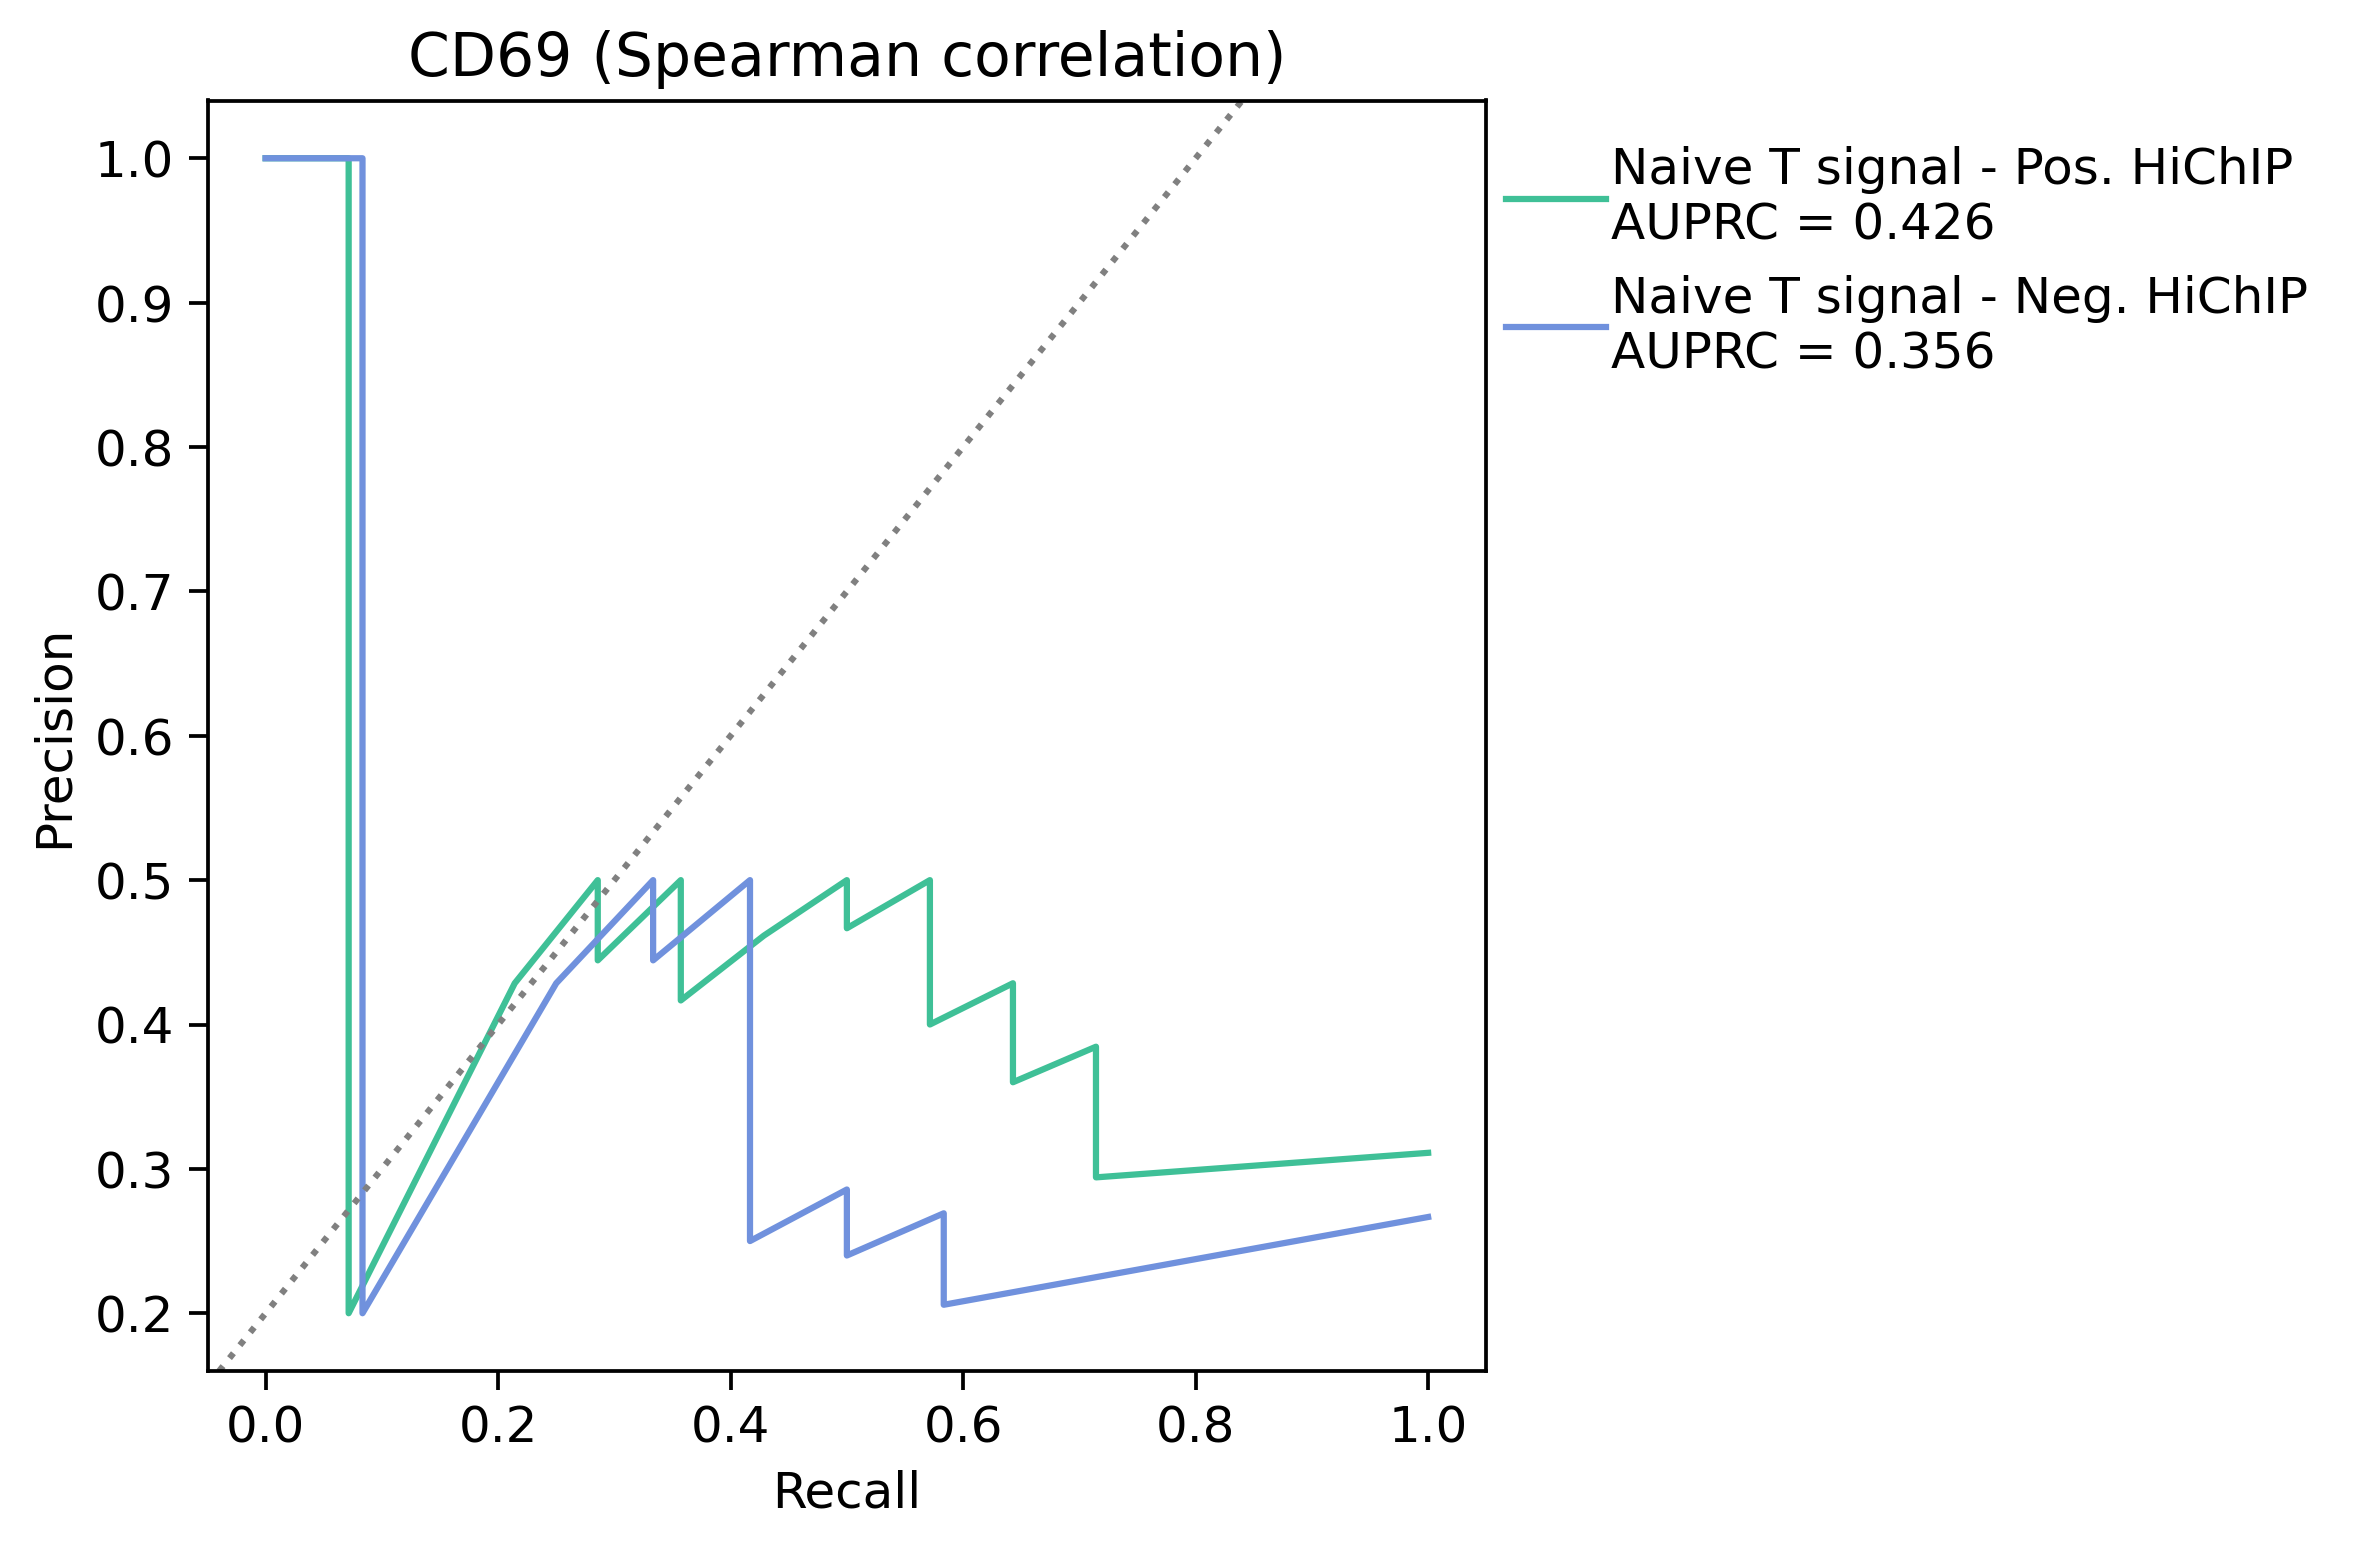

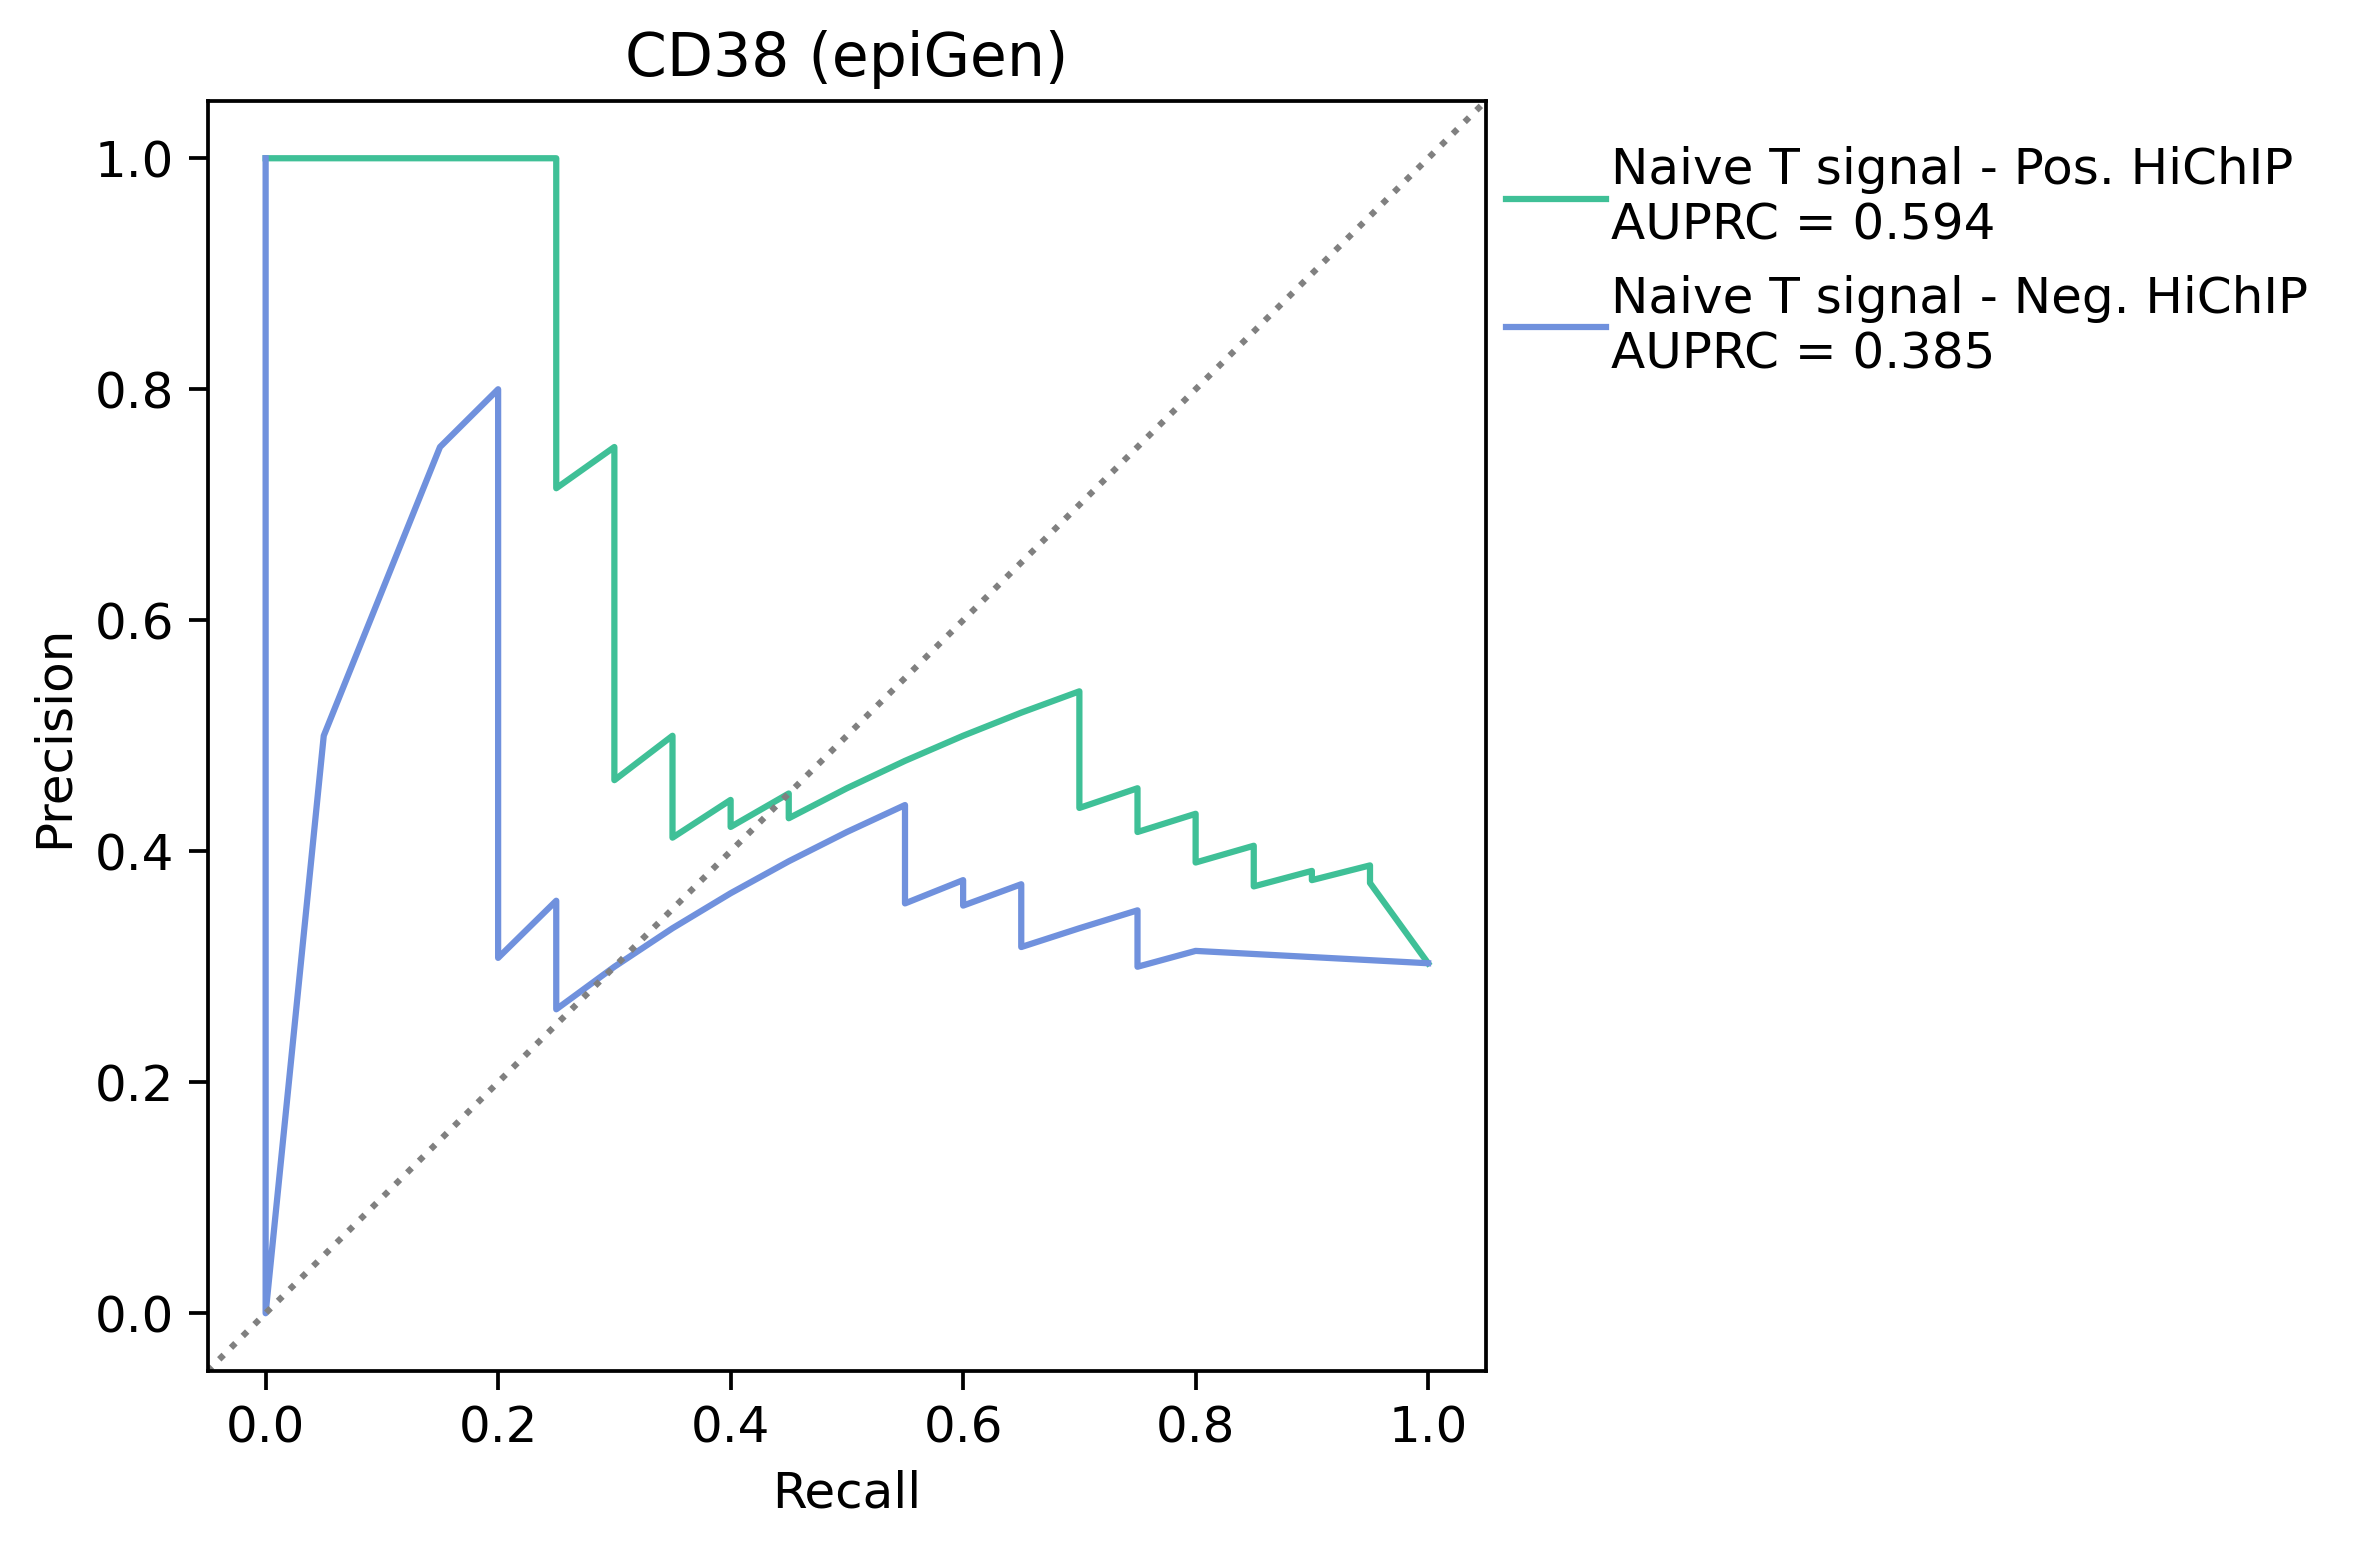

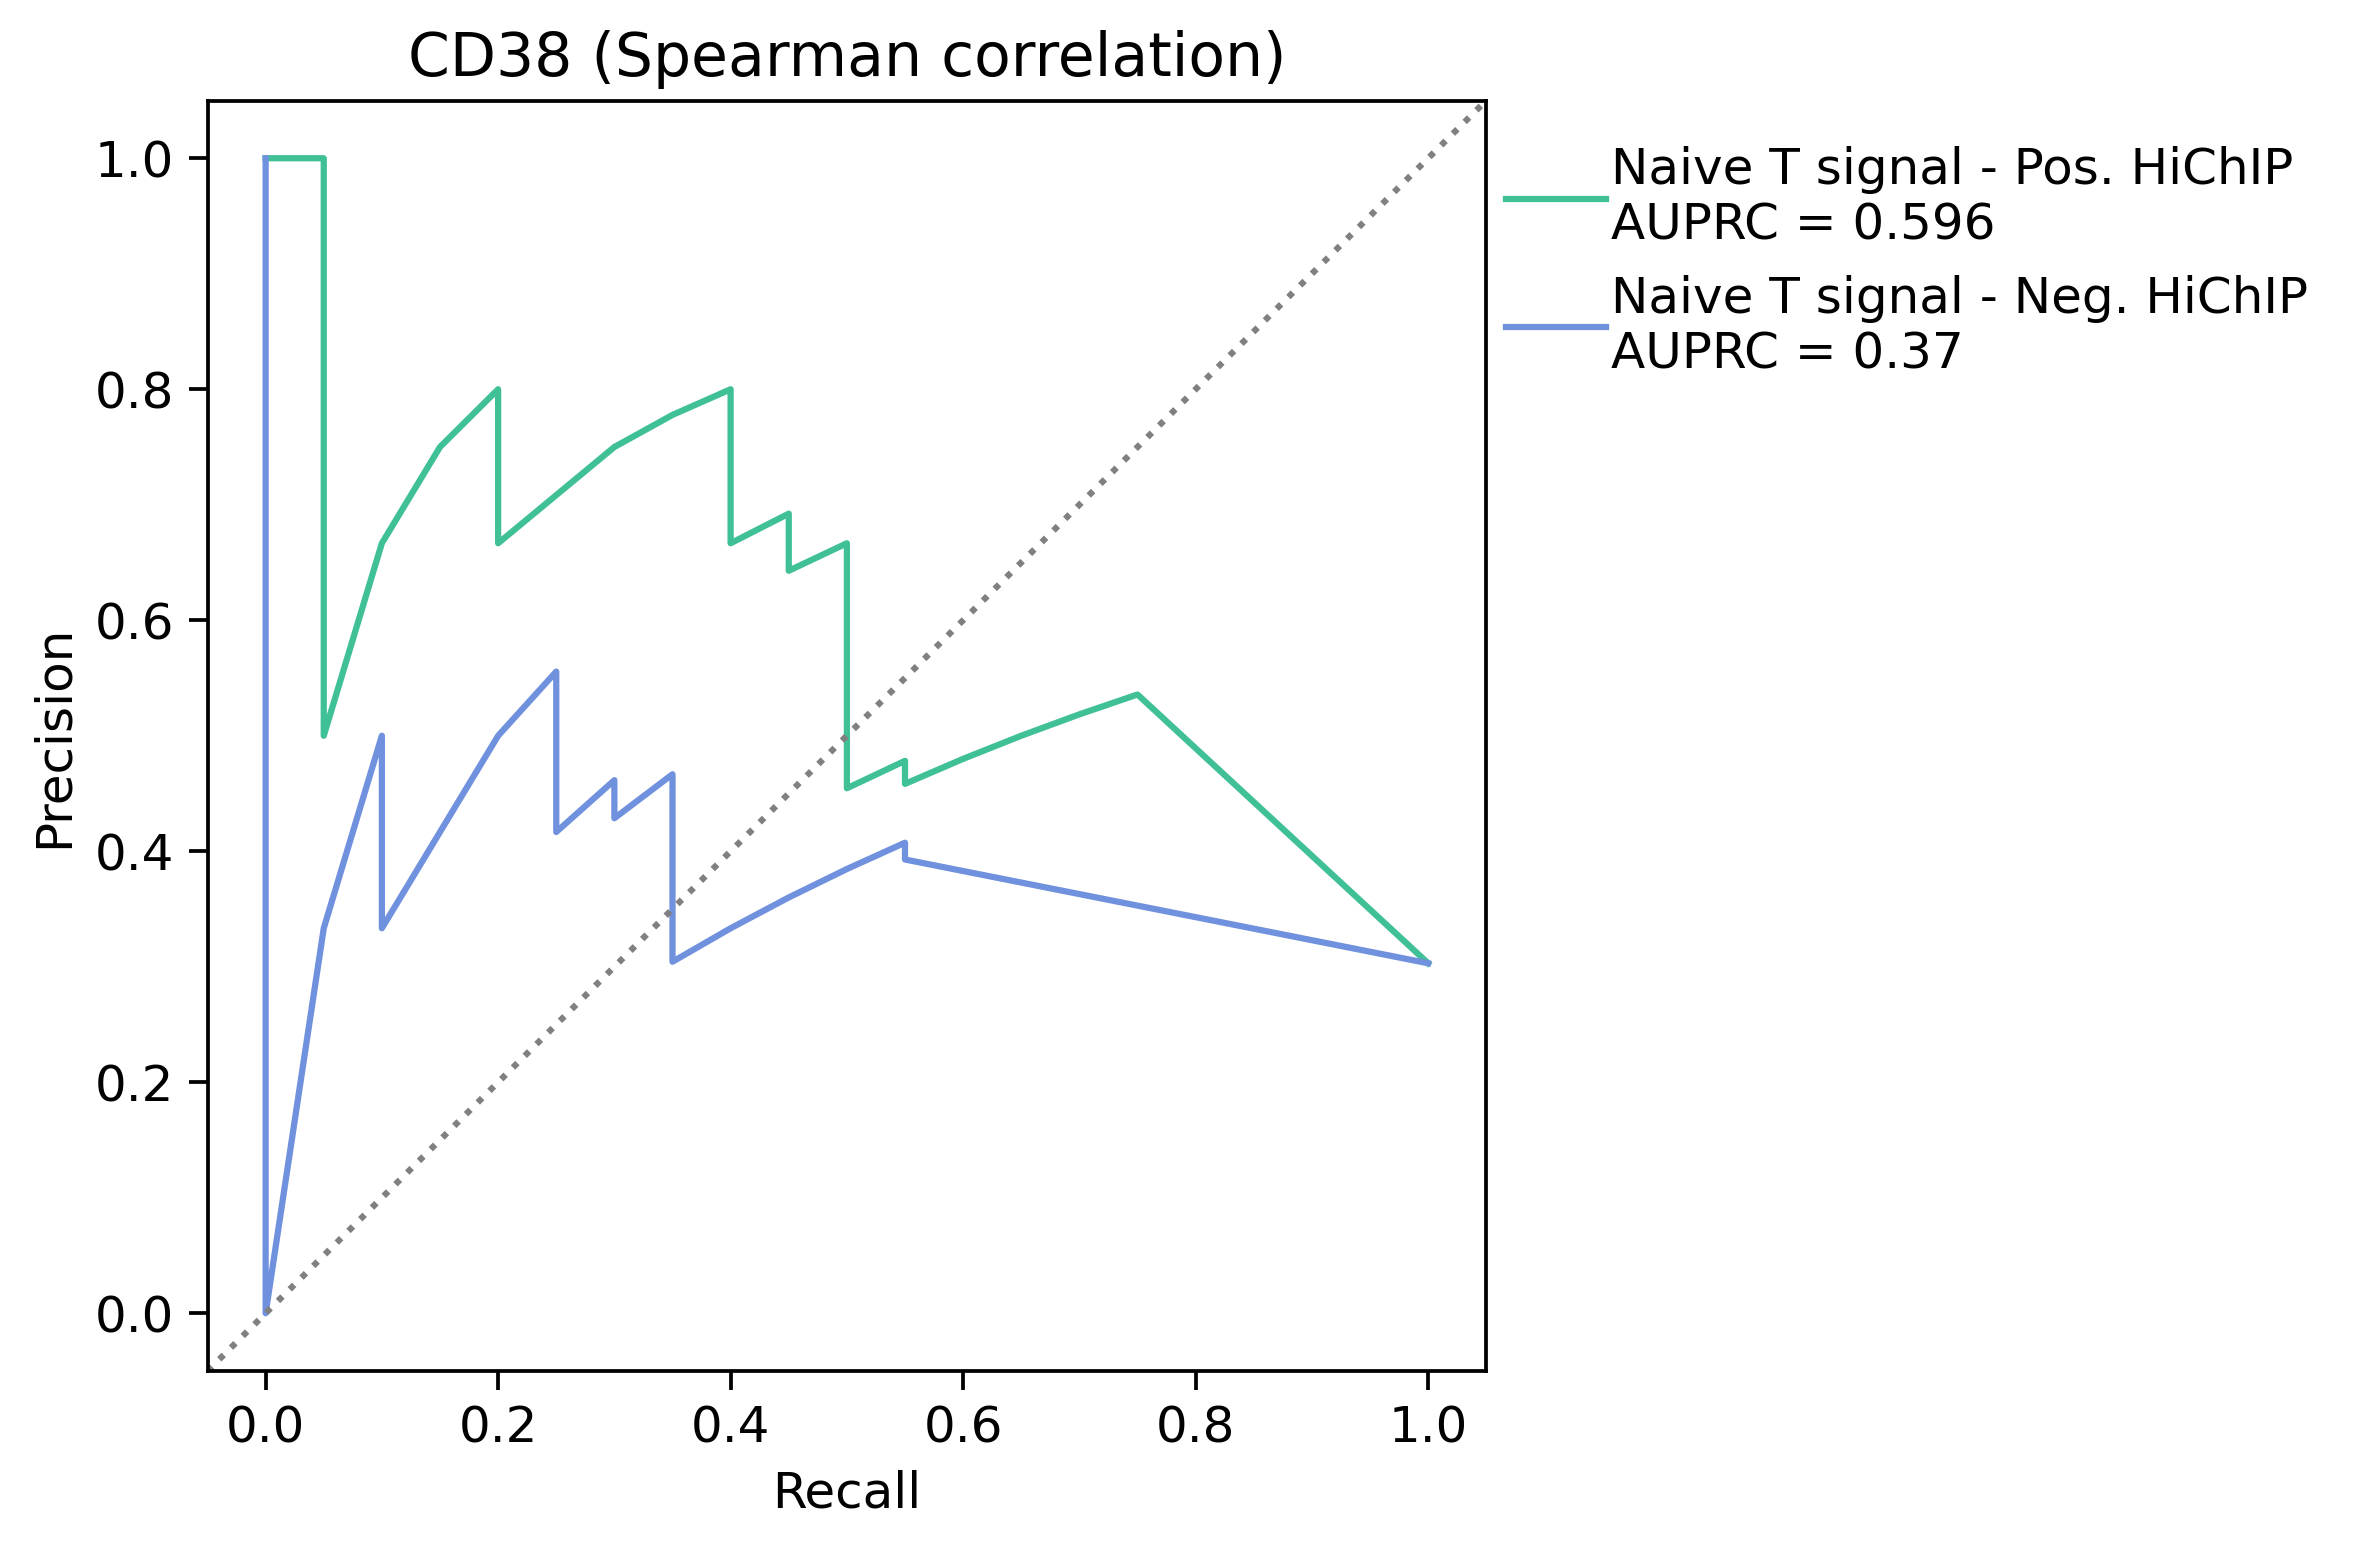

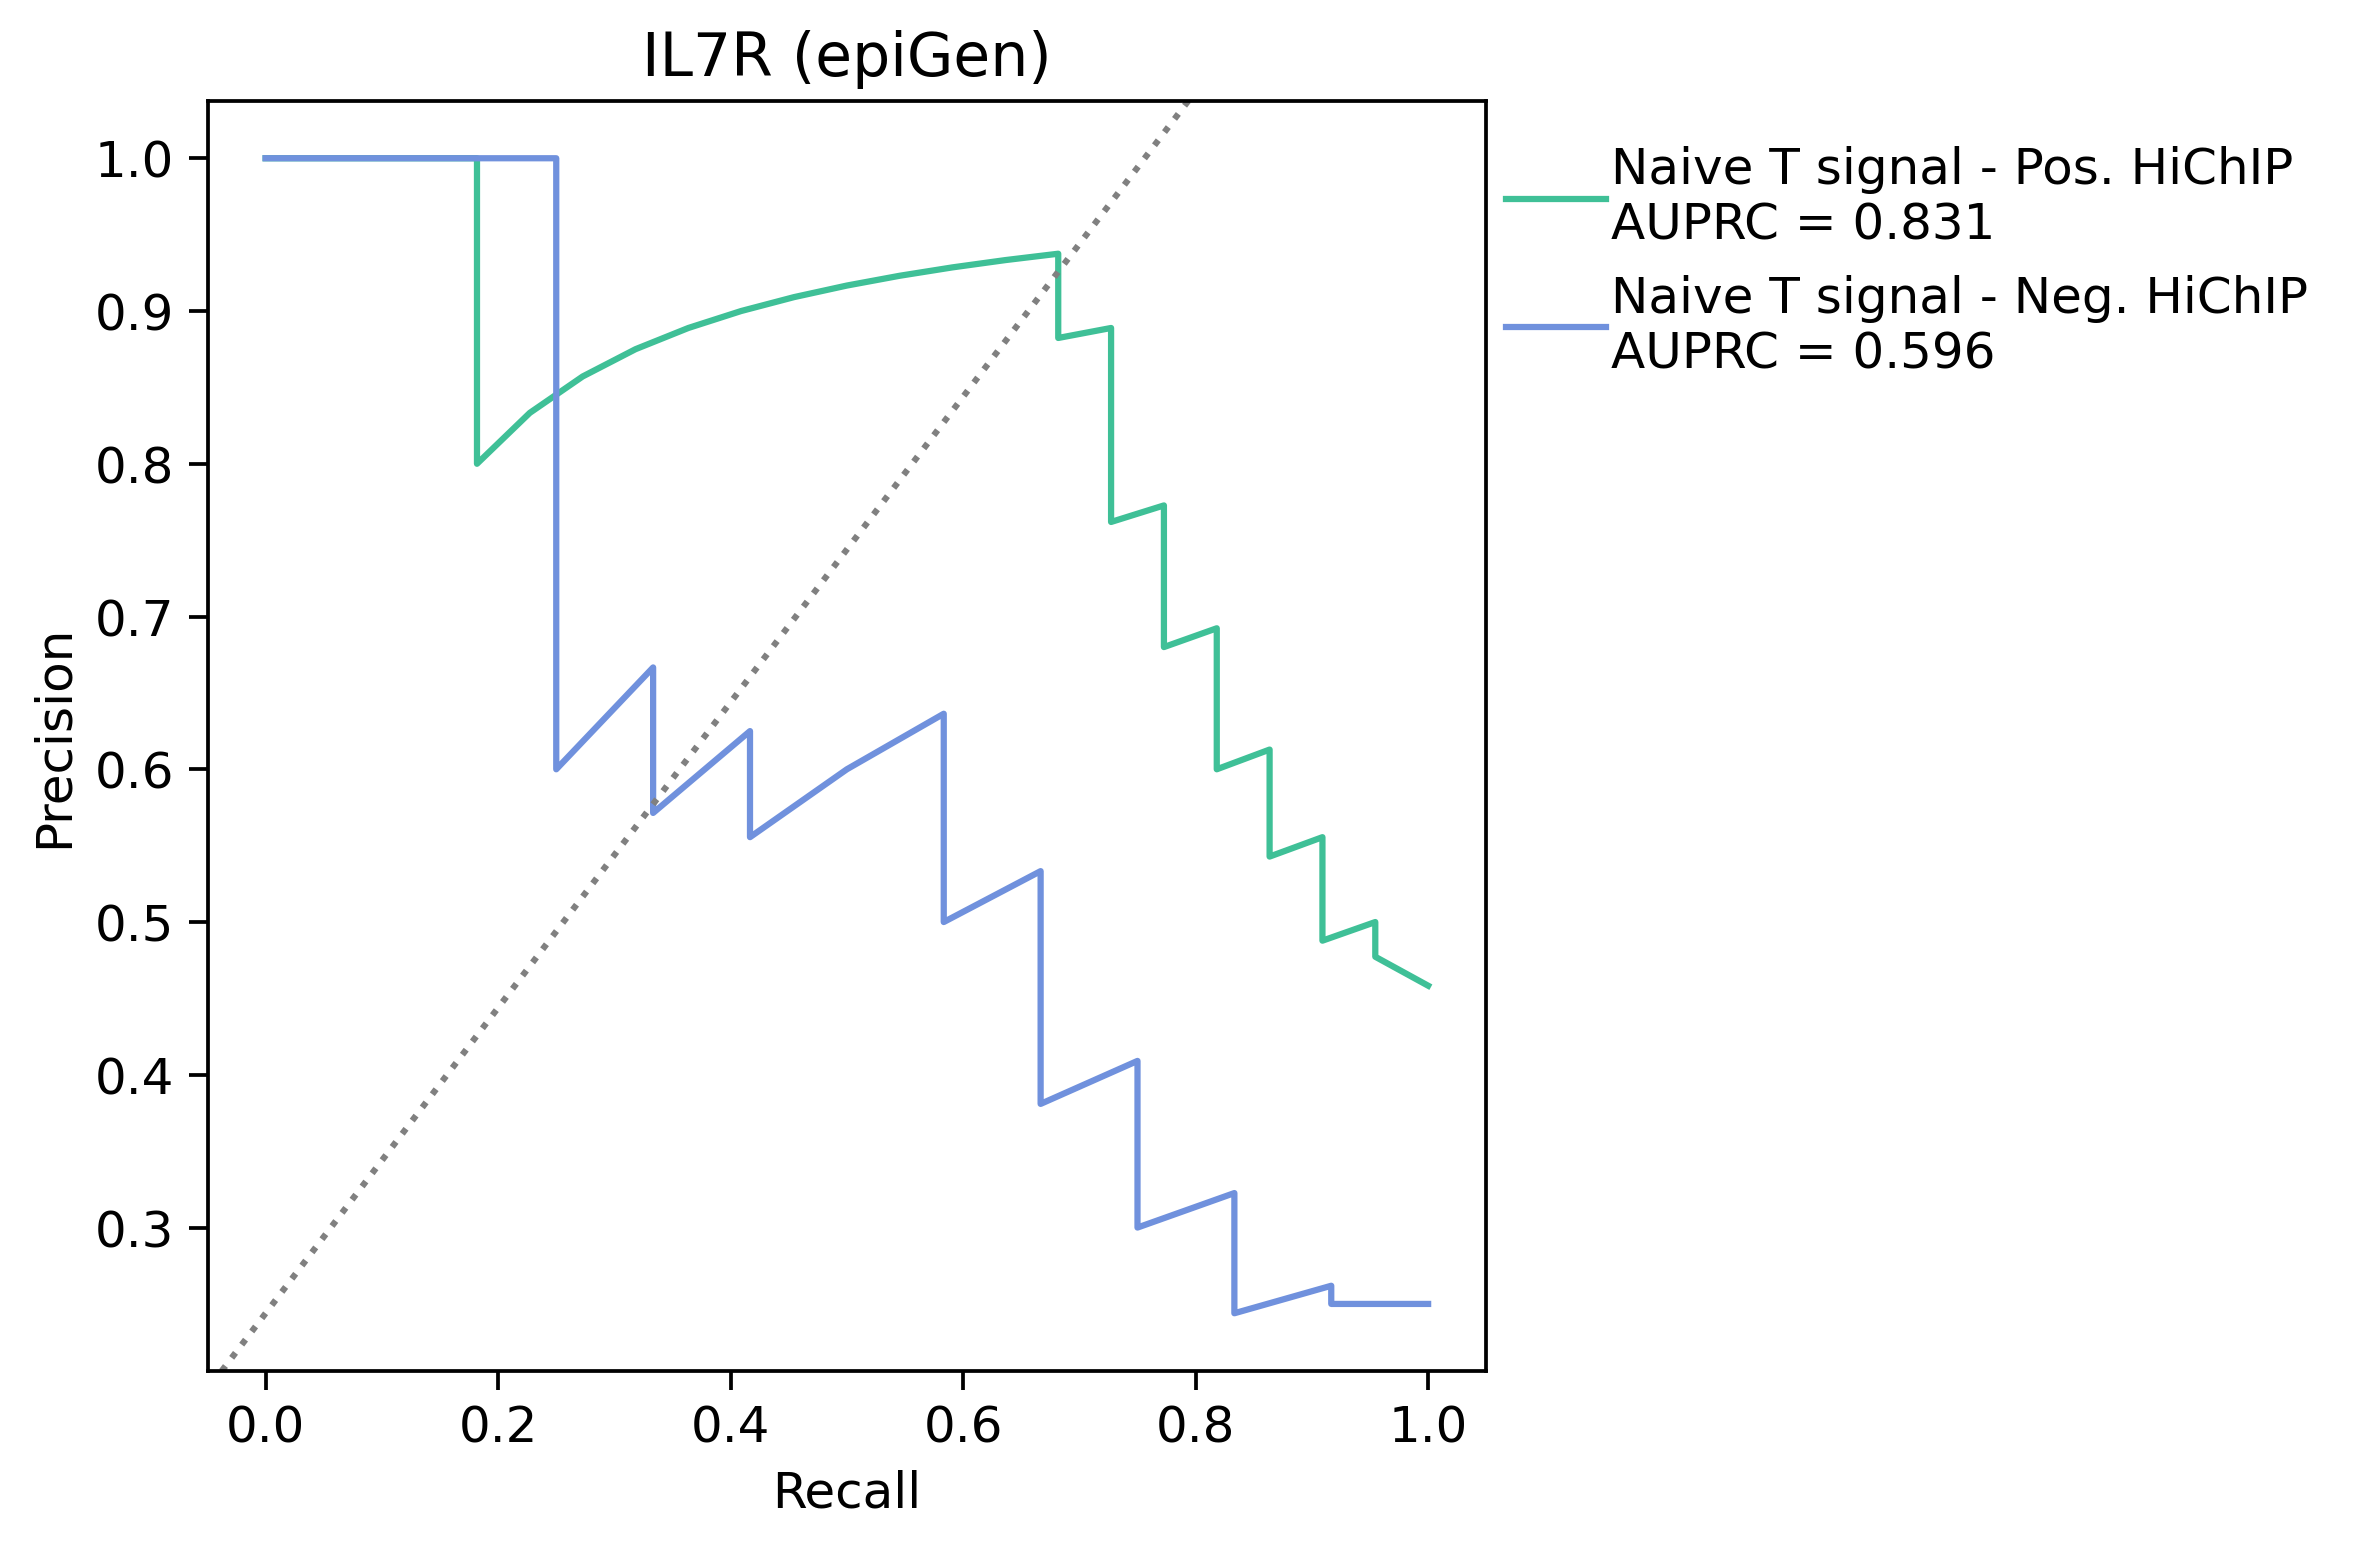

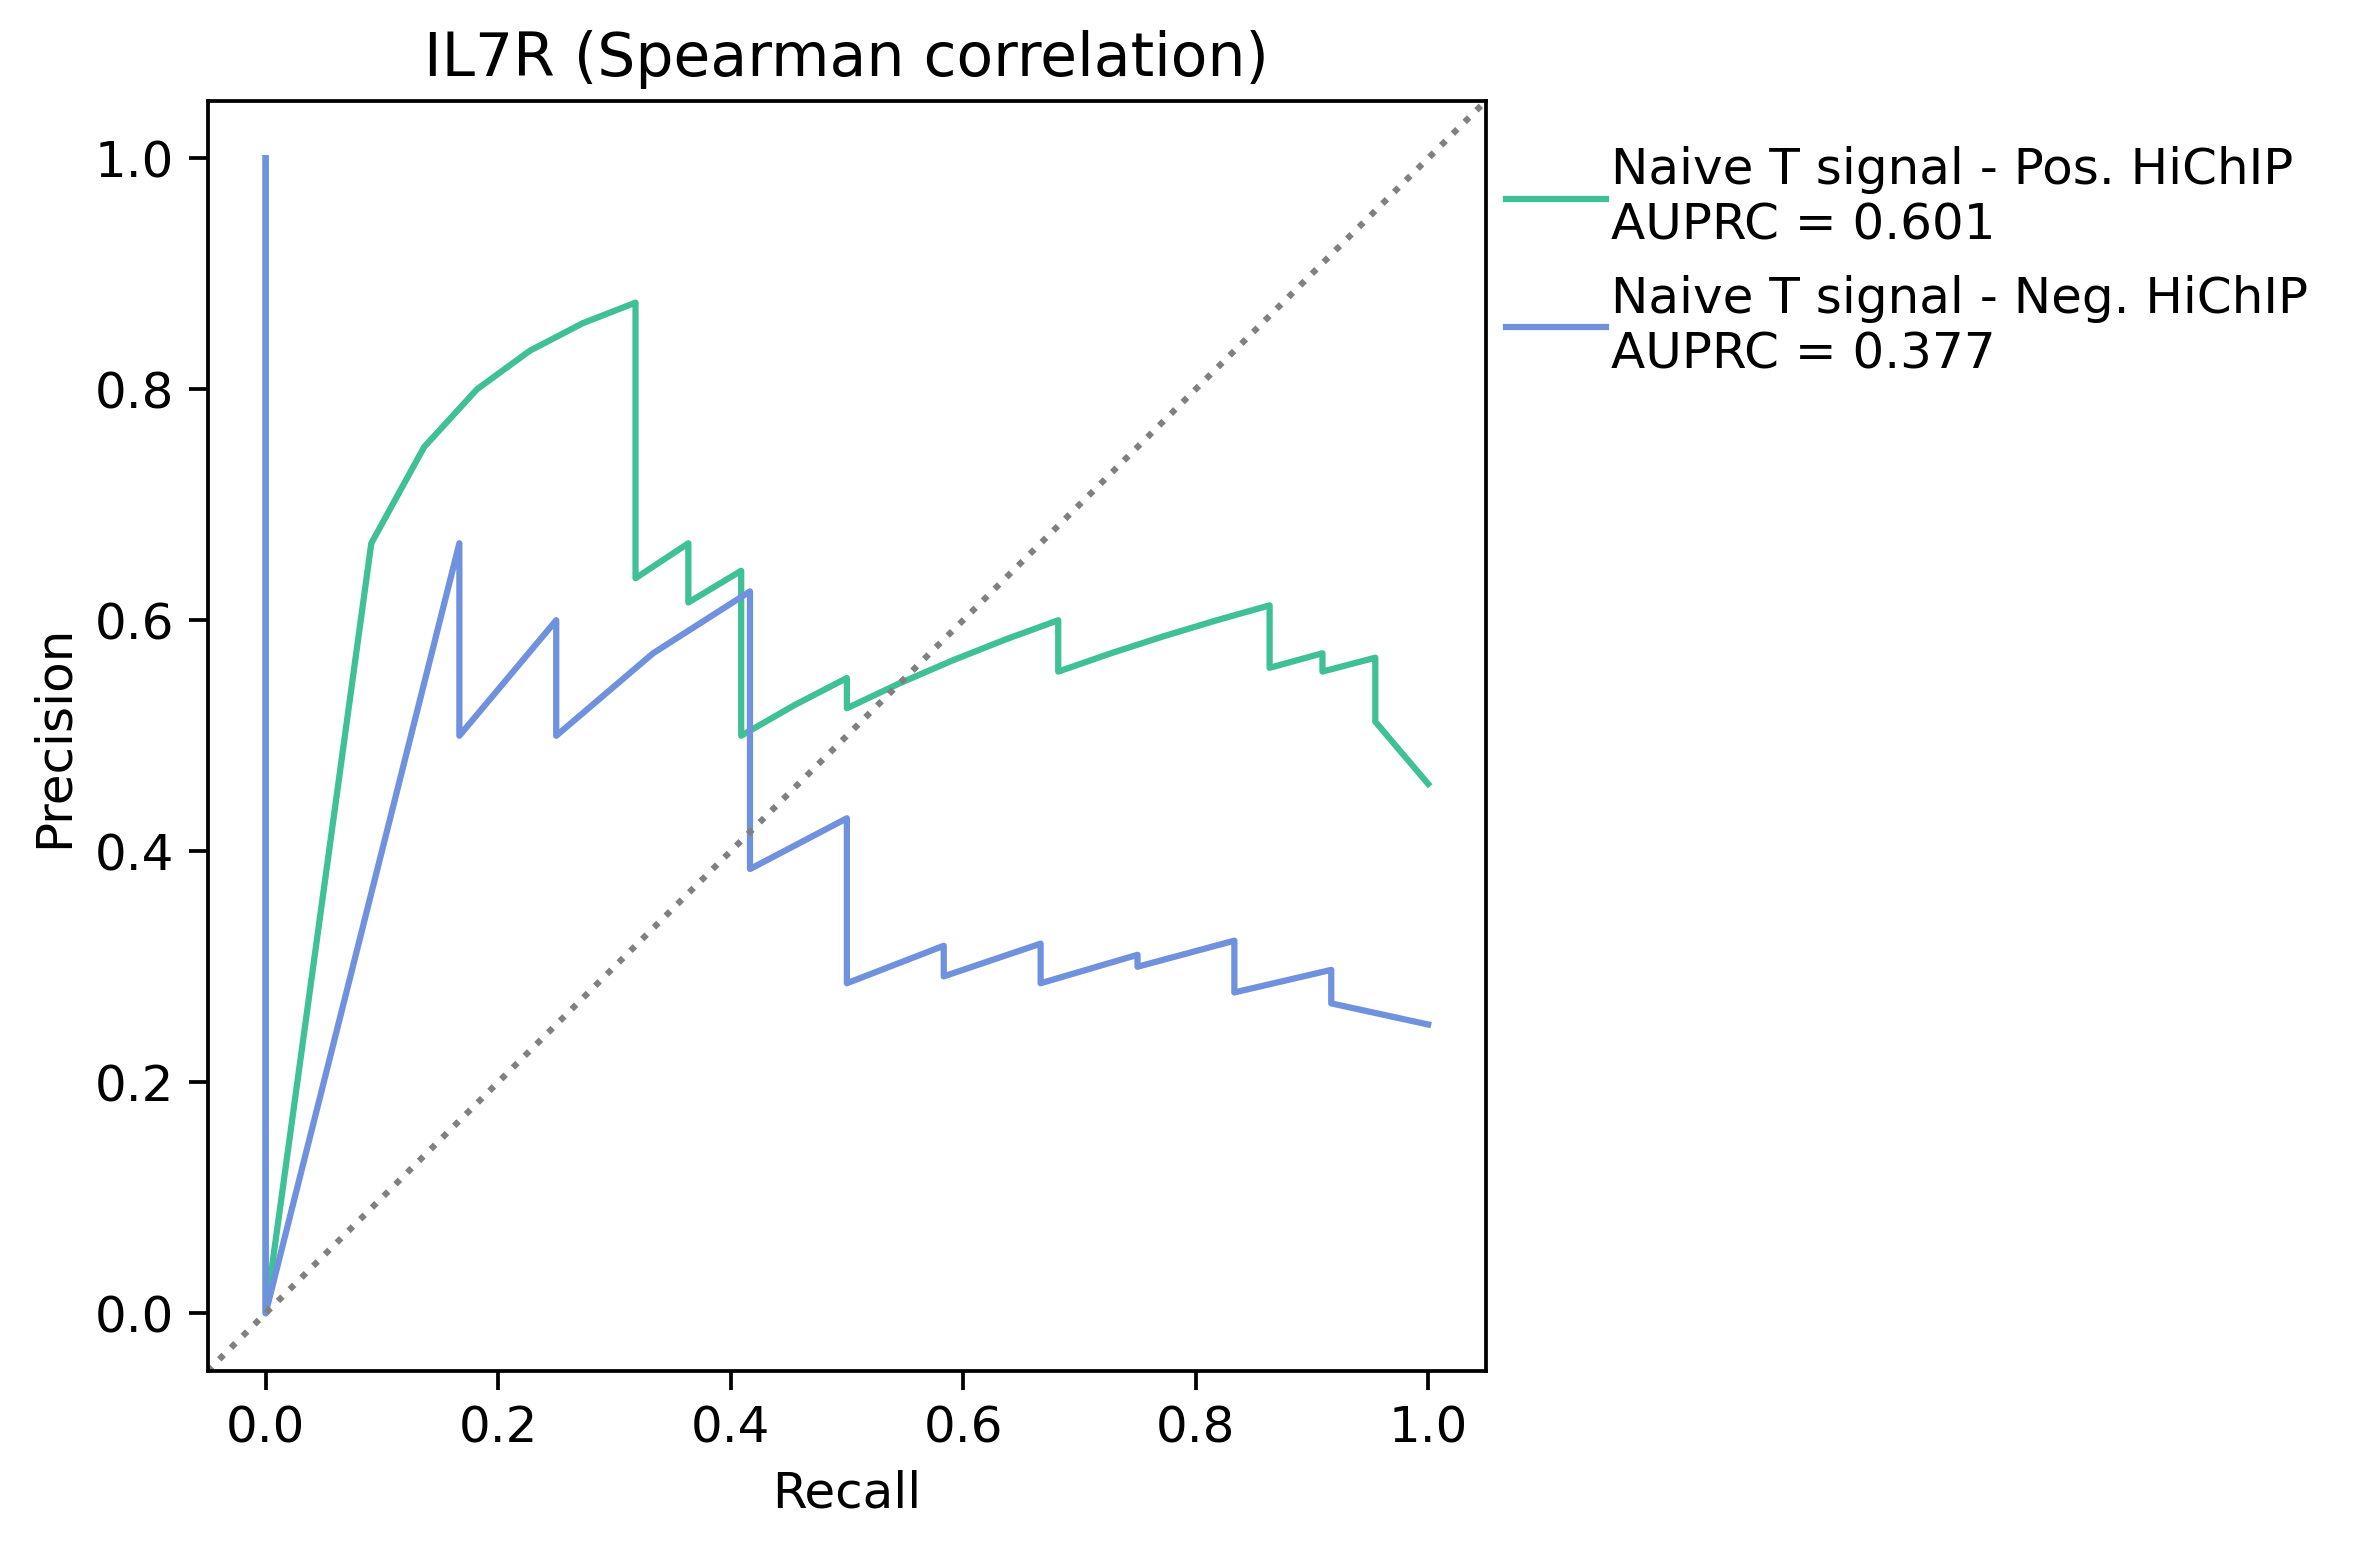

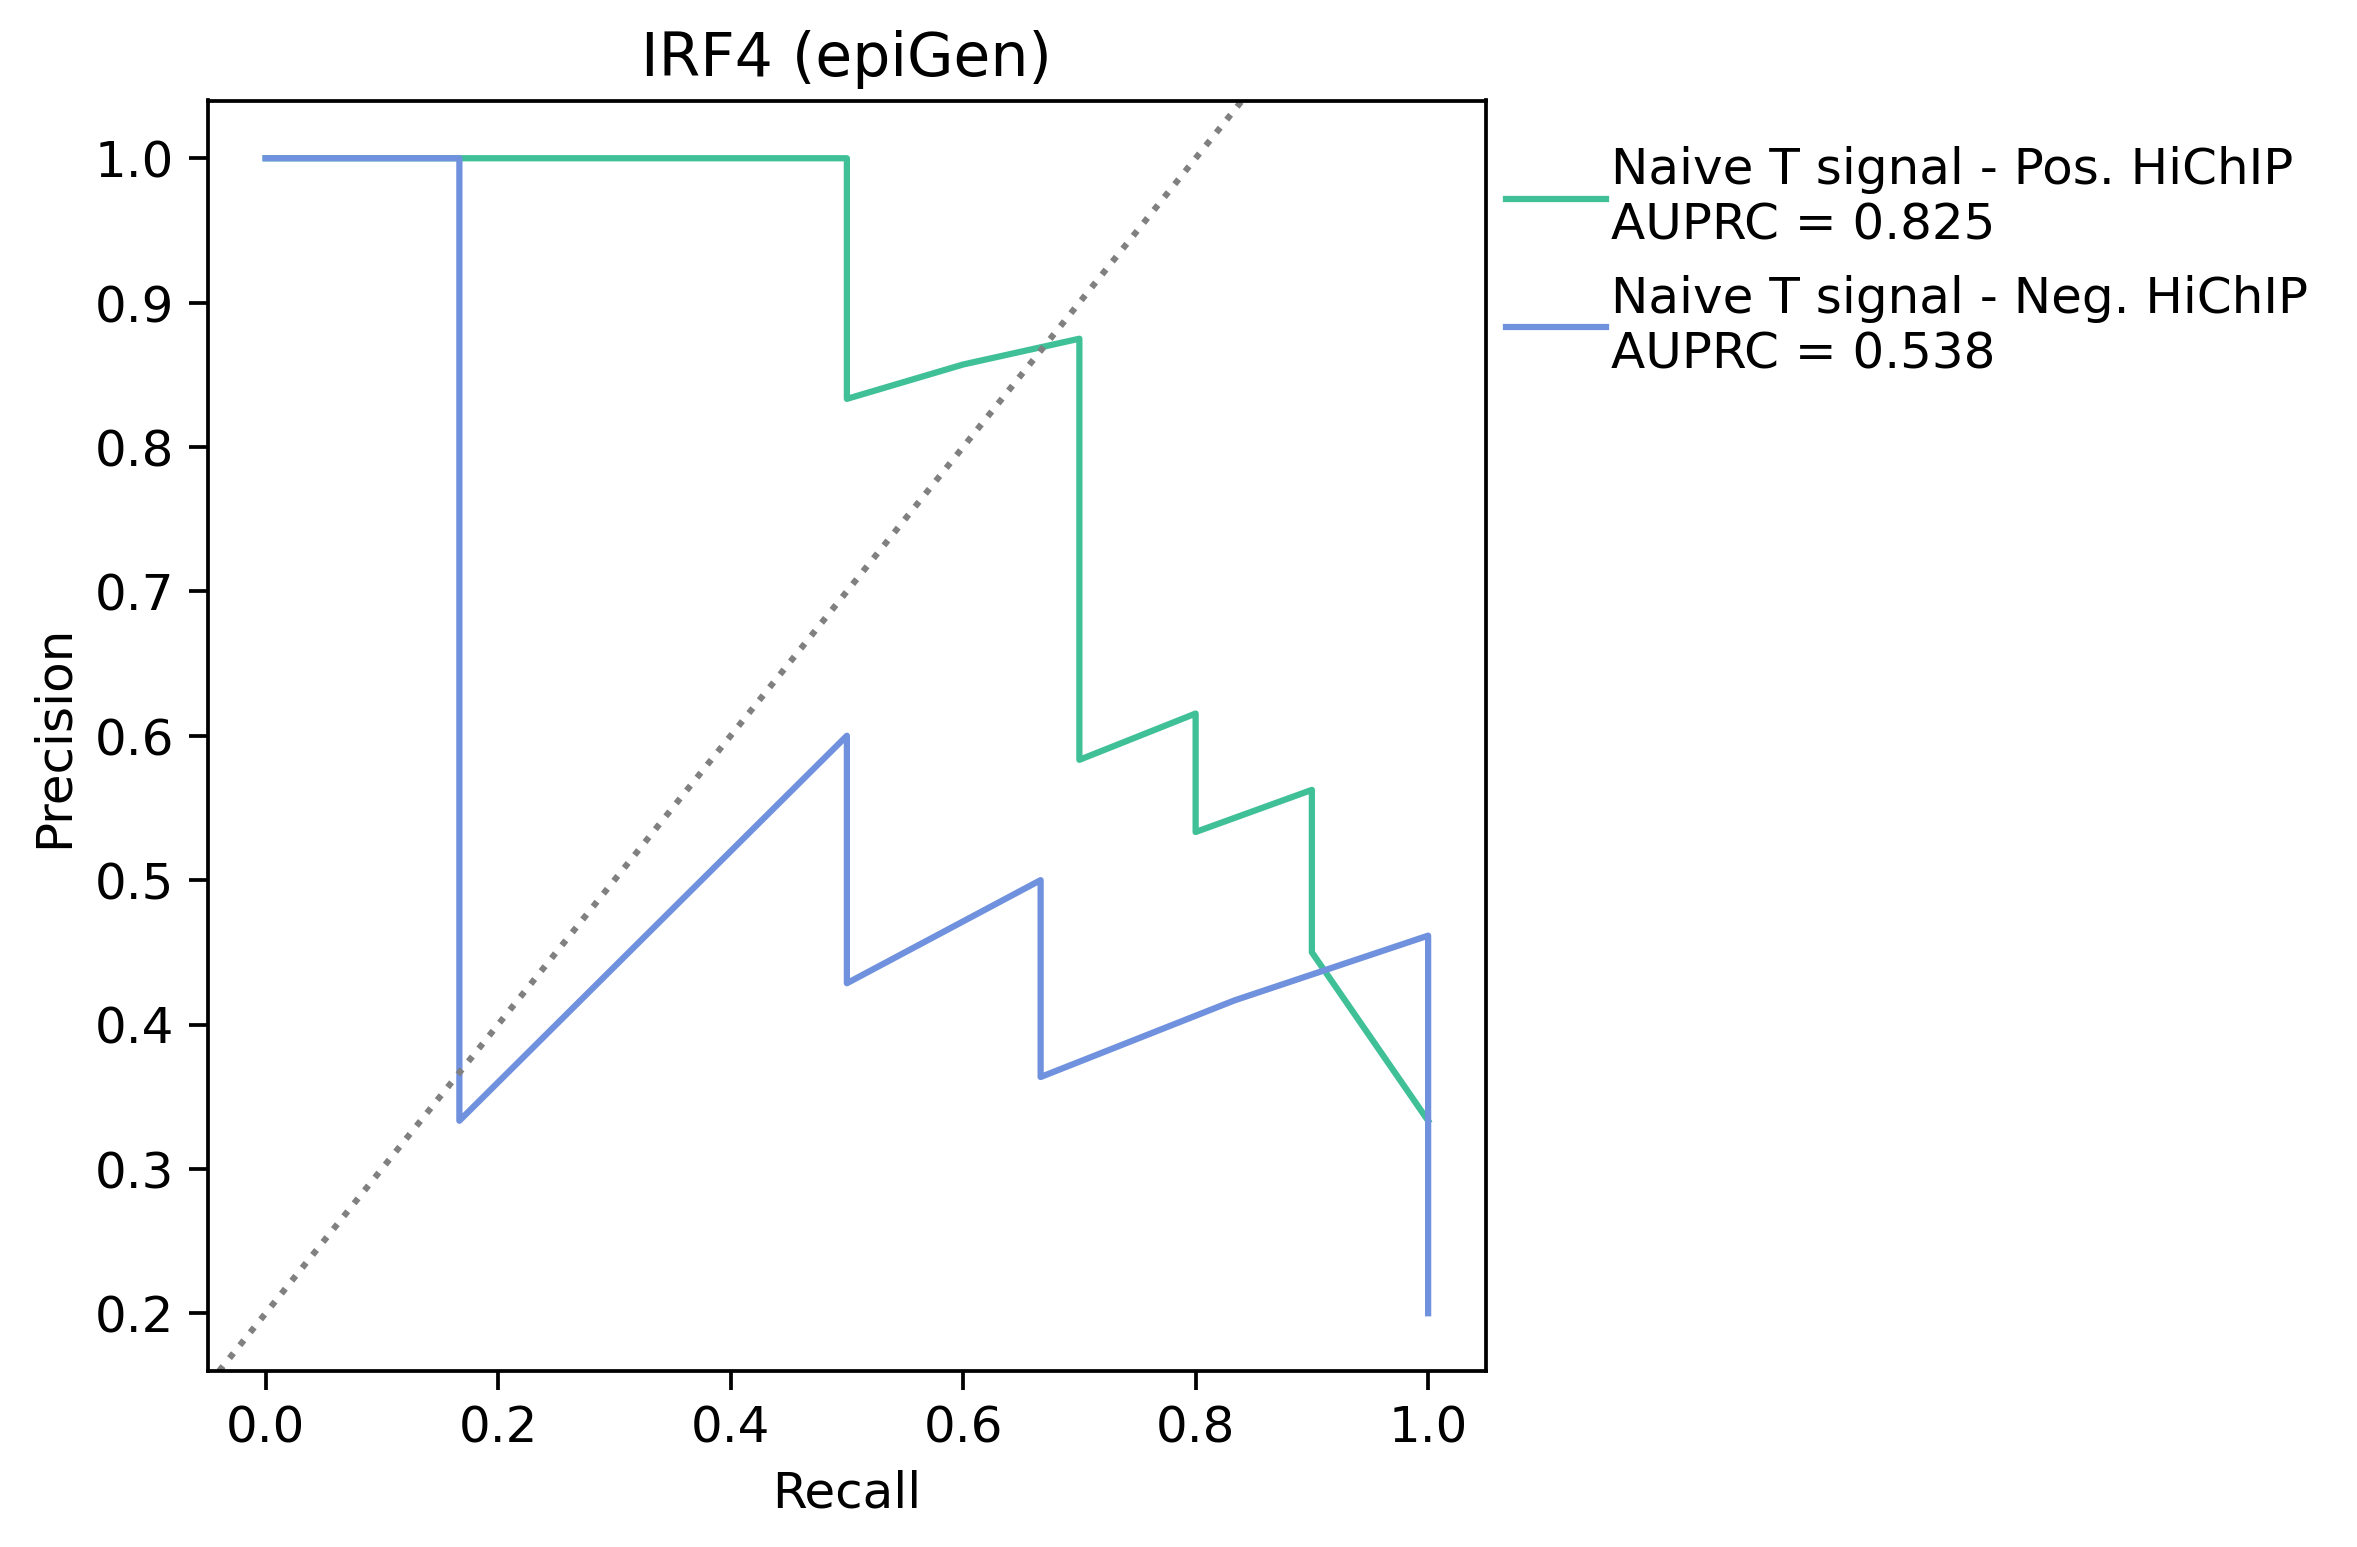

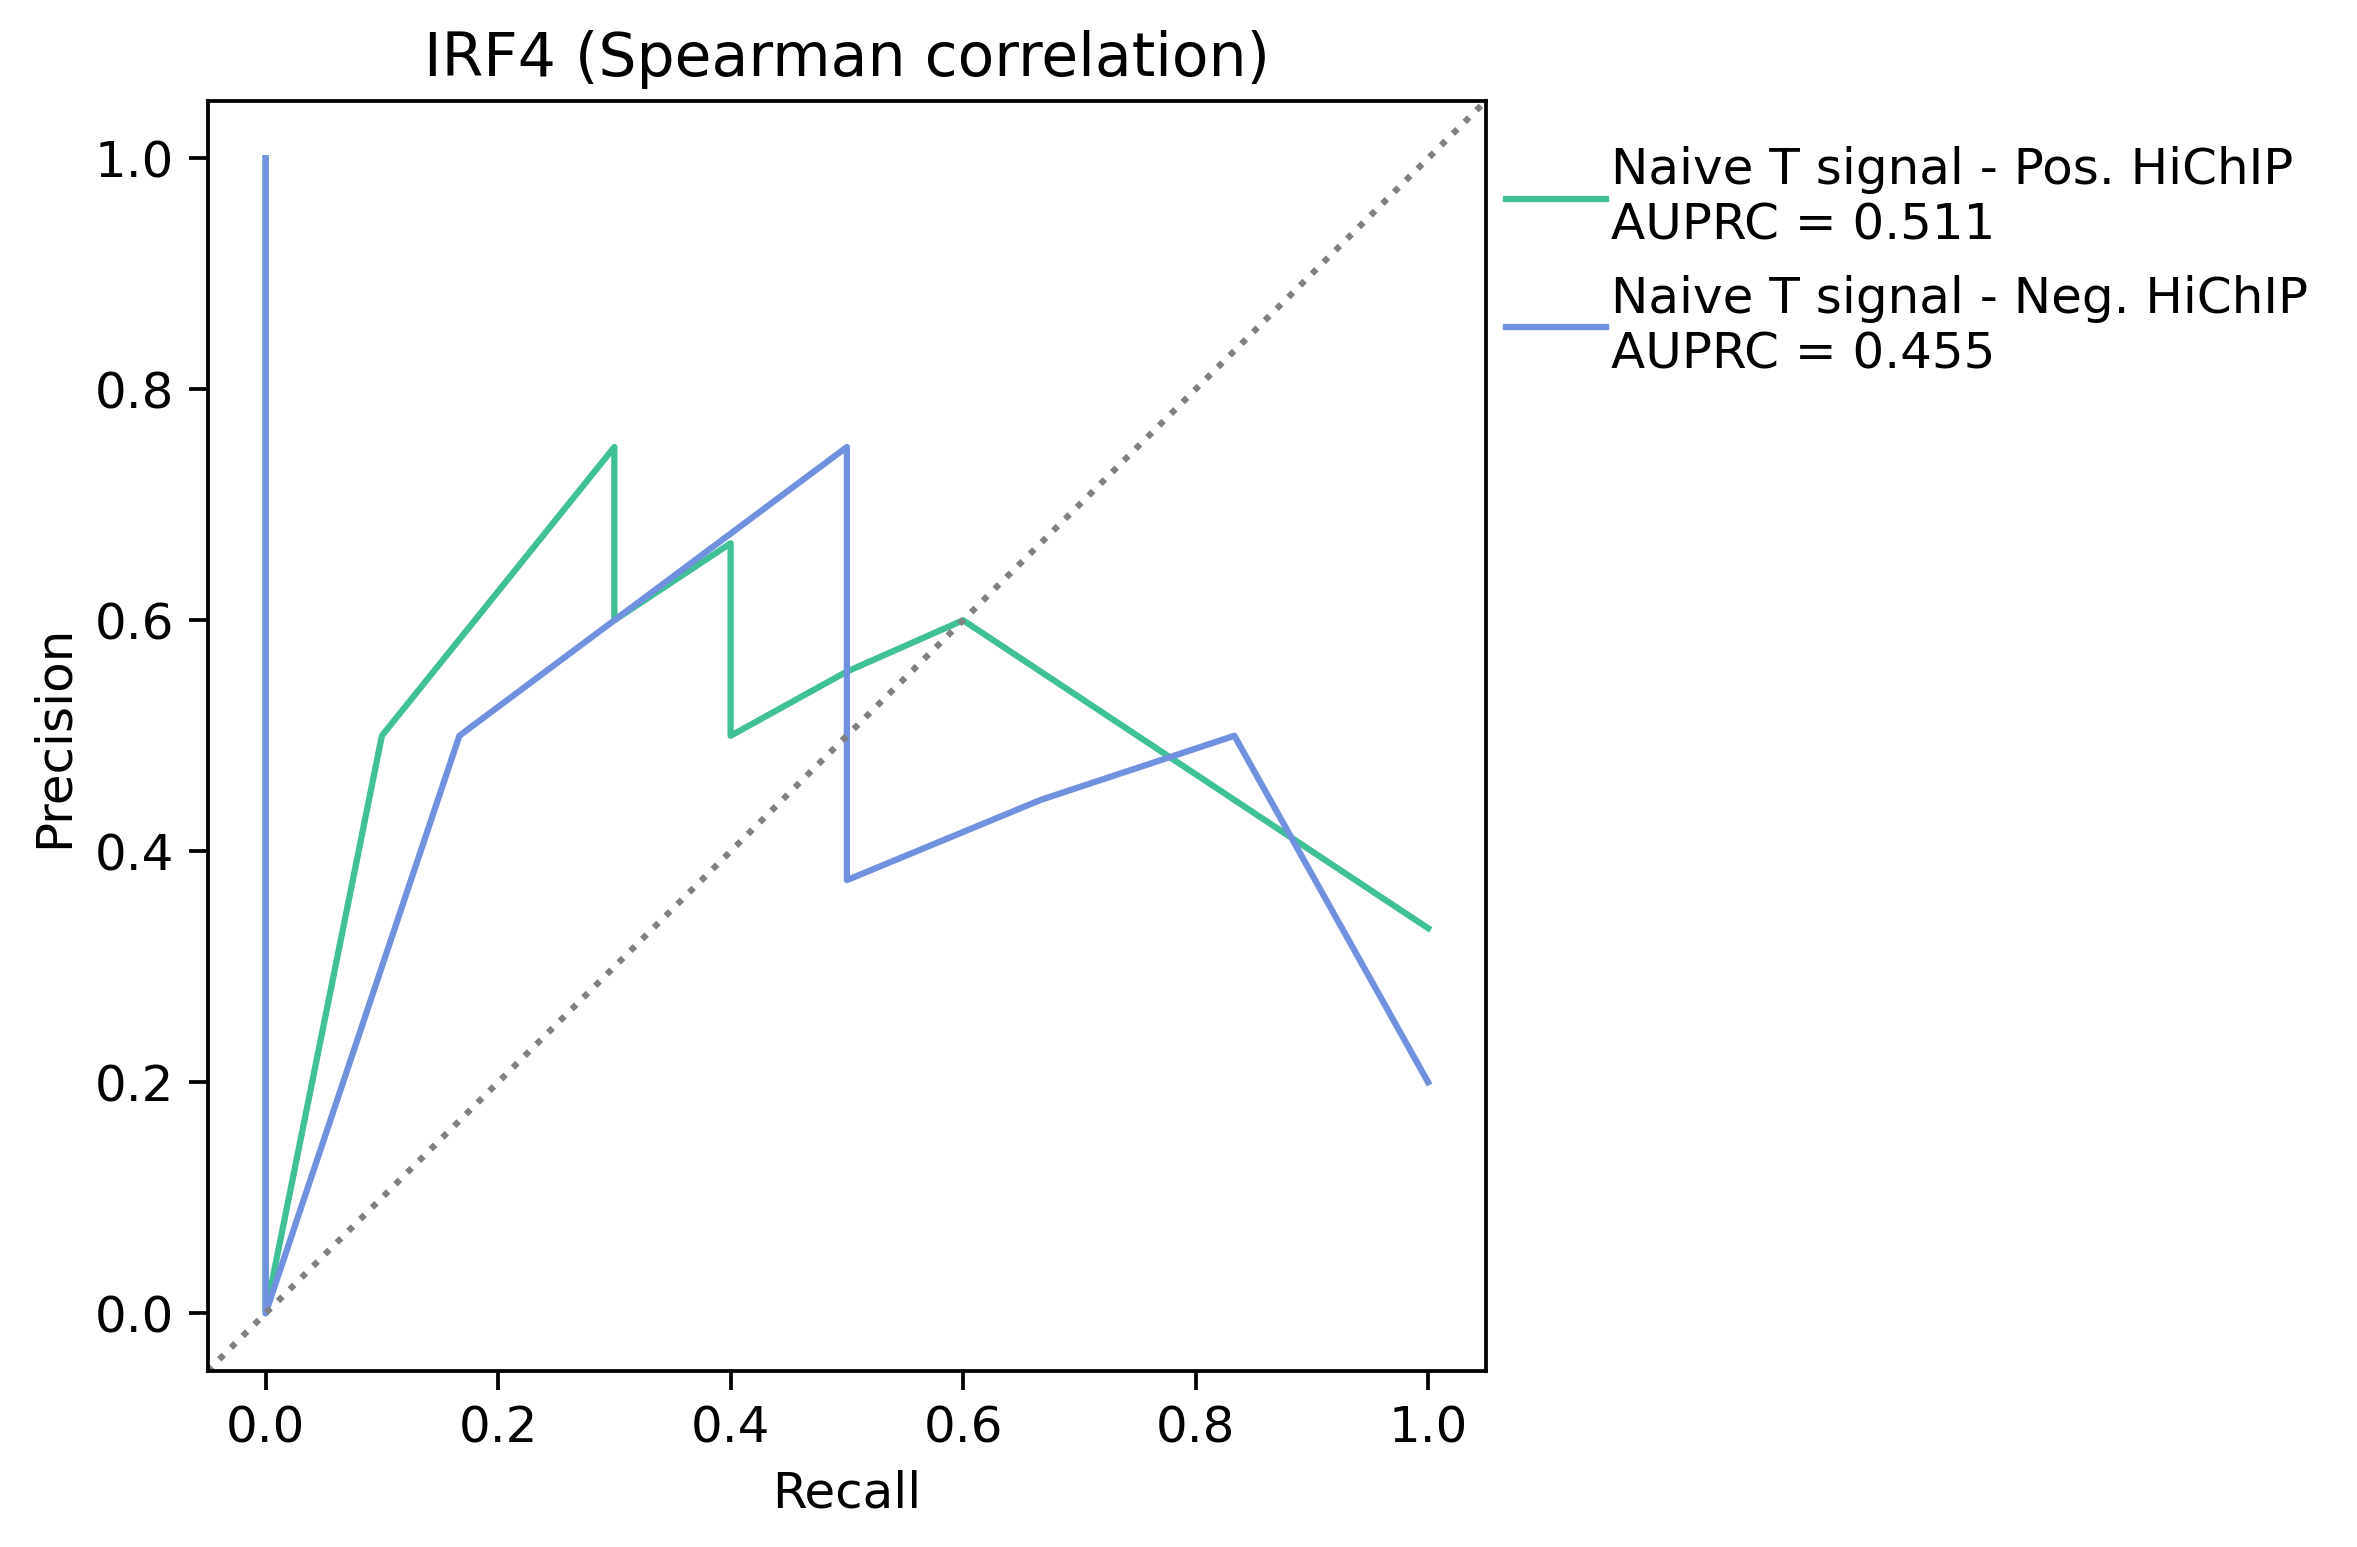

In [ ]:
for gene in ['CD69', 'CD38', 'IL7R', 'IRF4']:
    corr_df = pd.read_csv(outdir + f'{gene}_hg38_baseline_correlation.csv')
    dgd_df = pd.read_csv(outdir + f'{gene}_hg38_hichip_epiGen_aligned_locations.csv')
    dgd_df = pd.concat([dgd_df, corr_df])
    dgd_df['gene_name'] = gene

    plot_roc(dgd_df[dgd_df.method != 'Spearman'])
    plt.title(f'{gene} (epiGen)')
    plt.savefig(figdir + f'{gene}_PRC_epiGen.pdf')
    plt.show()
    plt.close()

    plot_roc(dgd_df[dgd_df.method != 'epiGen'])
    plt.title(f'{gene} (Spearman correlation)')
    plt.savefig(figdir + f'{gene}_PRC_corr.pdf')
    plt.show()
    plt.close()

“Distal links”示意图

/tmp/ipykernel_2802358/546737409.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


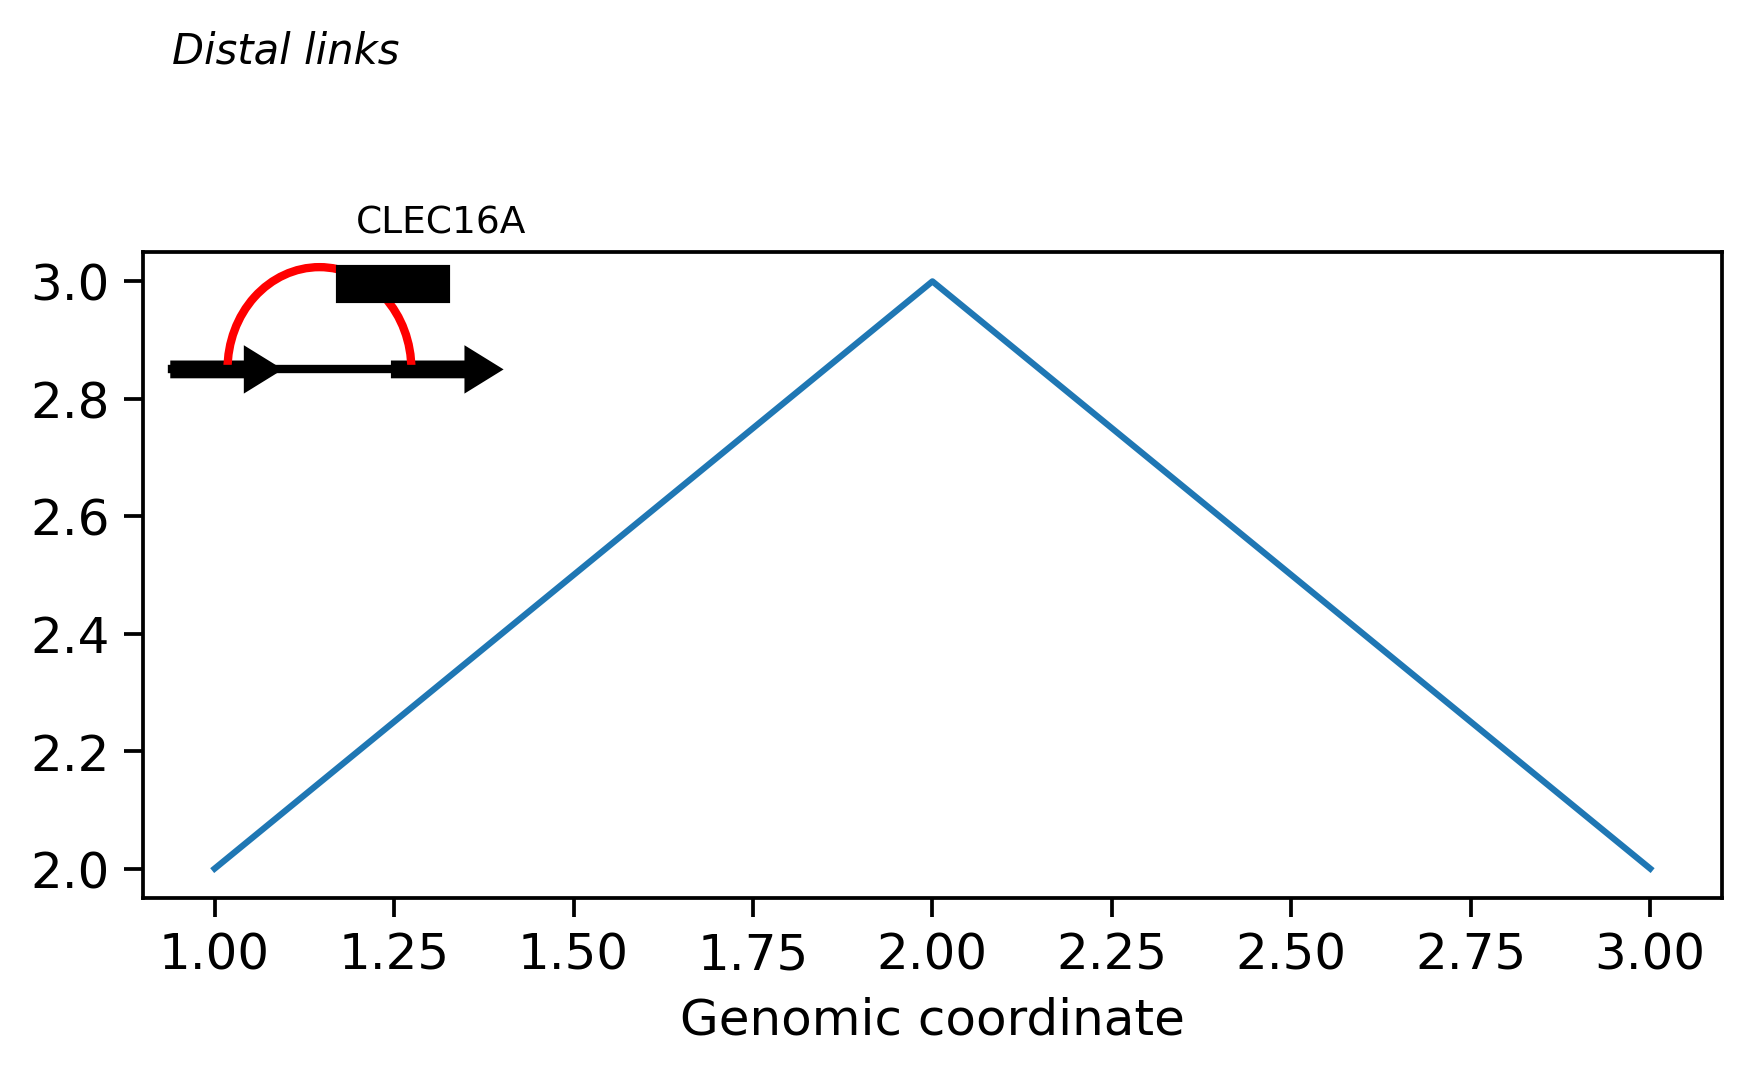

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, Arc, Rectangle

fig, ax = plt.subplots(figsize=(6, 3))

# 主图内容（简略）
ax.plot([1, 2, 3], [2, 3, 2])
ax.set_title('')  # 主图无标题
ax.set_xlabel('Genomic coordinate')

# 添加 inset 小图
inset_ax = fig.add_axes([0.1, 0.78, 0.2, 0.15])  # [left, bottom, width, height]
inset_ax.axis('off')  # 不显示坐标轴

# 黑色基因线
inset_ax.plot([0.1, 0.9], [0.5, 0.5], color='black', lw=2)

# 箭头表示转录方向
inset_ax.add_patch(FancyArrow(0.1, 0.5, 0.2, 0.0, width=0.02, color='black'))
inset_ax.add_patch(FancyArrow(0.7, 0.5, 0.2, 0.0, width=0.02, color='black'))

# 红色弯曲的 distal link（调控区域连接）
arc = Arc((0.5, 0.5), 0.5, 0.3, angle=0, theta1=0, theta2=180, color='red', lw=2)
inset_ax.add_patch(arc)

# 上方文本
inset_ax.text(0.1, 0.95, 'Distal links', fontsize=10, style='italic')

# 黑条表示 gene body（如 CLEC16A）
inset_ax.add_patch(Rectangle((0.55, 0.6), 0.3, 0.05, color='black'))

# 标签
inset_ax.text(0.6, 0.7, 'CLEC16A', fontsize=9)

plt.tight_layout()
plt.show()
